In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample_02_Ignsolidcore_0.3MHz_CH1_20260713_124745 copy.csv to Sample_02_Ignsolidcore_0.3MHz_CH1_20260713_124745 copy.csv


   Sample_ID     Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  Sample_02  Ignsolidcore                       0.3     CH1      0   
1  Sample_02  Ignsolidcore                       0.3     CH1      1   
2  Sample_02  Ignsolidcore                       0.3     CH1      2   
3  Sample_02  Ignsolidcore                       0.3     CH1      3   
4  Sample_02  Ignsolidcore                       0.3     CH1      4   

   Time_seconds  Voltage_volts  
0      -0.00009      -0.003266  
1      -0.00009      -0.003039  
2      -0.00009      -0.003141  
3      -0.00009      -0.003031  
4      -0.00009      -0.003117  


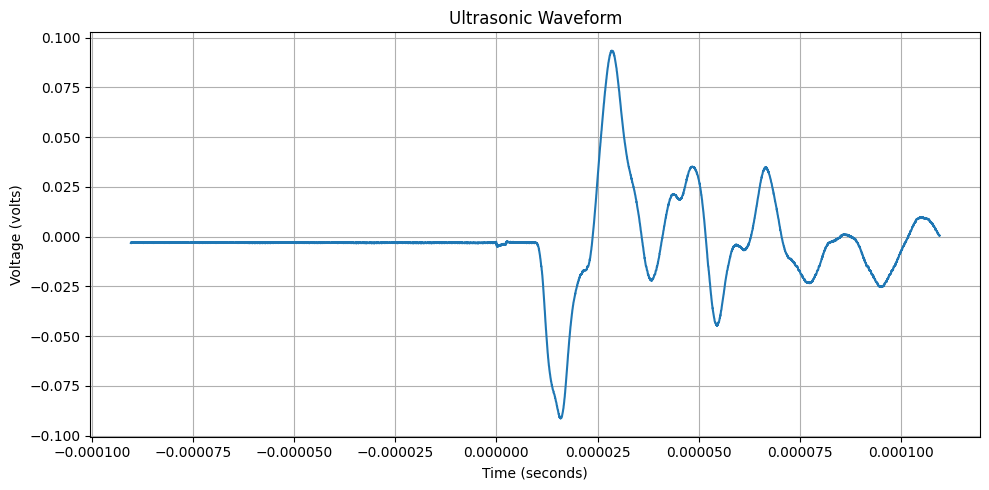

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "Sample_02_Ignsolidcore_0.3MHz_CH1_20260713_124745 copy.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3528
First arrival time (seconds): -1.984e-05
First arrival time (microseconds): -19.84
Voltage at first arrival: -0.0034296875


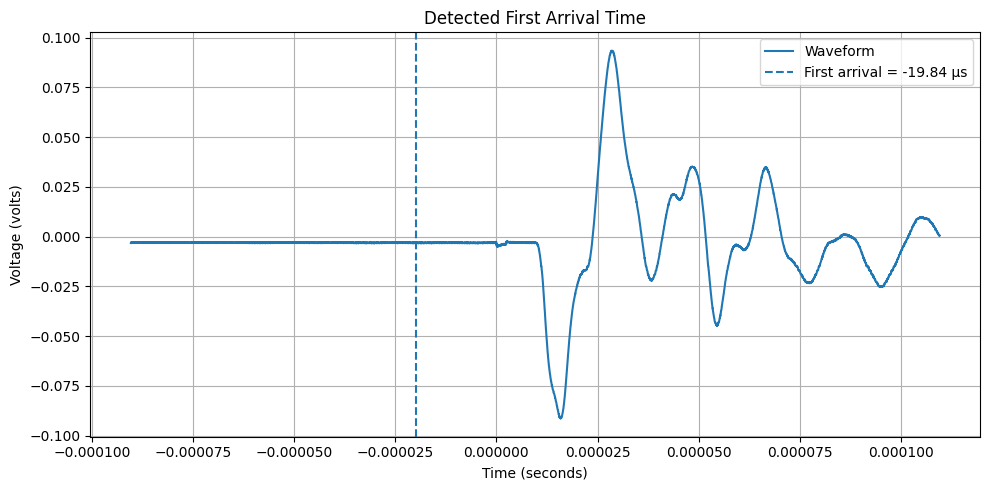

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Sample_02_Ignsolidcore_0.3MHz_CH1_20260713_124745 copy.csv"  # Change this to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Choose noise window
# The first 10% of the signal is assumed to be background noise
# ============================================================

noise_fraction = 0.10
noise_end_index = int(len(voltage) * noise_fraction)

noise = voltage[:noise_end_index]

noise_mean = np.mean(noise)
noise_std = np.std(noise)

# ============================================================
# Set threshold
# 5 times the noise standard deviation is a common starting point
# ============================================================

threshold_multiplier = 5
threshold = noise_mean + threshold_multiplier * noise_std

# Use absolute amplitude relative to baseline
signal_strength = np.abs(voltage - noise_mean)

threshold_abs = threshold_multiplier * noise_std

# ============================================================
# Detect first arrival
# ============================================================

arrival_index = None

for i in range(noise_end_index, len(signal_strength)):
    if signal_strength[i] > threshold_abs:
        arrival_index = i
        break

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    # ========================================================
    # Plot waveform and mark first arrival
    # ========================================================

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

First arrival index: 5021
First arrival time (seconds): 1.0020000000000002e-05
First arrival time (microseconds): 10.020000000000003
Voltage at first arrival: -0.0035703125


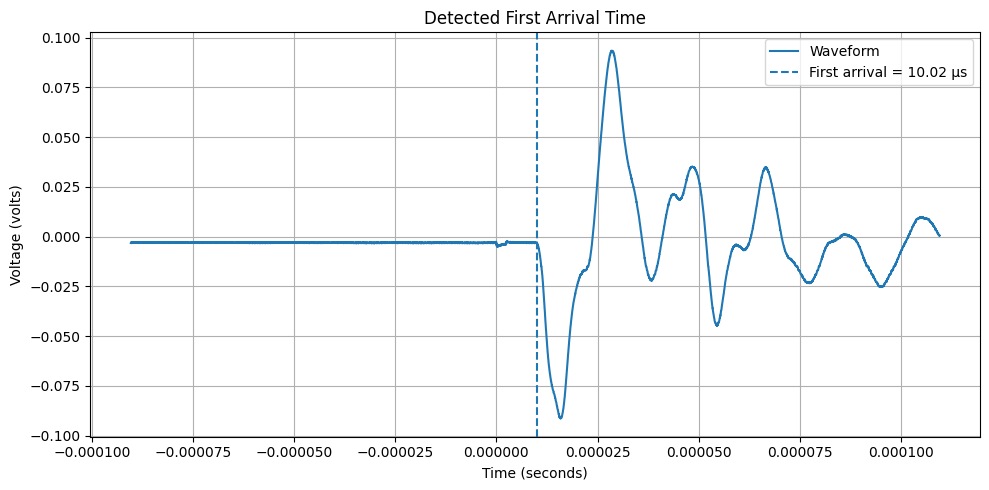

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Sample_02_Ignsolidcore_0.3MHz_CH1_20260713_124745 copy.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_165256.csv to Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_165256.csv


   Sample_ID        Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  Sample_03  ElkhillstevenSS                       1.0     CH1      0   
1  Sample_03  ElkhillstevenSS                       1.0     CH1      1   
2  Sample_03  ElkhillstevenSS                       1.0     CH1      2   
3  Sample_03  ElkhillstevenSS                       1.0     CH1      3   
4  Sample_03  ElkhillstevenSS                       1.0     CH1      4   

   Time_seconds  Voltage_volts  
0     -0.000073      -0.000841  
1     -0.000073      -0.000817  
2     -0.000073      -0.000823  
3     -0.000073      -0.000825  
4     -0.000073      -0.000827  


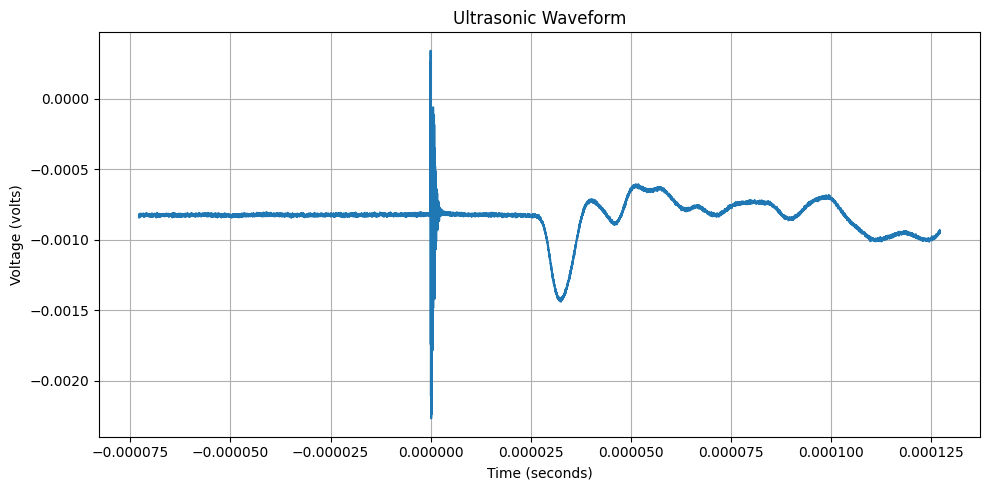

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_165256.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 5060
First arrival time (seconds): 2.8400000000000013e-05
First arrival time (microseconds): 28.400000000000013
Voltage at first arrival: -0.00092875


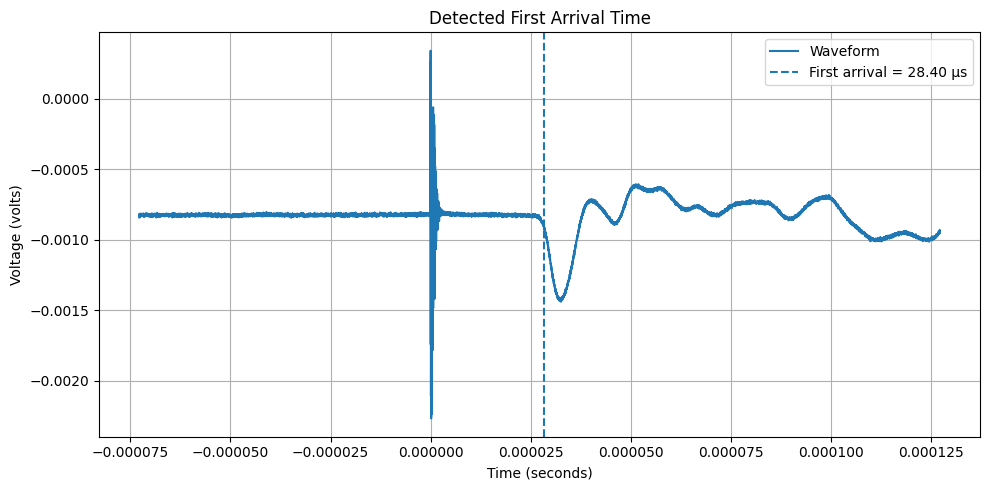

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_165256.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# NEW PROJECT #

# TESTING 4 SAMPLES UNDER 3 DIFFERENT TRANSDUCER FREQUENCIES #

# ELKHILLS STEVEN SANDSTONE
# PV SHALE CORE SAMPLE 1
# PV SHALE CORE SAMPLE 2
# SANDSTONE SOLID CORE SAMPLE

#

In [ ]:
# UNDER TRANSDUCER FREQUENCY 1.0MHz #

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving PV1_Shale_1.0MHz_CH1_20260723_164541.csv to PV1_Shale_1.0MHz_CH1_20260723_164541.csv
Saving PV2_Shale_1.0MHz_CH1_20260723_165515.csv to PV2_Shale_1.0MHz_CH1_20260723_165515.csv
Saving Sandstone_Solidcore_1.0MHz_CH1_20260723_163410.csv to Sandstone_Solidcore_1.0MHz_CH1_20260723_163410.csv


  Sample_ID Core_Type  Transducer_Frequency_MHz Channel  Point  Time_seconds  \
0       PV1     Shale                       1.0     CH1      0     -0.000081   
1       PV1     Shale                       1.0     CH1      1     -0.000081   
2       PV1     Shale                       1.0     CH1      2     -0.000081   
3       PV1     Shale                       1.0     CH1      3     -0.000081   
4       PV1     Shale                       1.0     CH1      4     -0.000081   

   Voltage_volts  
0      -0.000977  
1      -0.000982  
2      -0.000986  
3      -0.000983  
4      -0.000989  


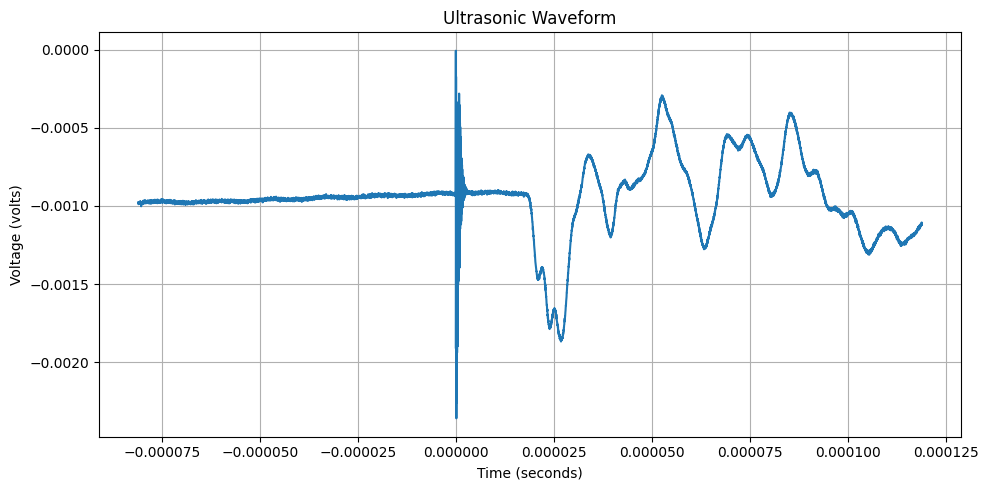

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "PV1_Shale_1.0MHz_CH1_20260723_164541.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 5022
First arrival time (seconds): 1.940000000000001e-05
First arrival time (microseconds): 19.40000000000001
Voltage at first arrival: -0.001065


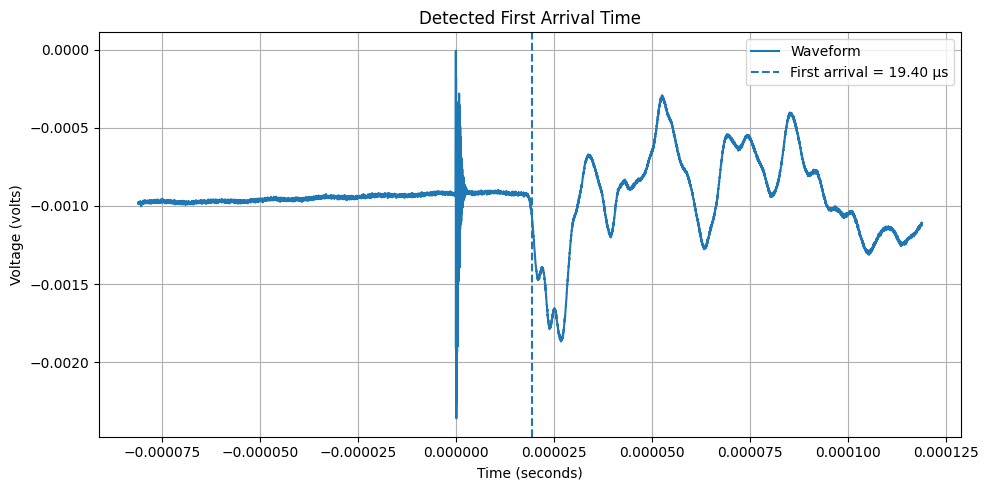

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "PV1_Shale_1.0MHz_CH1_20260723_164541.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  Sample_ID Core_Type  Transducer_Frequency_MHz Channel  Point  Time_seconds  \
0       PV2     Shale                       1.0     CH1      0     -0.000086   
1       PV2     Shale                       1.0     CH1      1     -0.000086   
2       PV2     Shale                       1.0     CH1      2     -0.000086   
3       PV2     Shale                       1.0     CH1      3     -0.000086   
4       PV2     Shale                       1.0     CH1      4     -0.000086   

   Voltage_volts  
0      -0.000870  
1      -0.000873  
2      -0.000874  
3      -0.000868  
4      -0.000869  


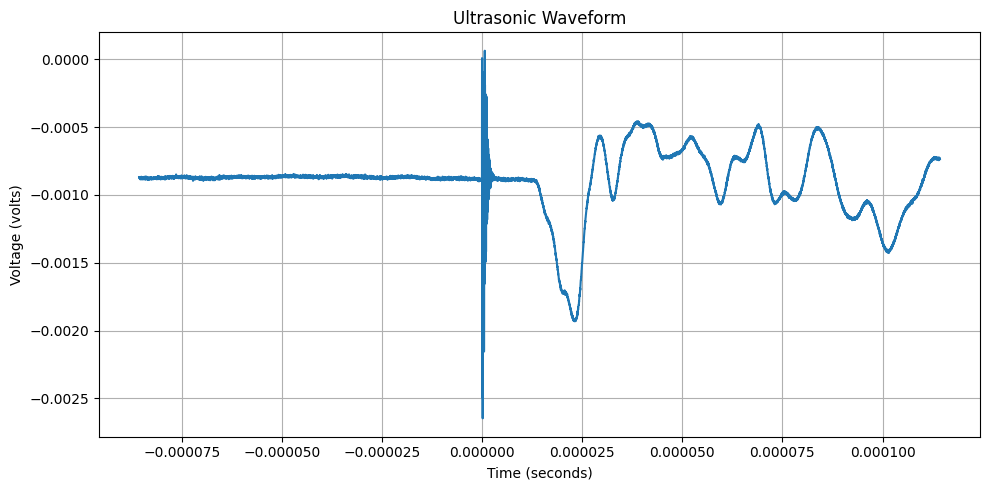

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "PV2_Shale_1.0MHz_CH1_20260723_165515.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 4993
First arrival time (seconds): 1.4219999999999996e-05
First arrival time (microseconds): 14.219999999999995
Voltage at first arrival: -0.0009540625


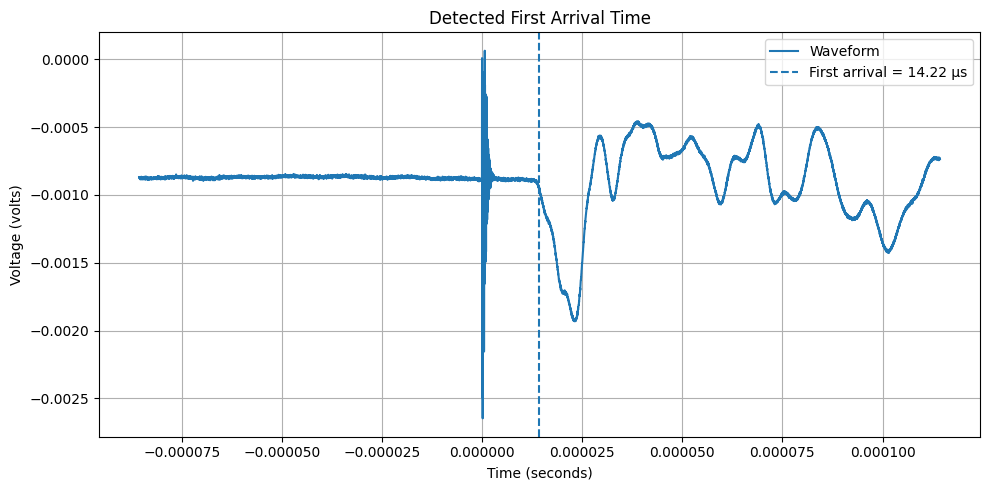

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "PV2_Shale_1.0MHz_CH1_20260723_165515.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

   Sample_ID  Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  Sandstone  Solidcore                       1.0     CH1      0   
1  Sandstone  Solidcore                       1.0     CH1      1   
2  Sandstone  Solidcore                       1.0     CH1      2   
3  Sandstone  Solidcore                       1.0     CH1      3   
4  Sandstone  Solidcore                       1.0     CH1      4   

   Time_seconds  Voltage_volts  
0     -0.000004      -0.000836  
1     -0.000004      -0.000845  
2     -0.000004      -0.000835  
3     -0.000004      -0.000848  
4     -0.000004      -0.000835  


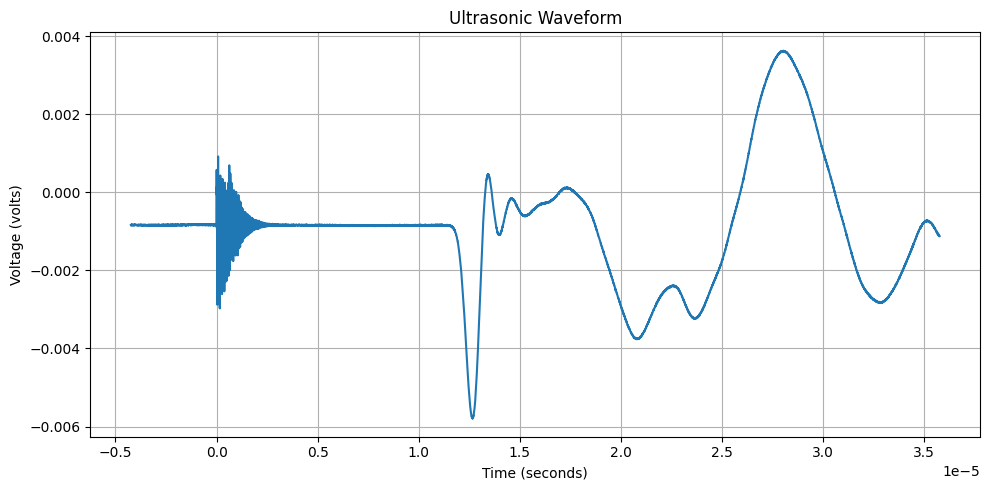

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "Sandstone_Solidcore_1.0MHz_CH1_20260723_163410.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3998
First arrival time (seconds): 1.1752000000000002e-05
First arrival time (microseconds): 11.752000000000002
Voltage at first arrival: -0.0009521875


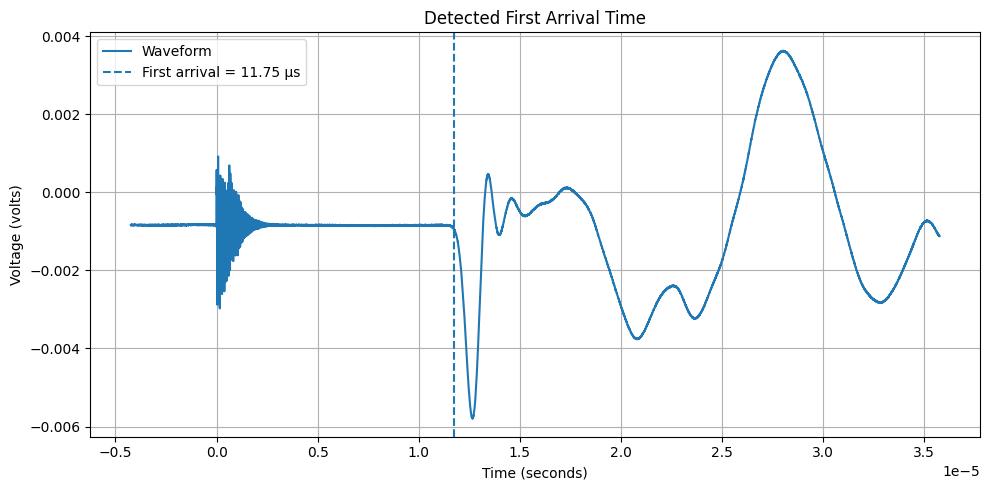

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Sandstone_Solidcore_1.0MHz_CH1_20260723_163410.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# UNDER TRANSDUCER FREQUENCY 10.0MHz #

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv to Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv
Saving PV1_Shale_10.0MHz_CH1_20260723_173650.csv to PV1_Shale_10.0MHz_CH1_20260723_173650.csv
Saving PV2_Shale_10.0MHz_CH1_20260723_174004.csv to PV2_Shale_10.0MHz_CH1_20260723_174004.csv
Saving Sandstone_Solidcore_10.0MHz_CH1_20260723_173207.csv to Sandstone_Solidcore_10.0MHz_CH1_20260723_173207.csv


  Sample_ID         Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  Elkhills  StevensSandstone                      10.0     CH1      0   
1  Elkhills  StevensSandstone                      10.0     CH1      1   
2  Elkhills  StevensSandstone                      10.0     CH1      2   
3  Elkhills  StevensSandstone                      10.0     CH1      3   
4  Elkhills  StevensSandstone                      10.0     CH1      4   

   Time_seconds  Voltage_volts  
0     -0.000145      -0.000572  
1     -0.000145      -0.000569  
2     -0.000145      -0.000558  
3     -0.000145      -0.000572  
4     -0.000145      -0.000570  


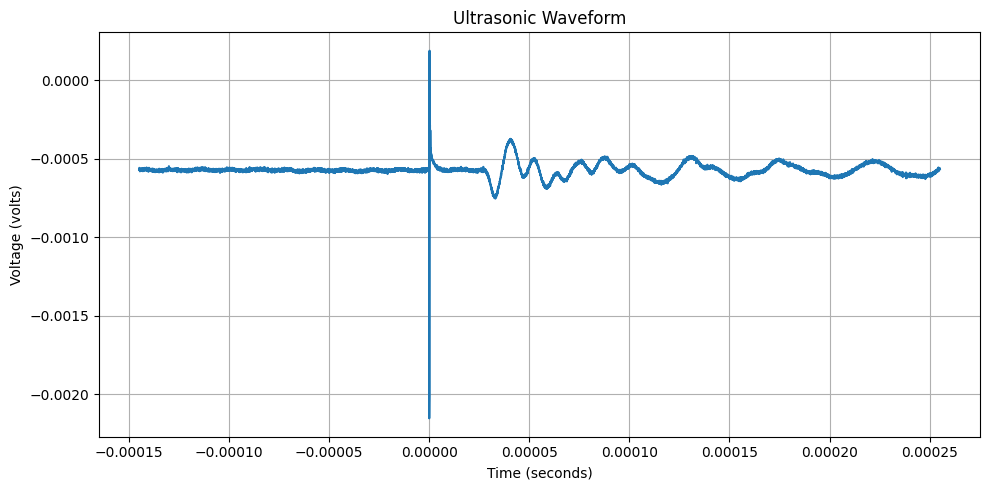

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 4350
First arrival time (seconds): 2.916e-05
First arrival time (microseconds): 29.16
Voltage at first arrival: -0.0006071875


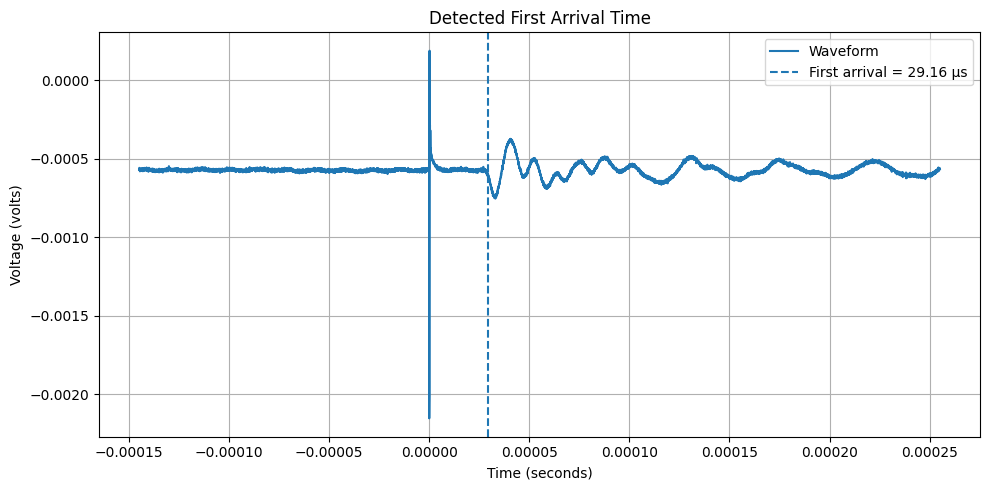

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  Sample_ID Core_Type  Transducer_Frequency_MHz Channel  Point  Time_seconds  \
0       PV1     Shale                      10.0     CH1      0     -0.000062   
1       PV1     Shale                      10.0     CH1      1     -0.000062   
2       PV1     Shale                      10.0     CH1      2     -0.000062   
3       PV1     Shale                      10.0     CH1      3     -0.000062   
4       PV1     Shale                      10.0     CH1      4     -0.000062   

   Voltage_volts  
0      -0.000515  
1      -0.000515  
2      -0.000514  
3      -0.000509  
4      -0.000504  


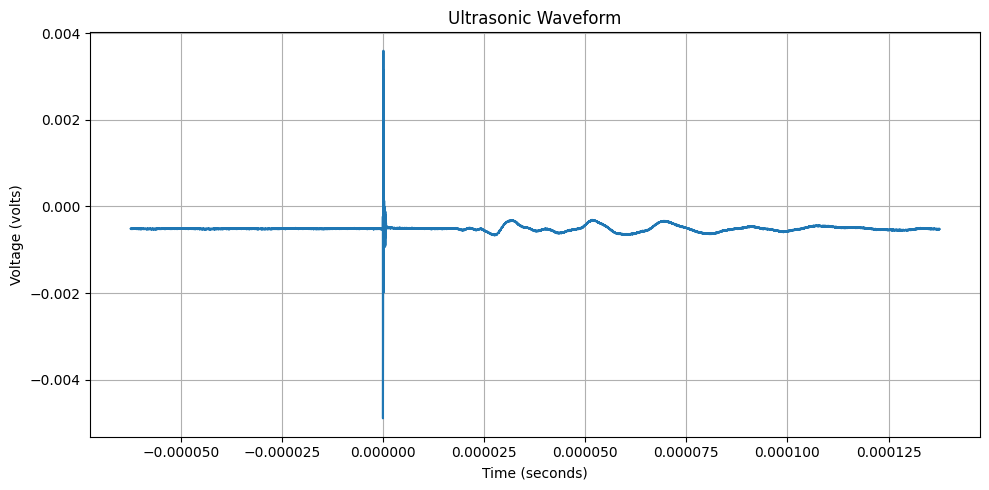

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "PV1_Shale_10.0MHz_CH1_20260723_173650.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 4109
First arrival time (seconds): 1.982e-05
First arrival time (microseconds): 19.82
Voltage at first arrival: -0.0005546875


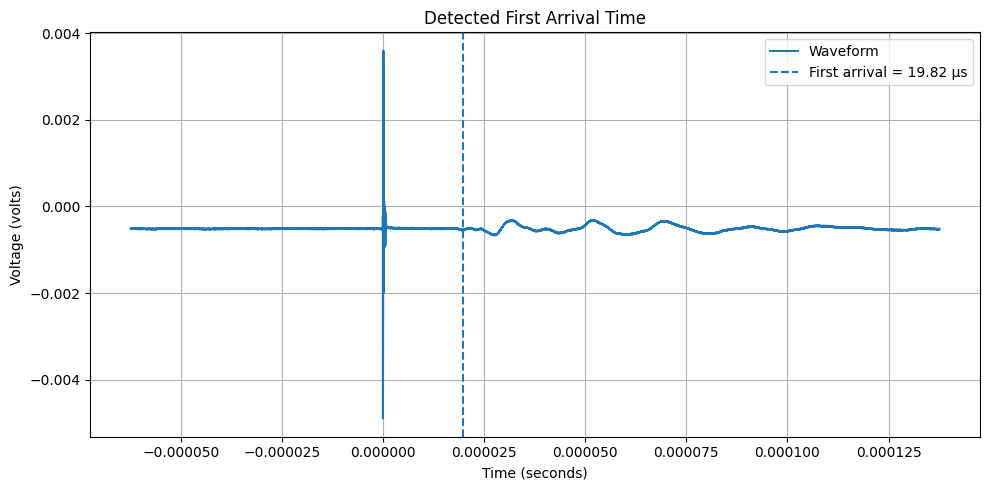

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "PV1_Shale_10.0MHz_CH1_20260723_173650.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  Sample_ID Core_Type  Transducer_Frequency_MHz Channel  Point  Time_seconds  \
0       PV2     Shale                      10.0     CH1      0     -0.000062   
1       PV2     Shale                      10.0     CH1      1     -0.000062   
2       PV2     Shale                      10.0     CH1      2     -0.000062   
3       PV2     Shale                      10.0     CH1      3     -0.000062   
4       PV2     Shale                      10.0     CH1      4     -0.000062   

   Voltage_volts  
0      -0.000499  
1      -0.000495  
2      -0.000502  
3      -0.000500  
4      -0.000493  


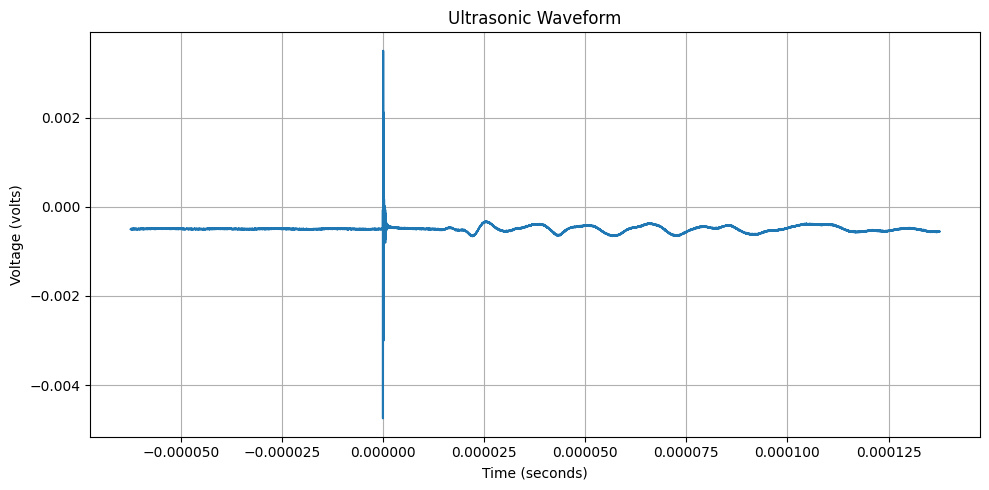

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "PV2_Shale_10.0MHz_CH1_20260723_174004.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 4143
First arrival time (seconds): 2.05e-05
First arrival time (microseconds): 20.5
Voltage at first arrival: -0.00055203125


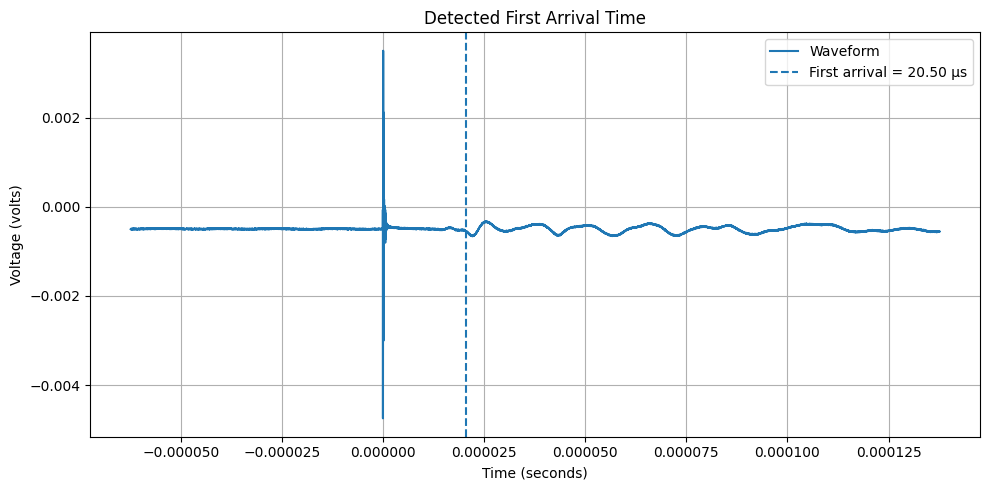

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "PV2_Shale_10.0MHz_CH1_20260723_174004.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

   Sample_ID  Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  Sandstone  Solidcore                      10.0     CH1      0   
1  Sandstone  Solidcore                      10.0     CH1      1   
2  Sandstone  Solidcore                      10.0     CH1      2   
3  Sandstone  Solidcore                      10.0     CH1      3   
4  Sandstone  Solidcore                      10.0     CH1      4   

   Time_seconds  Voltage_volts  
0     -0.000003      -0.000561  
1     -0.000003      -0.000562  
2     -0.000003      -0.000566  
3     -0.000003      -0.000565  
4     -0.000003      -0.000549  


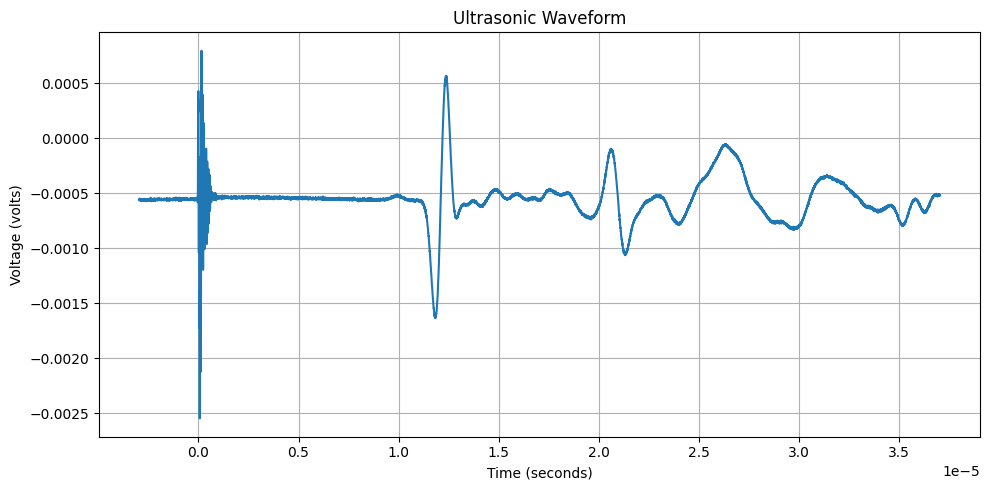

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "Sandstone_Solidcore_10.0MHz_CH1_20260723_173207.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3617
First arrival time (seconds): 1.1508e-05
First arrival time (microseconds): 11.508000000000001
Voltage at first arrival: -0.00091671875


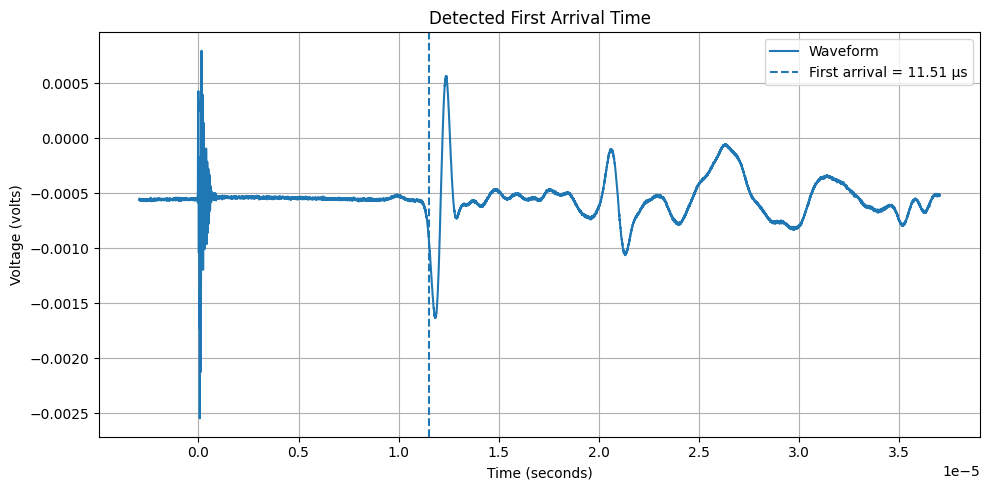

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Sandstone_Solidcore_10.0MHz_CH1_20260723_173207.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# UNDER TRANSDUCER FREQUENCY 0.3MHz #

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Elkhills_StevensSandstone_0.3MHz_CH1_20260723_170259.csv to Elkhills_StevensSandstone_0.3MHz_CH1_20260723_170259.csv
Saving NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv to NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv
Saving NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv to NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv
Saving NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv to NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv
Saving NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv to NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv
Saving PV1_Shale_0.3MHz_CH1_20260723_171135.csv to PV1_Shale_0.3MHz_CH1_20260723_171135.csv
Saving PV2_Shale_0.3MHz_CH1_20260723_171440.csv to PV2_Shale_0.3MHz_CH1_20260723_171440.csv
Saving Sandstone_Solidcore_0.3MHz_CH1_20260723_170826.csv to Sandstone_Solidcore_0.3MHz_CH1_20260723_170826.csv


     Sample_ID         Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  NewElkhills  StevensSandstone                       0.3     CH1      0   
1  NewElkhills  StevensSandstone                       0.3     CH1      1   
2  NewElkhills  StevensSandstone                       0.3     CH1      2   
3  NewElkhills  StevensSandstone                       0.3     CH1      3   
4  NewElkhills  StevensSandstone                       0.3     CH1      4   

   Time_seconds  Voltage_volts  
0     -0.000125       0.000094  
1     -0.000125       0.000102  
2     -0.000125       0.000122  
3     -0.000125       0.000147  
4     -0.000125       0.000098  


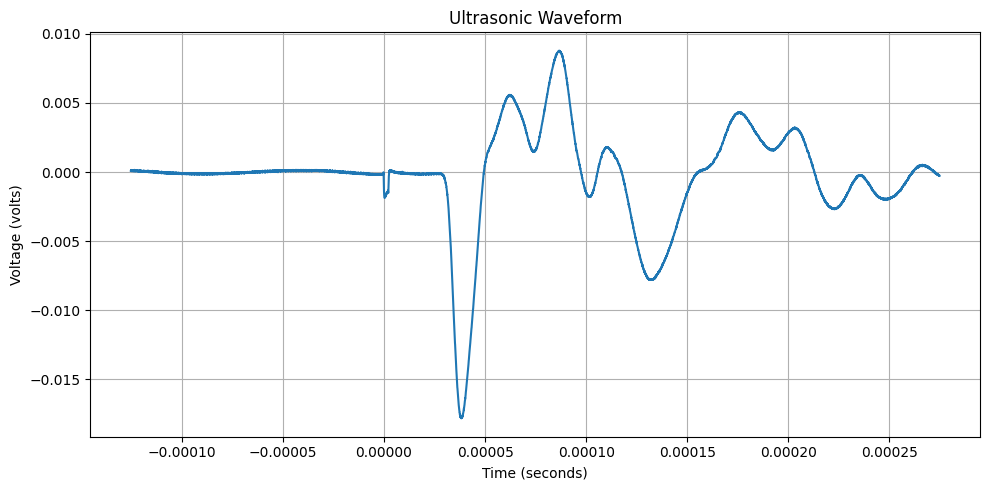

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3883
First arrival time (seconds): 3.011999999999999e-05
First arrival time (microseconds): 30.11999999999999
Voltage at first arrival: -0.0005546875


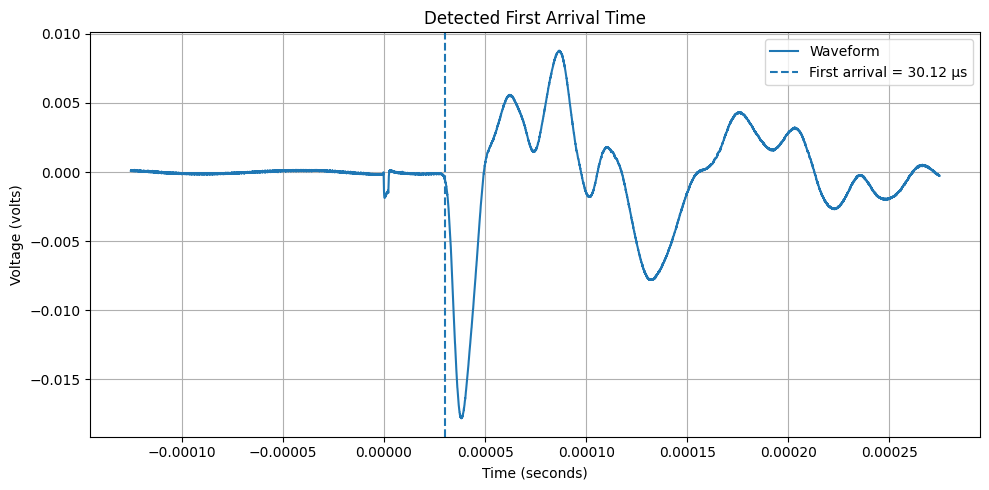

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  Sample_ID Core_Type  Transducer_Frequency_MHz Channel  Point  Time_seconds  \
0    NewPV1     Shale                       0.3     CH1      0     -0.000125   
1    NewPV1     Shale                       0.3     CH1      1     -0.000125   
2    NewPV1     Shale                       0.3     CH1      2     -0.000125   
3    NewPV1     Shale                       0.3     CH1      3     -0.000125   
4    NewPV1     Shale                       0.3     CH1      4     -0.000125   

   Voltage_volts  
0      -0.000950  
1      -0.000937  
2      -0.000920  
3      -0.000931  
4      -0.000914  


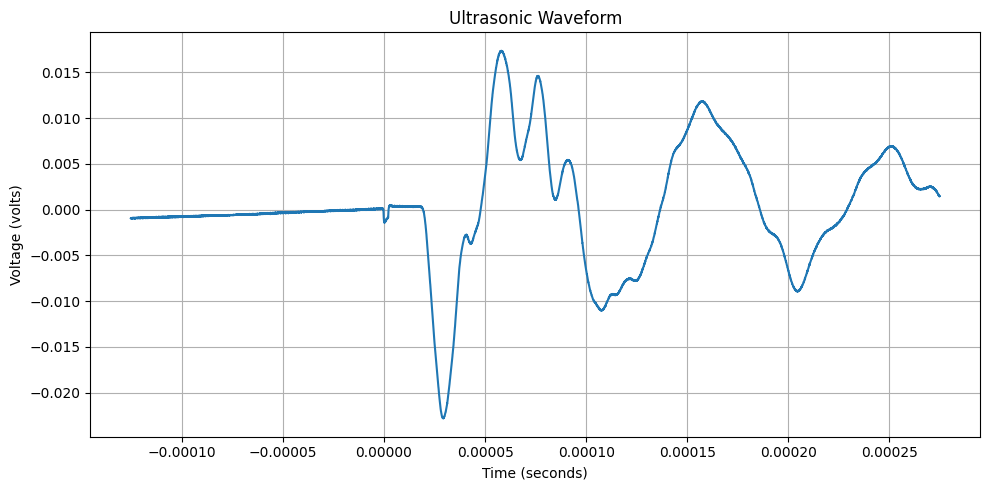

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3647
First arrival time (seconds): 2.068e-05
First arrival time (microseconds): 20.68
Voltage at first arrival: -0.002021875


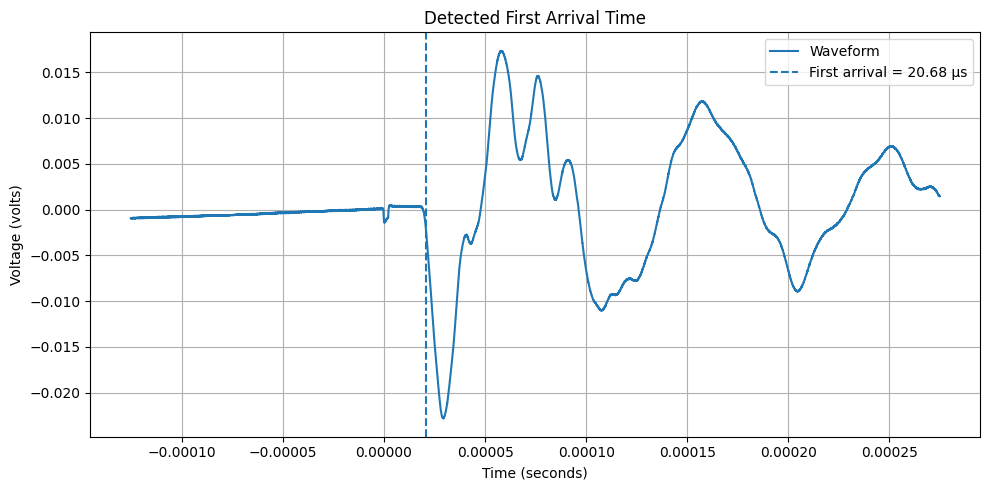

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

  Sample_ID Core_Type  Transducer_Frequency_MHz Channel  Point  Time_seconds  \
0    NewPV2     Shale                       0.3     CH1      0     -0.000139   
1    NewPV2     Shale                       0.3     CH1      1     -0.000139   
2    NewPV2     Shale                       0.3     CH1      2     -0.000139   
3    NewPV2     Shale                       0.3     CH1      3     -0.000139   
4    NewPV2     Shale                       0.3     CH1      4     -0.000139   

   Voltage_volts  
0      -0.001039  
1      -0.001053  
2      -0.001041  
3      -0.001016  
4      -0.001039  


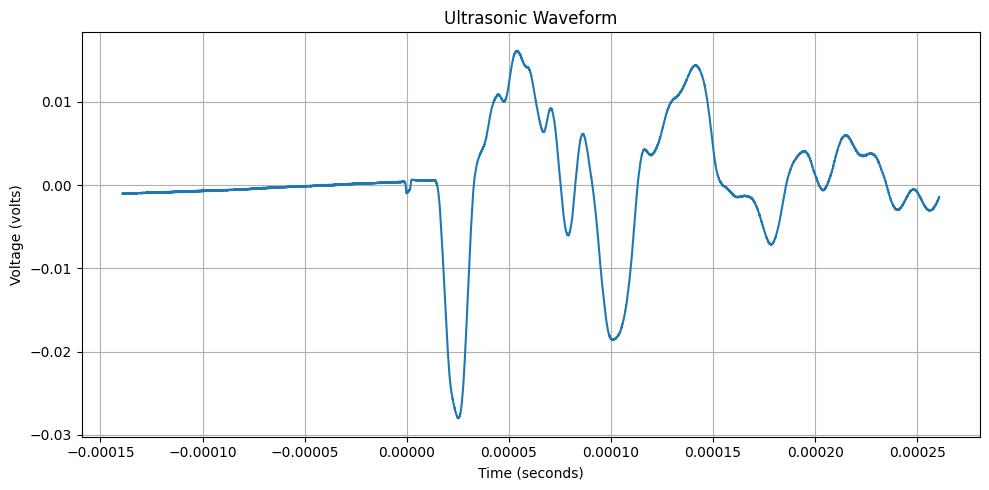

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3884
First arrival time (seconds): 1.6160000000000008e-05
First arrival time (microseconds): 16.160000000000007
Voltage at first arrival: -0.002575


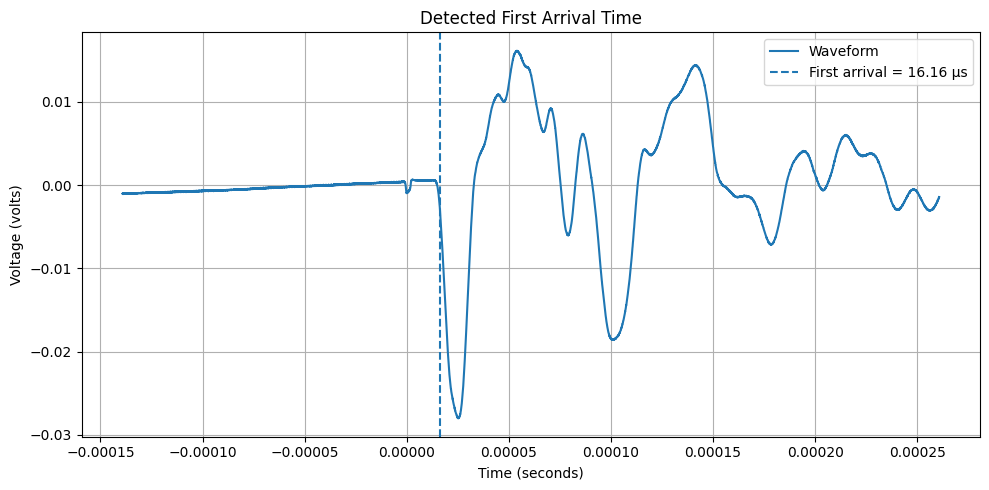

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

      Sample_ID  Core_Type  Transducer_Frequency_MHz Channel  Point  \
0  NewSandstone  Solidcore                       0.3     CH1      0   
1  NewSandstone  Solidcore                       0.3     CH1      1   
2  NewSandstone  Solidcore                       0.3     CH1      2   
3  NewSandstone  Solidcore                       0.3     CH1      3   
4  NewSandstone  Solidcore                       0.3     CH1      4   

   Time_seconds  Voltage_volts  
0     -0.000064      -0.001469  
1     -0.000064      -0.001461  
2     -0.000064      -0.001414  
3     -0.000064      -0.001367  
4     -0.000064      -0.001523  


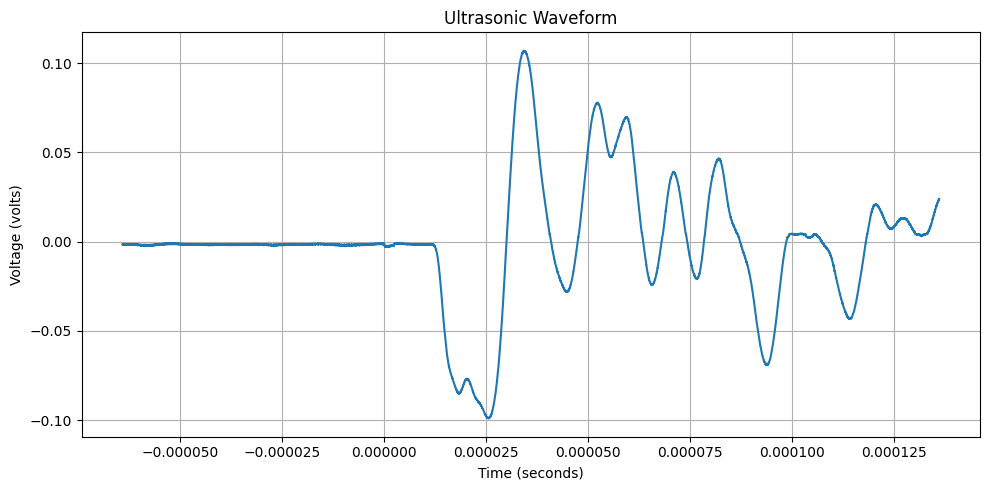

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace this with the exact name of your uploaded CSV file
csv_file = "NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv"

# Read the CSV file
df = pd.read_csv(csv_file)

# Show the first few rows to confirm the file loaded correctly
print(df.head())

# Plot waveform
plt.figure(figsize=(10, 5))
plt.plot(df["Time_seconds"], df["Voltage_volts"])

plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (volts)")
plt.title("Ultrasonic Waveform")
plt.grid(True)
plt.tight_layout()

plt.show()

First arrival index: 3825
First arrival time (seconds): 1.2500000000000006e-05
First arrival time (microseconds): 12.500000000000005
Voltage at first arrival: -0.002828125


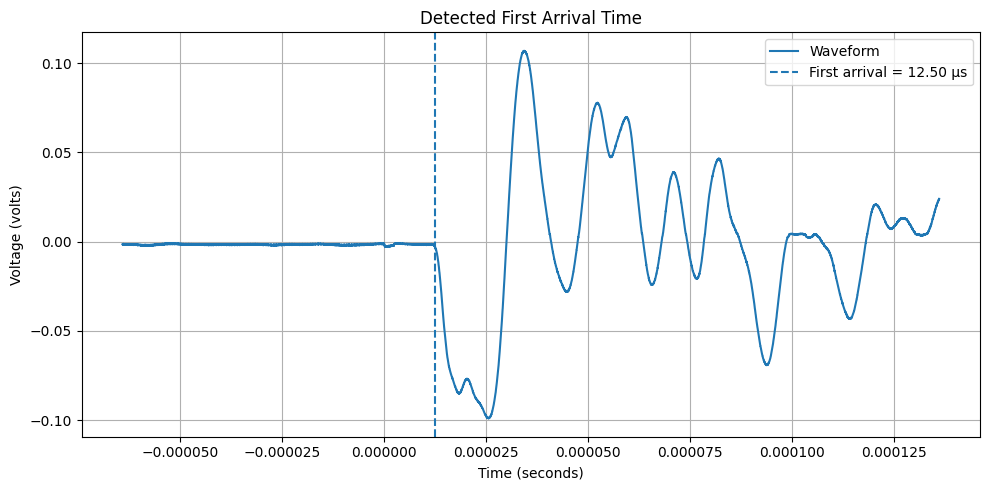

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
# WATERFALL PLOT/CHART #

# FOR ANALYSIS OF WAVEFORM DATA #

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv to Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv
Saving NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv to NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv
Saving NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv to NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv
Saving NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv to NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv
Saving NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv to NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv
Saving PV1_Shale_1.0MHz_CH1_20260723_164541.csv to PV1_Shale_1.0MHz_CH1_20260723_164541.csv
Saving PV1_Shale_10.0MHz_CH1_20260723_173650.csv to PV1_Shale_10.0MHz_CH1_20260723_173650.csv
Saving PV2_Shale_1.0MHz_CH1_20260723_165515.csv to PV2_Shale_1.0MHz_CH1_20260723_165515.csv
Saving PV2_Shale_10.0MHz_CH1_20260723_174004.csv to PV2_Shale_10.0MHz_CH1_20260723_174004.csv
Saving Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_16525

Frequencies found: [0.3, 1.0, 10.0]


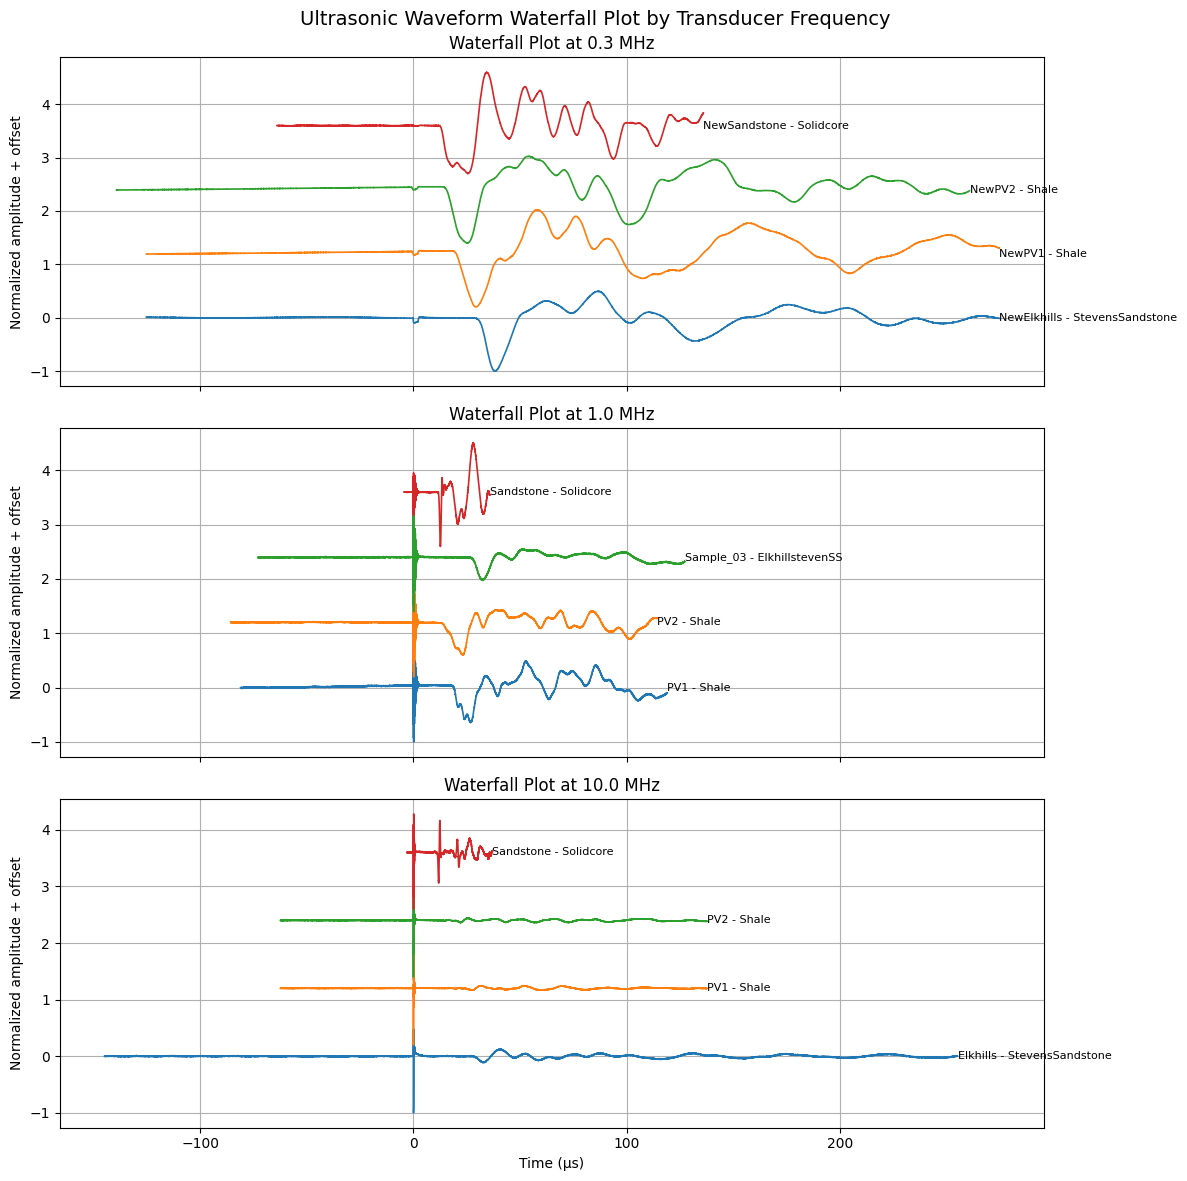

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Folder containing waveform CSV files
# ============================================================

# For Spyder:
# DATA_FOLDER = Path("/Users/user/NewUltra_Project/waveform_data")

# For Google Colab:
DATA_FOLDER = Path(".")

csv_files = sorted(DATA_FOLDER.glob("*.csv"))

if len(csv_files) == 0:
    print("No CSV files found.")
    raise SystemExit

# ============================================================
# 2. Load all waveforms
# ============================================================

waveforms = []

for file in csv_files:
    df = pd.read_csv(file)

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    # Read sample metadata if available
    if "Sample_ID" in df.columns:
        sample_id = str(df["Sample_ID"].iloc[0])
    else:
        sample_id = file.stem

    if "Core_Type" in df.columns:
        core_type = str(df["Core_Type"].iloc[0])
    else:
        core_type = "Unknown_Core"

    if "Transducer_Frequency_MHz" in df.columns:
        frequency = float(df["Transducer_Frequency_MHz"].iloc[0])
    else:
        frequency = np.nan

    waveforms.append({
        "file": file,
        "sample_id": sample_id,
        "core_type": core_type,
        "frequency": frequency,
        "time_us": time_us,
        "voltage": voltage
    })

# ============================================================
# 3. Get unique frequencies
# ============================================================

frequencies = sorted(set([w["frequency"] for w in waveforms]))

print("Frequencies found:", frequencies)

# ============================================================
# 4. Create waterfall plots by frequency
# ============================================================

fig, axes = plt.subplots(
    nrows=len(frequencies),
    ncols=1,
    figsize=(12, 4 * len(frequencies)),
    sharex=True
)

if len(frequencies) == 1:
    axes = [axes]

vertical_spacing = 1.2
normalize = True

for ax, freq in zip(axes, frequencies):
    group = [w for w in waveforms if w["frequency"] == freq]

    for i, w in enumerate(group):
        time_us = w["time_us"]
        voltage = w["voltage"]

        # Remove baseline using first 10% of waveform
        baseline = np.mean(voltage[:int(0.1 * len(voltage))])
        voltage = voltage - baseline

        # Normalize for shape comparison
        if normalize:
            max_amp = np.max(np.abs(voltage))
            if max_amp != 0:
                voltage = voltage / max_amp

        offset = i * vertical_spacing

        ax.plot(time_us, voltage + offset, linewidth=1.2)

        label = f"{w['sample_id']} - {w['core_type']}"
        ax.text(
            time_us[-1],
            offset,
            label,
            fontsize=8,
            va="center"
        )

    ax.set_title(f"Waterfall Plot at {freq} MHz")
    ax.set_ylabel("Normalized amplitude + offset")
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")

plt.suptitle("Ultrasonic Waveform Waterfall Plot by Transducer Frequency", fontsize=14)
plt.tight_layout()
plt.show()

Skipping non-waveform file: first_arrival_summary.csv
Waveform CSV files found: 12
Frequencies found: [0.3, 1.0, 10.0]


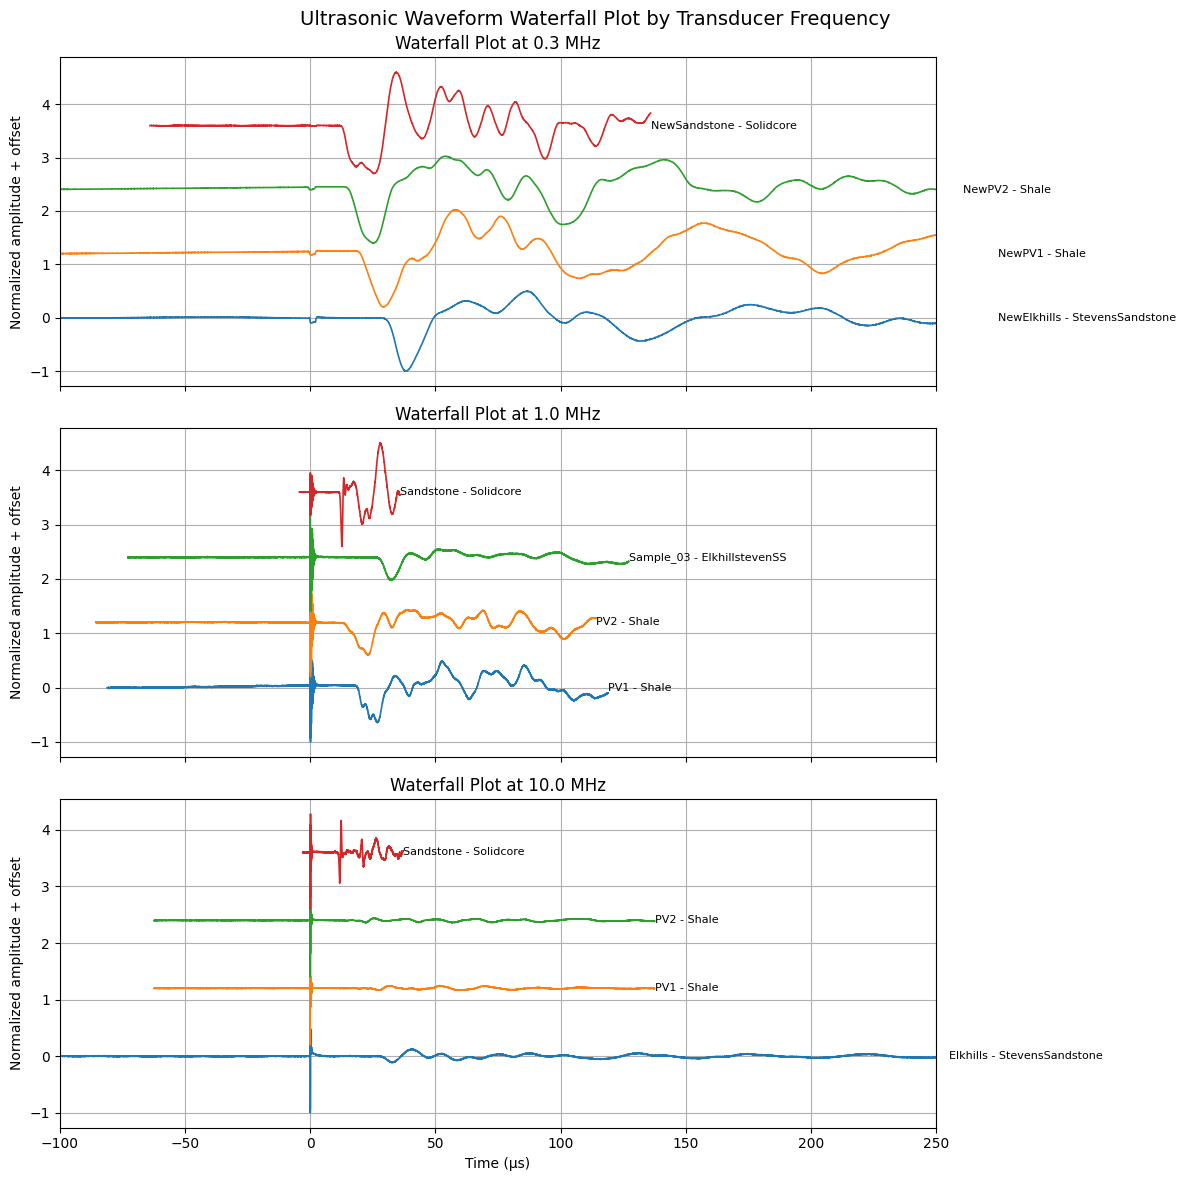

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Folder containing waveform CSV files
# ============================================================

# For Spyder:
# DATA_FOLDER = Path("/Users/user/NewUltra_Project/waveform_data")

# For Google Colab:
DATA_FOLDER = Path(".")

all_csv_files = sorted(DATA_FOLDER.glob("*.csv"))

csv_files = []

for file in all_csv_files:
    test_df = pd.read_csv(file, nrows=1)

    if "Time_seconds" in test_df.columns and "Voltage_volts" in test_df.columns:
        csv_files.append(file)
    else:
        print("Skipping non-waveform file:", file.name)

if len(csv_files) == 0:
    print("No waveform CSV files found.")
    raise SystemExit

print("Waveform CSV files found:", len(csv_files))

# ============================================================
# 2. Load all waveforms
# ============================================================

waveforms = []

for file in csv_files:
    df = pd.read_csv(file)

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    # Read sample metadata if available
    if "Sample_ID" in df.columns:
        sample_id = str(df["Sample_ID"].iloc[0])
    else:
        sample_id = file.stem

    if "Core_Type" in df.columns:
        core_type = str(df["Core_Type"].iloc[0])
    else:
        core_type = "Unknown_Core"

    if "Transducer_Frequency_MHz" in df.columns:
        frequency = float(df["Transducer_Frequency_MHz"].iloc[0])
    else:
        frequency = np.nan

    waveforms.append({
        "file": file,
        "sample_id": sample_id,
        "core_type": core_type,
        "frequency": frequency,
        "time_us": time_us,
        "voltage": voltage
    })

# ============================================================
# 3. Get unique frequencies
# ============================================================

frequencies = sorted(set([w["frequency"] for w in waveforms]))

print("Frequencies found:", frequencies)

# ============================================================
# 4. Create waterfall plots by frequency
# ============================================================

fig, axes = plt.subplots(
    nrows=len(frequencies),
    ncols=1,
    figsize=(12, 4 * len(frequencies)),
    sharex=True
)

if len(frequencies) == 1:
    axes = [axes]

vertical_spacing = 1.2
normalize = True

for ax, freq in zip(axes, frequencies):
    group = [w for w in waveforms if w["frequency"] == freq]

    for i, w in enumerate(group):
        time_us = w["time_us"]
        voltage = w["voltage"]

        # Remove baseline using first 10% of waveform
        baseline = np.mean(voltage[:int(0.1 * len(voltage))])
        voltage = voltage - baseline

        # Normalize for shape comparison
        if normalize:
            max_amp = np.max(np.abs(voltage))
            if max_amp != 0:
                voltage = voltage / max_amp

        offset = i * vertical_spacing

        ax.plot(time_us, voltage + offset, linewidth=1.2)

        label = f"{w['sample_id']} - {w['core_type']}"
        ax.text(
            time_us[-1],
            offset,
            label,
            fontsize=8,
            va="center"
        )

    ax.set_title(f"Waterfall Plot at {freq} MHz")
    ax.set_ylabel("Normalized amplitude + offset")
    ax.set_xlim(-100, 250)
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")

plt.suptitle("Ultrasonic Waveform Waterfall Plot by Transducer Frequency", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# WITH ARRIVAL TIME COMPARISON #

Number of CSV files found: 12
Frequencies found: [0.3, 1.0, 10.0]


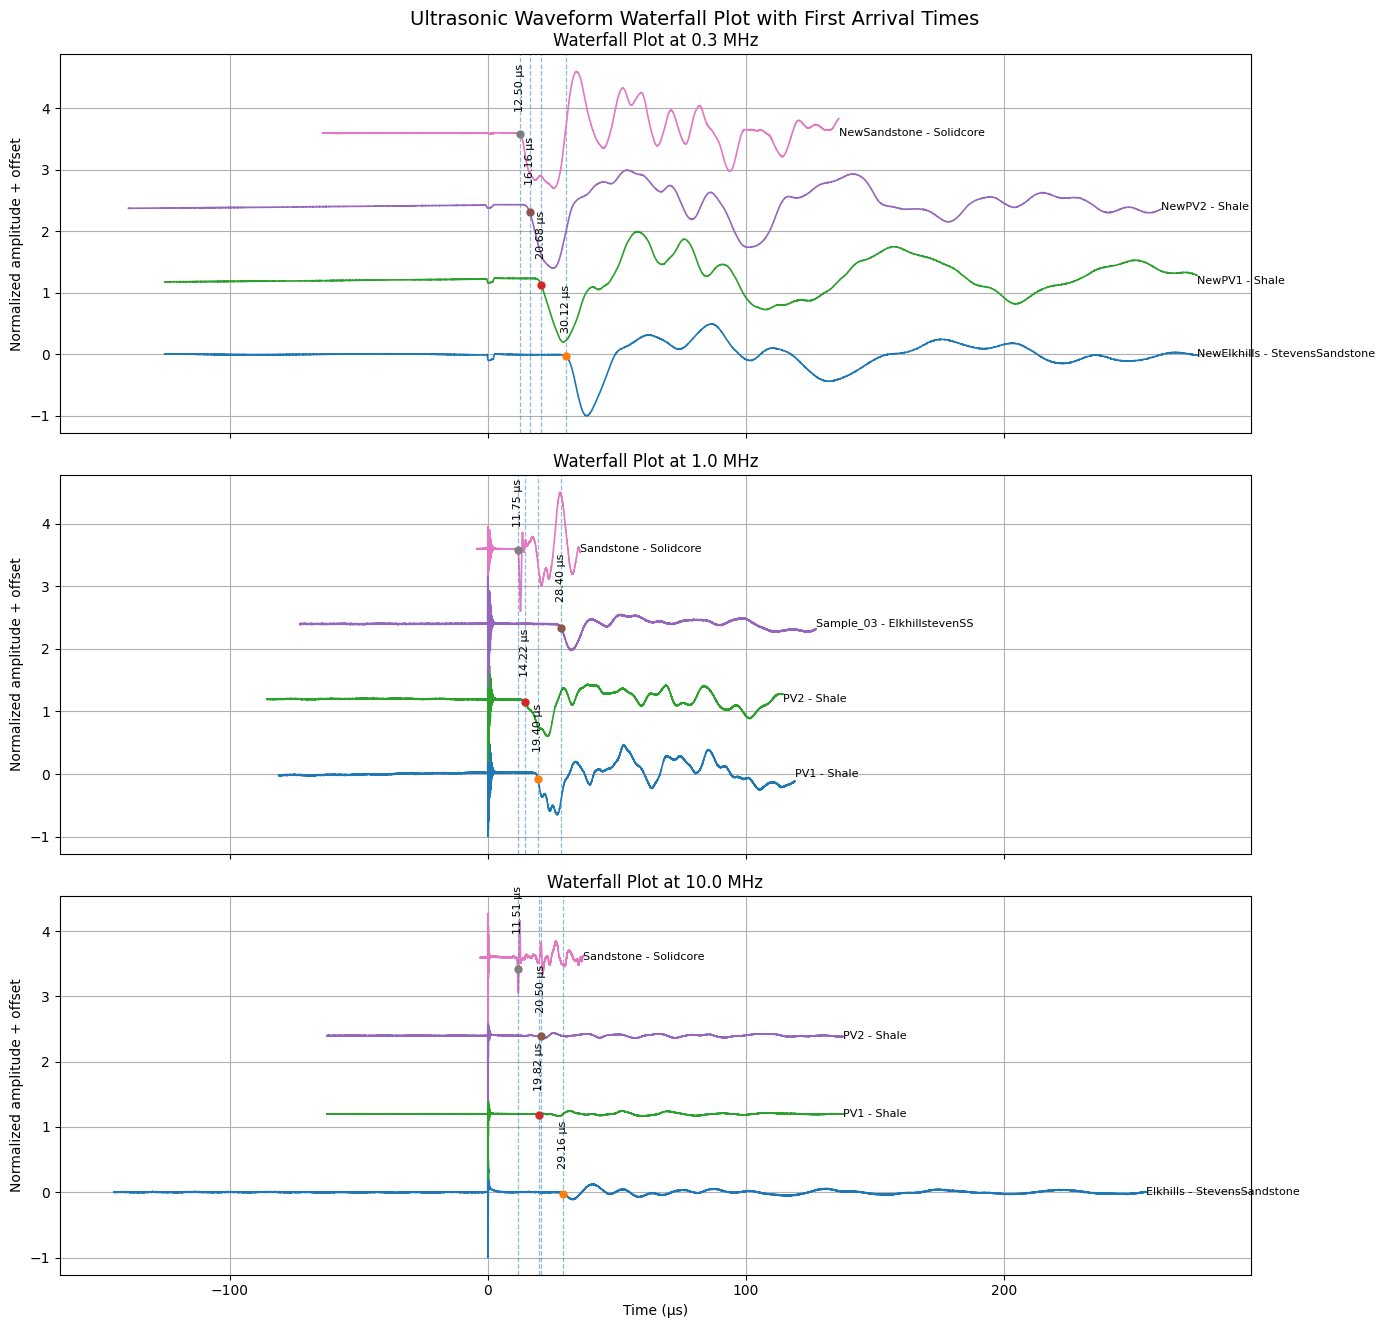


First arrival summary:
       Sample_ID         Core_Type  Frequency_MHz  First_Arrival_Time_us  \
0    NewElkhills  StevensSandstone            0.3                 30.120   
1         NewPV1             Shale            0.3                 20.680   
2         NewPV2             Shale            0.3                 16.160   
3   NewSandstone         Solidcore            0.3                 12.500   
4            PV1             Shale            1.0                 19.400   
5            PV2             Shale            1.0                 14.220   
6      Sample_03   ElkhillstevenSS            1.0                 28.400   
7      Sandstone         Solidcore            1.0                 11.752   
8       Elkhills  StevensSandstone           10.0                 29.160   
9            PV1             Shale           10.0                 19.820   
10           PV2             Shale           10.0                 20.500   
11     Sandstone         Solidcore           10.0               

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Folder containing your CSV files
# ============================================================

# For Google Colab, use this after uploading your CSV files:
DATA_FOLDER = Path(".")

# For Spyder, use your actual folder path, for example:
# DATA_FOLDER = Path("/Users/user/NewUltra_Project/waveform_data")

csv_files = sorted(DATA_FOLDER.glob("*.csv"))

if len(csv_files) == 0:
    print("No CSV files found. Check your folder path.")
    raise SystemExit

print("Number of CSV files found:", len(csv_files))


# ============================================================
# 2. Settings for arrival-time detection
# ============================================================

# These windows tell Python where to search for arrivals.
# Adjust these if your arrivals occur outside these ranges.
SEARCH_WINDOWS_US = {
    0.3: (5, 250),
    1.0: (5, 150),
    10.0: (5, 80)
}

THRESHOLD_MULTIPLIER = 5


# ============================================================
# 3. Function to detect first arrival
# ============================================================

def detect_first_arrival(time_us, voltage, frequency_mhz):
    """
    Detects first arrival using a noise threshold.
    It ignores the trigger spike near time zero by searching after a chosen start time.
    """

    search_start_us, search_end_us = SEARCH_WINDOWS_US.get(
        round(frequency_mhz, 1),
        (5, np.max(time_us))
    )

    # Use pre-trigger region as noise if available
    noise_mask = time_us < 0

    if np.sum(noise_mask) > 10:
        noise = voltage[noise_mask]
    else:
        # Fallback: use first 10% of waveform
        noise = voltage[:int(0.1 * len(voltage))]

    noise_mean = np.mean(noise)
    noise_std = np.std(noise)

    threshold = THRESHOLD_MULTIPLIER * noise_std

    signal_strength = np.abs(voltage - noise_mean)

    search_indices = np.where(
        (time_us >= search_start_us) &
        (time_us <= search_end_us)
    )[0]

    arrival_index = None

    for i in search_indices:
        if signal_strength[i] > threshold:
            arrival_index = i
            break

    if arrival_index is None:
        return None, None, None, noise_mean, threshold

    arrival_time_us = time_us[arrival_index]
    arrival_voltage = voltage[arrival_index]

    return arrival_index, arrival_time_us, arrival_voltage, noise_mean, threshold


# ============================================================
# 4. Load all waveform files
# ============================================================

waveforms = []

for file in csv_files:
    df = pd.read_csv(file)

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    # Read metadata from CSV if available
    if "Sample_ID" in df.columns:
        sample_id = str(df["Sample_ID"].iloc[0])
    else:
        sample_id = file.stem

    if "Core_Type" in df.columns:
        core_type = str(df["Core_Type"].iloc[0])
    else:
        core_type = "Unknown_Core"

    if "Transducer_Frequency_MHz" in df.columns:
        frequency = float(df["Transducer_Frequency_MHz"].iloc[0])
    else:
        # If frequency is not in the CSV, try to infer manually from filename later
        frequency = np.nan

    waveforms.append({
        "file": file,
        "sample_id": sample_id,
        "core_type": core_type,
        "frequency": frequency,
        "time_us": time_us,
        "voltage": voltage
    })


# ============================================================
# 5. Get unique frequencies
# ============================================================

frequencies = sorted(set([w["frequency"] for w in waveforms]))

print("Frequencies found:", frequencies)


# ============================================================
# 6. Waterfall plot with first-arrival markers
# ============================================================

fig, axes = plt.subplots(
    nrows=len(frequencies),
    ncols=1,
    figsize=(14, 4.5 * len(frequencies)),
    sharex=True
)

if len(frequencies) == 1:
    axes = [axes]

vertical_spacing = 1.2
normalize = True

arrival_results = []

for ax, freq in zip(axes, frequencies):
    group = [w for w in waveforms if w["frequency"] == freq]

    for i, w in enumerate(group):
        time_us = w["time_us"]
        voltage = w["voltage"]

        arrival_index, arrival_time_us, arrival_voltage, baseline, threshold = detect_first_arrival(
            time_us,
            voltage,
            freq
        )

        # Remove baseline
        voltage_corrected = voltage - baseline

        # Normalize amplitude for waterfall display
        if normalize:
            max_amp = np.max(np.abs(voltage_corrected))
            if max_amp != 0:
                voltage_plot = voltage_corrected / max_amp
            else:
                voltage_plot = voltage_corrected
        else:
            max_amp = 1
            voltage_plot = voltage_corrected

        offset = i * vertical_spacing

        # Plot waveform
        ax.plot(
            time_us,
            voltage_plot + offset,
            linewidth=1.2
        )

        # Label trace
        label = f"{w['sample_id']} - {w['core_type']}"
        ax.text(
            time_us[-1],
            offset,
            label,
            fontsize=8,
            va="center"
        )

        # Mark first arrival
        if arrival_index is not None:
            arrival_y = voltage_plot[arrival_index] + offset

            ax.axvline(
                arrival_time_us,
                linestyle="--",
                linewidth=0.9,
                alpha=0.5
            )

            ax.plot(
                arrival_time_us,
                arrival_y,
                marker="o",
                markersize=5
            )

            ax.text(
                arrival_time_us,
                offset + 0.35,
                f"{arrival_time_us:.2f} µs",
                fontsize=8,
                rotation=90,
                va="bottom",
                ha="center"
            )

            arrival_results.append({
                "Sample_ID": w["sample_id"],
                "Core_Type": w["core_type"],
                "Frequency_MHz": freq,
                "First_Arrival_Time_us": arrival_time_us,
                "First_Arrival_Index": arrival_index,
                "Voltage_at_Arrival_V": arrival_voltage
            })

        else:
            arrival_results.append({
                "Sample_ID": w["sample_id"],
                "Core_Type": w["core_type"],
                "Frequency_MHz": freq,
                "First_Arrival_Time_us": np.nan,
                "First_Arrival_Index": np.nan,
                "Voltage_at_Arrival_V": np.nan
            })

    ax.set_title(f"Waterfall Plot at {freq} MHz")
    ax.set_ylabel("Normalized amplitude + offset")
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")

plt.suptitle(
    "Ultrasonic Waveform Waterfall Plot with First Arrival Times",
    fontsize=14
)

plt.tight_layout()

plt.savefig("waterfall_with_first_arrivals.png", dpi=300)
plt.show()


# ============================================================
# 7. Create and show arrival-time summary table
# ============================================================

arrival_df = pd.DataFrame(arrival_results)

print("\nFirst arrival summary:")
print(arrival_df)

arrival_df.to_csv("first_arrival_summary.csv", index=False)

print("\nSaved summary table as:")
print("first_arrival_summary.csv")

print("\nSaved waterfall figure as:")
print("waterfall_with_first_arrivals.png")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv to Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv
Saving NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv to NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv
Saving NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv to NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv
Saving NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv to NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv
Saving NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv to NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv
Saving PV1_Shale_1.0MHz_CH1_20260723_164541.csv to PV1_Shale_1.0MHz_CH1_20260723_164541.csv
Saving PV1_Shale_10.0MHz_CH1_20260723_173650.csv to PV1_Shale_10.0MHz_CH1_20260723_173650.csv
Saving PV2_Shale_1.0MHz_CH1_20260723_165515.csv to PV2_Shale_1.0MHz_CH1_20260723_165515.csv
Saving PV2_Shale_10.0MHz_CH1_20260723_174004.csv to PV2_Shale_10.0MHz_CH1_20260723_174004.csv
Saving Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_16525

Total CSV files found: 13
Using waveform file: Elkhills_StevensSandstone_10.0MHz_CH1_20260723_172751.csv
Using waveform file: NewElkhills_StevensSandstone_0.3MHz_CH1_20260723_175722.csv
Using waveform file: NewPV1_Shale_0.3MHz_CH1_20260723_180024.csv
Using waveform file: NewPV2_Shale_0.3MHz_CH1_20260723_180255.csv
Using waveform file: NewSandstone_Solidcore_0.3MHz_CH1_20260723_175128.csv
Using waveform file: PV1_Shale_1.0MHz_CH1_20260723_164541.csv
Using waveform file: PV1_Shale_10.0MHz_CH1_20260723_173650.csv
Using waveform file: PV2_Shale_1.0MHz_CH1_20260723_165515.csv
Using waveform file: PV2_Shale_10.0MHz_CH1_20260723_174004.csv
Using waveform file: Sample_03_ElkhillstevenSS_1.0MHz_CH1_20260713_165256.csv
Using waveform file: Sandstone_Solidcore_1.0MHz_CH1_20260723_163410.csv
Using waveform file: Sandstone_Solidcore_10.0MHz_CH1_20260723_173207.csv
Skipping non-waveform file: first_arrival_summary.csv Columns: ['Sample_ID', 'Core_Type', 'Frequency_MHz', 'First_Arrival_Time_us', 'Fir

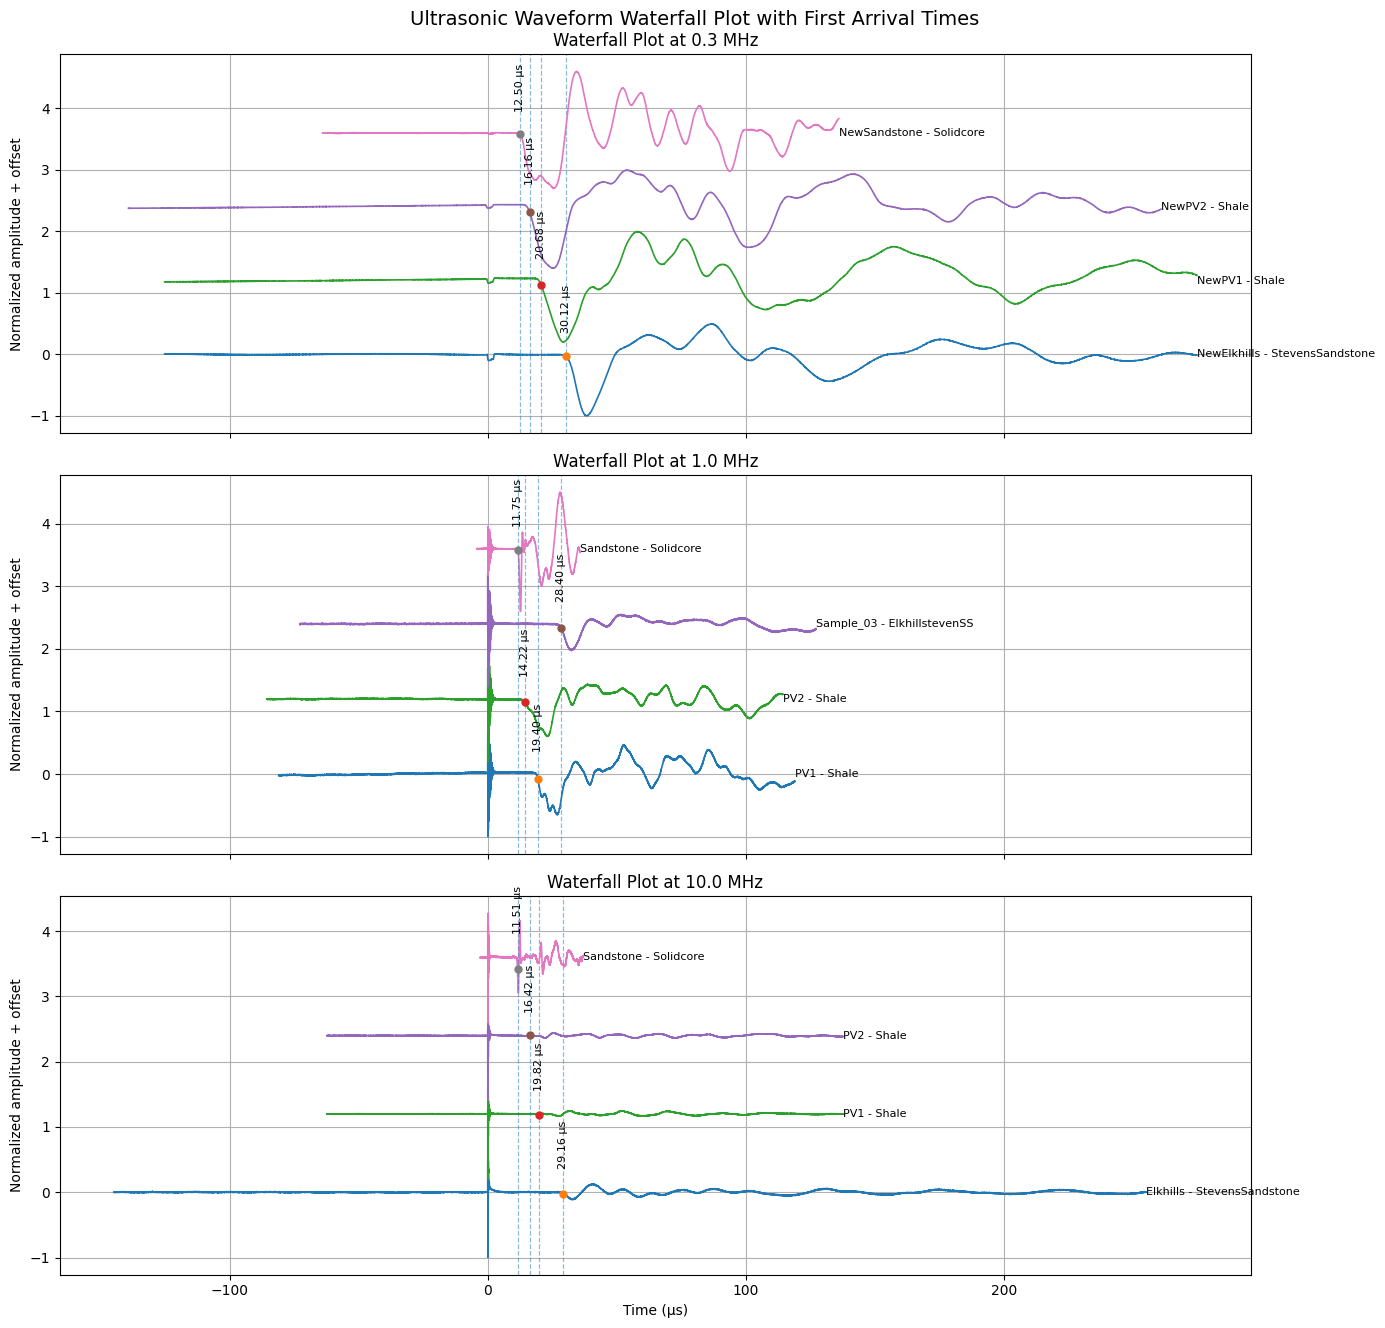


First arrival summary:
       Sample_ID         Core_Type  Frequency_MHz  First_Arrival_Time_us  \
0    NewElkhills  StevensSandstone            0.3                 30.120   
1         NewPV1             Shale            0.3                 20.680   
2         NewPV2             Shale            0.3                 16.160   
3   NewSandstone         Solidcore            0.3                 12.500   
4            PV1             Shale            1.0                 19.400   
5            PV2             Shale            1.0                 14.220   
6      Sample_03   ElkhillstevenSS            1.0                 28.400   
7      Sandstone         Solidcore            1.0                 11.752   
8       Elkhills  StevensSandstone           10.0                 29.160   
9            PV1             Shale           10.0                 19.820   
10           PV2             Shale           10.0                 16.420   
11     Sandstone         Solidcore           10.0               

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Folder containing your CSV files
# ============================================================

# For Google Colab, use this after uploading your CSV files:
DATA_FOLDER = Path(".")

# For Spyder, use your actual folder path, for example:
# DATA_FOLDER = Path("/Users/user/NewUltra_Project/waveform_data")

# ============================================================
# Find only waveform CSV files
# ============================================================

all_csv_files = sorted(list(DATA_FOLDER.glob("*.csv")) + list(DATA_FOLDER.glob("*.CSV")))

print("Total CSV files found:", len(all_csv_files))

csv_files = []

for file in all_csv_files:
    try:
        test_df = pd.read_csv(file, nrows=1)

        # Remove accidental spaces from column names
        test_df.columns = test_df.columns.str.strip()

        if "Time_seconds" in test_df.columns and "Voltage_volts" in test_df.columns:
            csv_files.append(file)
            print("Using waveform file:", file.name)
        else:
            print("Skipping non-waveform file:", file.name, "Columns:", test_df.columns.tolist())

    except Exception as e:
        print("Skipping unreadable file:", file.name, "Error:", e)

if len(csv_files) == 0:
    print("No waveform CSV files found.")
    print("Make sure you uploaded the raw oscilloscope waveform CSV files.")
    raise SystemExit

print("Waveform CSV files found:", len(csv_files))


# ============================================================
# 2. Settings for arrival-time detection
# ============================================================

# ============================================================
# 2. Settings for arrival-time detection
# ============================================================

# General search windows by frequency
SEARCH_WINDOWS_US = {
    0.3: (5, 250),
    1.0: (5, 150),
    10.0: (5, 80)
}

# Default threshold
DEFAULT_THRESHOLD_MULTIPLIER = 5

# Special threshold settings for weak or problematic traces
# Lower number = picks earlier/smaller arrivals
THRESHOLD_OVERRIDES = {
    ("PV2", 10.0): 3.5,
    ("NewPV2", 10.0): 3.5
}

SEARCH_WINDOW_OVERRIDES = {
    ("PV2", 10.0): (10, 30),
    ("NewPV2", 10.0): (10, 30)
}

# ============================================================
# 3. Function to detect first arrival
# ============================================================

def detect_first_arrival(time_us, voltage, frequency_mhz, sample_id):
    """
    Detects first arrival using a noise threshold.
    Lower threshold values make Python pick earlier arrivals.
    """

    sample_id = str(sample_id).strip()
    freq = round(float(frequency_mhz), 1)

    # Use special search window if available
    search_start_us, search_end_us = SEARCH_WINDOW_OVERRIDES.get(
        (sample_id, freq),
        SEARCH_WINDOWS_US.get(freq, (5, np.max(time_us)))
    )

    # Use special threshold if available
    threshold_multiplier = THRESHOLD_OVERRIDES.get(
        (sample_id, freq),
        DEFAULT_THRESHOLD_MULTIPLIER
    )

    # Use pre-trigger region as noise if available
    noise_mask = time_us < 0

    if np.sum(noise_mask) > 10:
        noise = voltage[noise_mask]
    else:
        noise = voltage[:int(0.1 * len(voltage))]

    noise_mean = np.mean(noise)
    noise_std = np.std(noise)

    threshold = threshold_multiplier * noise_std

    signal_strength = np.abs(voltage - noise_mean)

    search_indices = np.where(
        (time_us >= search_start_us) &
        (time_us <= search_end_us)
    )[0]

    arrival_index = None

    for i in search_indices:
        if signal_strength[i] > threshold:
            arrival_index = i
            break

    if arrival_index is None:
        return None, None, None, noise_mean, threshold

    arrival_time_us = time_us[arrival_index]
    arrival_voltage = voltage[arrival_index]

    return arrival_index, arrival_time_us, arrival_voltage, noise_mean, threshold


# ============================================================
# 4. Load all waveform files
# ============================================================


waveforms = []

for file in csv_files:
    df = pd.read_csv(file)

    # Remove accidental spaces from column names
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    # Read metadata from CSV if available
    if "Sample_ID" in df.columns:
        sample_id = str(df["Sample_ID"].iloc[0])
    else:
        sample_id = file.stem

    if "Core_Type" in df.columns:
        core_type = str(df["Core_Type"].iloc[0])
    else:
        core_type = "Unknown_Core"

    if "Transducer_Frequency_MHz" in df.columns:
        frequency = float(df["Transducer_Frequency_MHz"].iloc[0])
    else:
        # If frequency is not in the CSV, try to infer manually from filename later
        frequency = np.nan

    waveforms.append({
        "file": file,
        "sample_id": sample_id,
        "core_type": core_type,
        "frequency": frequency,
        "time_us": time_us,
        "voltage": voltage
    })


# ============================================================
# 5. Get unique frequencies
# ============================================================

frequencies = sorted(set([w["frequency"] for w in waveforms]))

print("Frequencies found:", frequencies)


# ============================================================
# 6. Waterfall plot with first-arrival markers
# ============================================================

fig, axes = plt.subplots(
    nrows=len(frequencies),
    ncols=1,
    figsize=(14, 4.5 * len(frequencies)),
    sharex=True
)

if len(frequencies) == 1:
    axes = [axes]

vertical_spacing = 1.2
normalize = True

arrival_results = []

for ax, freq in zip(axes, frequencies):
    group = [w for w in waveforms if w["frequency"] == freq]

    for i, w in enumerate(group):
        time_us = w["time_us"]
        voltage = w["voltage"]

        arrival_index, arrival_time_us, arrival_voltage, baseline, threshold = detect_first_arrival(
    time_us,
    voltage,
    freq,
    w["sample_id"]
)

        # Remove baseline
        voltage_corrected = voltage - baseline

        # Normalize amplitude for waterfall display
        if normalize:
            max_amp = np.max(np.abs(voltage_corrected))
            if max_amp != 0:
                voltage_plot = voltage_corrected / max_amp
            else:
                voltage_plot = voltage_corrected
        else:
            max_amp = 1
            voltage_plot = voltage_corrected

        offset = i * vertical_spacing

        # Plot waveform
        ax.plot(
            time_us,
            voltage_plot + offset,
            linewidth=1.2
        )

        # Label trace
        label = f"{w['sample_id']} - {w['core_type']}"
        ax.text(
            time_us[-1],
            offset,
            label,
            fontsize=8,
            va="center"
        )

        # Mark first arrival
        if arrival_index is not None:
            arrival_y = voltage_plot[arrival_index] + offset

            ax.axvline(
                arrival_time_us,
                linestyle="--",
                linewidth=0.9,
                alpha=0.5
            )

            ax.plot(
                arrival_time_us,
                arrival_y,
                marker="o",
                markersize=5
            )

            ax.text(
                arrival_time_us,
                offset + 0.35,
                f"{arrival_time_us:.2f} µs",
                fontsize=8,
                rotation=90,
                va="bottom",
                ha="center"
            )

            arrival_results.append({
                "Sample_ID": w["sample_id"],
                "Core_Type": w["core_type"],
                "Frequency_MHz": freq,
                "First_Arrival_Time_us": arrival_time_us,
                "First_Arrival_Index": arrival_index,
                "Voltage_at_Arrival_V": arrival_voltage
            })

        else:
            arrival_results.append({
                "Sample_ID": w["sample_id"],
                "Core_Type": w["core_type"],
                "Frequency_MHz": freq,
                "First_Arrival_Time_us": np.nan,
                "First_Arrival_Index": np.nan,
                "Voltage_at_Arrival_V": np.nan
            })

    ax.set_title(f"Waterfall Plot at {freq} MHz")
    ax.set_ylabel("Normalized amplitude + offset")
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")

plt.suptitle(
    "Ultrasonic Waveform Waterfall Plot with First Arrival Times",
    fontsize=14
)

plt.tight_layout()

plt.savefig("waterfall_with_first_arrivals.png", dpi=300)
plt.show()


# ============================================================
# 7. Create and show arrival-time summary table
# ============================================================

arrival_df = pd.DataFrame(arrival_results)

print("\nFirst arrival summary:")
print(arrival_df)

arrival_df.to_csv("first_arrival_summary.csv", index=False)

print("\nSaved summary table as:")
print("first_arrival_summary.csv")

print("\nSaved waterfall figure as:")
print("waterfall_with_first_arrivals.png")

In [ ]:
# ARRIVAL TIME COMPARISON BAR CHART #

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving first_arrival_summary.csv to first_arrival_summary (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("first_arrival_summary.csv")

print(df.head())

      Sample_ID         Core_Type  Frequency_MHz  First_Arrival_Time_us  \
0   NewElkhills  StevensSandstone            0.3                  30.12   
1        NewPV1             Shale            0.3                  20.68   
2        NewPV2             Shale            0.3                  16.16   
3  NewSandstone         Solidcore            0.3                  12.50   
4           PV1             Shale            1.0                  19.40   

   First_Arrival_Index  Voltage_at_Arrival_V  
0                 3883             -0.000555  
1                 3647             -0.002022  
2                 3884             -0.002575  
3                 3825             -0.002828  
4                 5022             -0.001065  


In [ ]:
# Load CSV and group into 4 physical samples #

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Load first arrival summary
# ============================================================

df = pd.read_csv("first_arrival_summary.csv")

# Clean column names and sample names
df.columns = df.columns.str.strip()
df["Sample_ID"] = df["Sample_ID"].astype(str).str.strip()

# ============================================================
# Map different CSV/sample names to the 4 physical samples
# ============================================================

sample_name_map = {
    "NewElkhills": "Stevens Sandstone",
    "Sample_03": "Stevens Sandstone",
    "Elkhills": "Stevens Sandstone",

    "NewPV1": "PV1 Shale",
    "PV1": "PV1 Shale",

    "NewPV2": "PV2 Shale",
    "PV2": "PV2 Shale",

    "NewSandstone": "Sandstone Solidcore",
    "Sandstone": "Sandstone Solidcore"
}

df["Physical_Sample"] = df["Sample_ID"].map(sample_name_map)

# Check for unmapped sample names
unmapped = df[df["Physical_Sample"].isna()]

if len(unmapped) > 0:
    print("These sample names were not mapped:")
    print(unmapped["Sample_ID"].unique())
else:
    print("All sample names mapped successfully.")

print(df[[
    "Sample_ID",
    "Physical_Sample",
    "Core_Type",
    "Frequency_MHz",
    "First_Arrival_Time_us"
]])

All sample names mapped successfully.
       Sample_ID      Physical_Sample         Core_Type  Frequency_MHz  \
0    NewElkhills    Stevens Sandstone  StevensSandstone            0.3   
1         NewPV1            PV1 Shale             Shale            0.3   
2         NewPV2            PV2 Shale             Shale            0.3   
3   NewSandstone  Sandstone Solidcore         Solidcore            0.3   
4            PV1            PV1 Shale             Shale            1.0   
5            PV2            PV2 Shale             Shale            1.0   
6      Sample_03    Stevens Sandstone   ElkhillstevenSS            1.0   
7      Sandstone  Sandstone Solidcore         Solidcore            1.0   
8       Elkhills    Stevens Sandstone  StevensSandstone           10.0   
9            PV1            PV1 Shale             Shale           10.0   
10           PV2            PV2 Shale             Shale           10.0   
11     Sandstone  Sandstone Solidcore         Solidcore           10.0   


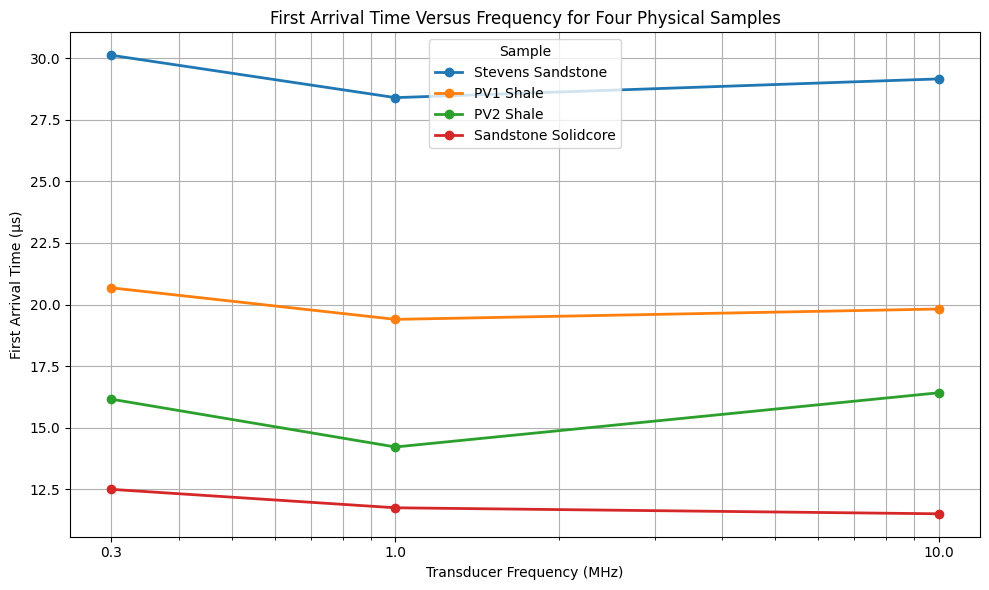

In [ ]:
# ============================================================
# Line plot: first arrival time versus frequency
# ============================================================

plt.figure(figsize=(10, 6))

sample_order = [
    "Stevens Sandstone",
    "PV1 Shale",
    "PV2 Shale",
    "Sandstone Solidcore"
]

for sample in sample_order:
    subset = df[df["Physical_Sample"] == sample].sort_values("Frequency_MHz")

    plt.plot(
        subset["Frequency_MHz"],
        subset["First_Arrival_Time_us"],
        marker="o",
        linewidth=2,
        label=sample
    )

plt.xlabel("Transducer Frequency (MHz)")
plt.ylabel("First Arrival Time (µs)")
plt.title("First Arrival Time Versus Frequency for Four Physical Samples")

# Because your frequencies are 0.3, 1.0, and 10.0 MHz, log scale is better visually
plt.xscale("log")
plt.xticks([0.3, 1.0, 10.0], ["0.3", "1.0", "10.0"])

plt.grid(True, which="both")
plt.legend(title="Sample")
plt.tight_layout()

plt.savefig("first_arrival_time_vs_frequency.png", dpi=300)
plt.show()


Arrival time table:
Frequency_MHz         0.3     1.0     10.0
Physical_Sample                           
Stevens Sandstone    30.12  28.400  29.160
PV1 Shale            20.68  19.400  19.820
PV2 Shale            16.16  14.220  16.420
Sandstone Solidcore  12.50  11.752  11.508


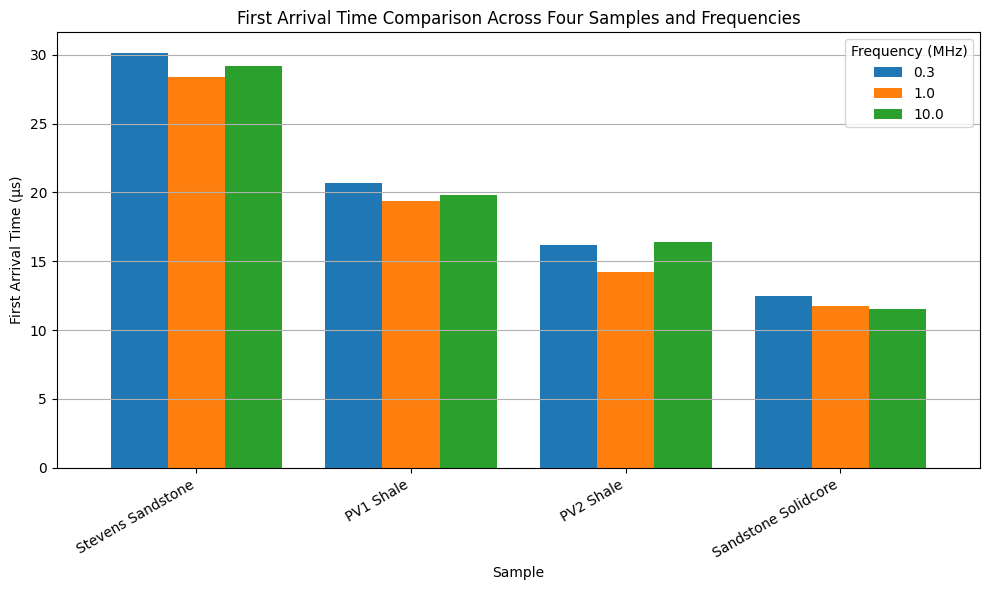

In [ ]:
# ============================================================
# Grouped bar chart: first arrival time by sample and frequency
# ============================================================

arrival_table = df.pivot_table(
    index="Physical_Sample",
    columns="Frequency_MHz",
    values="First_Arrival_Time_us",
    aggfunc="mean"
)

# Reorder rows and columns
arrival_table = arrival_table.reindex(sample_order)
arrival_table = arrival_table.reindex(columns=[0.3, 1.0, 10.0])

print("\nArrival time table:")
print(arrival_table)

ax = arrival_table.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.ylabel("First Arrival Time (µs)")
plt.xlabel("Sample")
plt.title("First Arrival Time Comparison Across Four Samples and Frequencies")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.legend(title="Frequency (MHz)")
plt.tight_layout()

plt.savefig("first_arrival_time_grouped_bar_chart.png", dpi=300)
plt.show()

In [ ]:
# COMPARING VELOCITIES (CORRECTED)#

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load first arrival summary CSV
# ============================================================

df = pd.read_csv("first_arrival_summary.csv")

# Clean column names and sample names
df.columns = df.columns.str.strip()
df["Sample_ID"] = df["Sample_ID"].astype(str).str.strip()

# Make sure numeric columns are properly read
df["Frequency_MHz"] = pd.to_numeric(df["Frequency_MHz"])
df["First_Arrival_Time_us"] = pd.to_numeric(df["First_Arrival_Time_us"])

# ============================================================
# 2. Group file/sample names into 4 real physical samples
# ============================================================

sample_name_map = {
    "NewElkhills": "Stevens Sandstone",
    "Sample_03": "Stevens Sandstone",
    "Elkhills": "Stevens Sandstone",

    "NewPV1": "PV1 Shale",
    "PV1": "PV1 Shale",

    "NewPV2": "PV2 Shale",
    "PV2": "PV2 Shale",

    "NewSandstone": "Sandstone Solidcore",
    "Sandstone": "Sandstone Solidcore"
}

df["Physical_Sample"] = df["Sample_ID"].map(sample_name_map)

# Check for unmapped samples
unmapped = df[df["Physical_Sample"].isna()]

if len(unmapped) > 0:
    print("These sample names were not mapped:")
    print(unmapped["Sample_ID"].unique())
else:
    print("All sample names mapped successfully.")

# ============================================================
# 3. Add core lengths
# Edit these lengths if your actual sample lengths are different
# ============================================================

core_length_map_cm = {
    "Stevens Sandstone": 3.5,
    "PV1 Shale": 5.0,
    "PV2 Shale": 5.0,
    "Sandstone Solidcore": 5.0
}

df["Core_Length_cm"] = df["Physical_Sample"].map(core_length_map_cm)

# ============================================================
# 4. Calculate velocity
# Velocity = core length / first arrival time
# ============================================================

df["Core_Length_m"] = df["Core_Length_cm"] / 100
df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["Velocity_m_per_s"] = df["Core_Length_m"] / df["First_Arrival_Time_s"]
df["Velocity_km_per_s"] = df["Velocity_m_per_s"] / 1000

# Show velocity table
print("\nVelocity summary:")
print(df[[
    "Sample_ID",
    "Physical_Sample",
    "Frequency_MHz",
    "Core_Length_cm",
    "First_Arrival_Time_us",
    "Velocity_m_per_s",
    "Velocity_km_per_s"
]])

# Save velocity summary
df.to_csv("velocity_summary.csv", index=False)

print("\nSaved velocity_summary.csv")

All sample names mapped successfully.

Velocity summary:
       Sample_ID      Physical_Sample  Frequency_MHz  Core_Length_cm  \
0    NewElkhills    Stevens Sandstone            0.3             3.5   
1         NewPV1            PV1 Shale            0.3             5.0   
2         NewPV2            PV2 Shale            0.3             5.0   
3   NewSandstone  Sandstone Solidcore            0.3             5.0   
4            PV1            PV1 Shale            1.0             5.0   
5            PV2            PV2 Shale            1.0             5.0   
6      Sample_03    Stevens Sandstone            1.0             3.5   
7      Sandstone  Sandstone Solidcore            1.0             5.0   
8       Elkhills    Stevens Sandstone           10.0             3.5   
9            PV1            PV1 Shale           10.0             5.0   
10           PV2            PV2 Shale           10.0             5.0   
11     Sandstone  Sandstone Solidcore           10.0             5.0   

    Fi

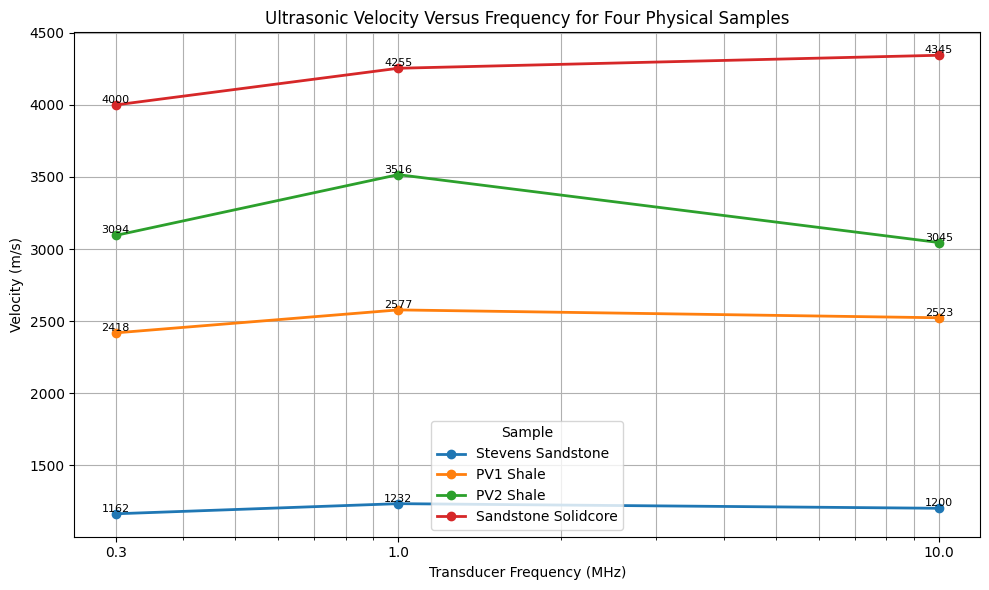

In [ ]:
# ============================================================
# 5. Line plot: velocity versus frequency
# ============================================================

sample_order = [
    "Stevens Sandstone",
    "PV1 Shale",
    "PV2 Shale",
    "Sandstone Solidcore"
]

plt.figure(figsize=(10, 6))

for sample in sample_order:
    subset = df[df["Physical_Sample"] == sample].sort_values("Frequency_MHz")

    plt.plot(
        subset["Frequency_MHz"],
        subset["Velocity_m_per_s"],
        marker="o",
        linewidth=2,
        label=sample
    )

    # Add velocity labels beside each point
    for _, row in subset.iterrows():
        plt.text(
            row["Frequency_MHz"],
            row["Velocity_m_per_s"],
            f"{row['Velocity_m_per_s']:.0f}",
            fontsize=8,
            ha="center",
            va="bottom"
        )

plt.xlabel("Transducer Frequency (MHz)")
plt.ylabel("Velocity (m/s)")
plt.title("Ultrasonic Velocity Versus Frequency for Four Physical Samples")

# Better spacing because frequencies are 0.3, 1.0, and 10.0 MHz
plt.xscale("log")
plt.xticks([0.3, 1.0, 10.0], ["0.3", "1.0", "10.0"])

plt.grid(True, which="both")
plt.legend(title="Sample")
plt.tight_layout()

plt.savefig("velocity_vs_frequency_line_plot.png", dpi=300)
plt.show()


Velocity table:
Frequency_MHz               0.3          1.0          10.0
Physical_Sample                                           
Stevens Sandstone    1162.018592  1232.394366  1200.274348
PV1 Shale            2417.794971  2577.319588  2522.704339
PV2 Shale            3094.059406  3516.174402  3045.066991
Sandstone Solidcore  4000.000000  4254.594963  4344.803615


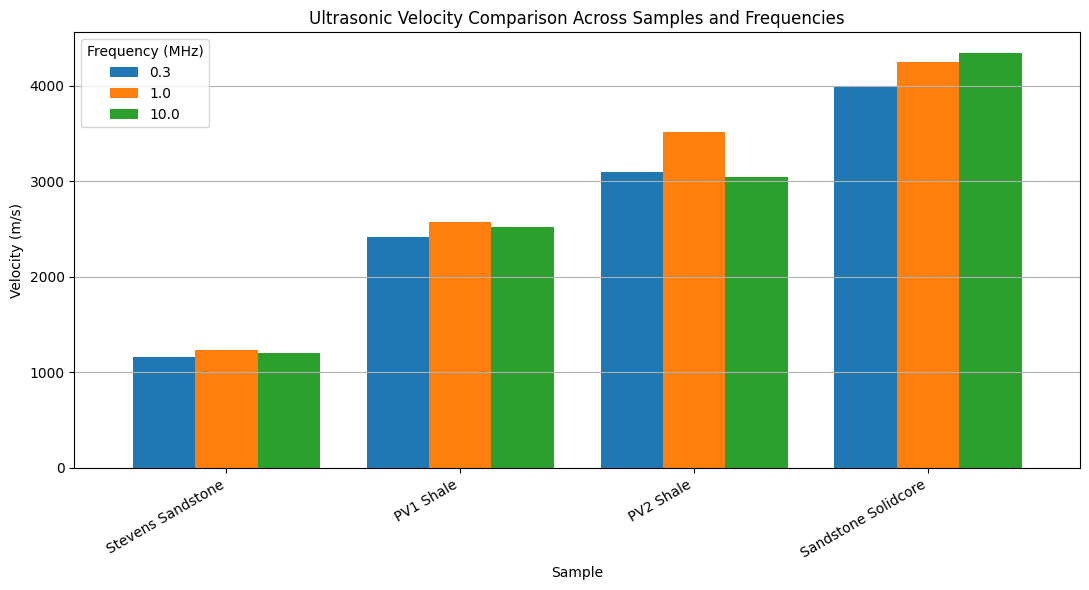

In [ ]:
# ============================================================
# 6. Grouped bar chart: velocity by sample and frequency
# ============================================================

velocity_table = df.pivot_table(
    index="Physical_Sample",
    columns="Frequency_MHz",
    values="Velocity_m_per_s",
    aggfunc="mean"
)

# Reorder rows and columns
velocity_table = velocity_table.reindex(sample_order)
velocity_table = velocity_table.reindex(columns=[0.3, 1.0, 10.0])

print("\nVelocity table:")
print(velocity_table)

ax = velocity_table.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.8
)

plt.ylabel("Velocity (m/s)")
plt.xlabel("Sample")
plt.title("Ultrasonic Velocity Comparison Across Samples and Frequencies")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.legend(title="Frequency (MHz)")
plt.tight_layout()

plt.savefig("velocity_grouped_bar_chart.png", dpi=300)
plt.show()

All sample names mapped successfully.
       Sample_ID      Physical_Sample  Frequency_MHz  First_Arrival_Time_us
0    NewElkhills    Stevens Sandstone            0.3                 30.120
1         NewPV1            PV1 Shale            0.3                 20.680
2         NewPV2            PV2 Shale            0.3                 16.160
3   NewSandstone  Sandstone Solidcore            0.3                 12.500
4            PV1            PV1 Shale            1.0                 19.400
5            PV2            PV2 Shale            1.0                 14.220
6      Sample_03    Stevens Sandstone            1.0                 28.400
7      Sandstone  Sandstone Solidcore            1.0                 11.752
8       Elkhills    Stevens Sandstone           10.0                 29.160
9            PV1            PV1 Shale           10.0                 19.820
10           PV2            PV2 Shale           10.0                 20.500
11     Sandstone  Sandstone Solidcore           10

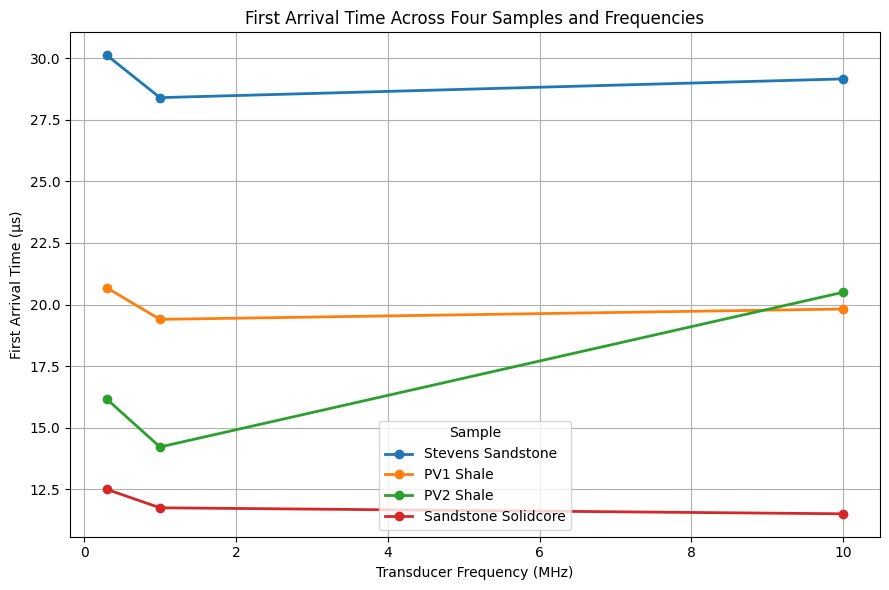

In [ ]:
# ============================================================
# Line plot: first arrival time versus frequency
# ============================================================

plt.figure(figsize=(9, 6))

sample_order = [
    "Stevens Sandstone",
    "PV1 Shale",
    "PV2 Shale",
    "Sandstone Solidcore"
]

for sample in sample_order:
    subset = df[df["Physical_Sample"] == sample].sort_values("Frequency_MHz")

    plt.plot(
        subset["Frequency_MHz"],
        subset["First_Arrival_Time_us"],
        marker="o",
        linewidth=2,
        label=sample
    )

plt.xlabel("Transducer Frequency (MHz)")
plt.ylabel("First Arrival Time (µs)")
plt.title("First Arrival Time Across Four Samples and Frequencies")
plt.grid(True)
plt.legend(title="Sample")
plt.tight_layout()

plt.savefig("first_arrival_time_4_samples_line_plot.png", dpi=300)
plt.show()

Frequency_MHz         0.3     1.0     10.0
Physical_Sample                           
Stevens Sandstone    30.12  28.400  29.160
PV1 Shale            20.68  19.400  19.820
PV2 Shale            16.16  14.220  20.500
Sandstone Solidcore  12.50  11.752  11.508


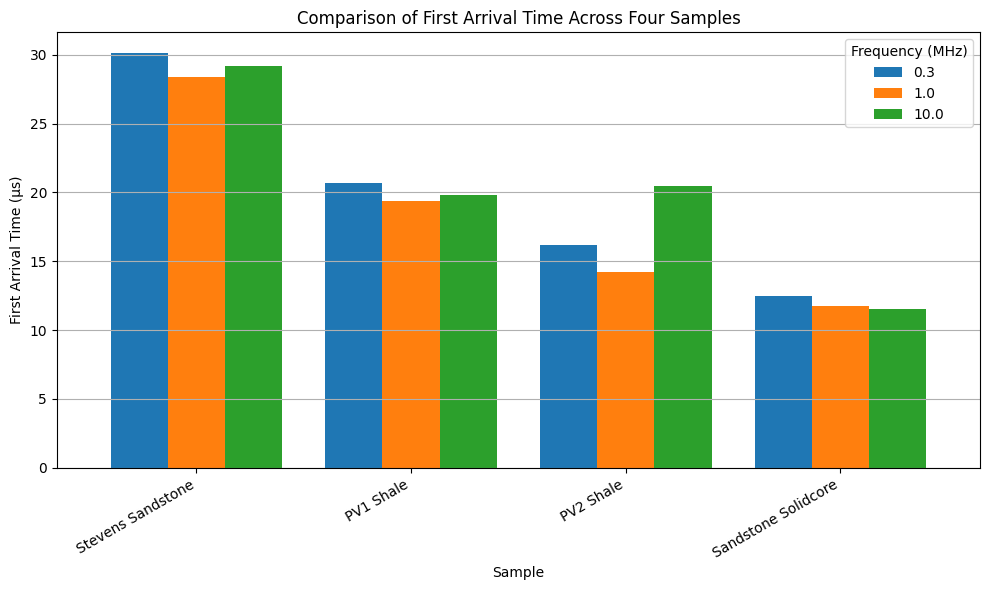

In [ ]:
# ============================================================
# Grouped bar chart: first arrival time by sample and frequency
# ============================================================

arrival_table = df.pivot_table(
    index="Physical_Sample",
    columns="Frequency_MHz",
    values="First_Arrival_Time_us",
    aggfunc="mean"
)

# Reorder rows and columns
arrival_table = arrival_table.reindex(sample_order)
arrival_table = arrival_table.reindex(columns=[0.3, 1.0, 10.0])

print(arrival_table)

ax = arrival_table.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.ylabel("First Arrival Time (µs)")
plt.xlabel("Sample")
plt.title("Comparison of First Arrival Time Across Four Samples")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.legend(title="Frequency (MHz)")
plt.tight_layout()

plt.savefig("first_arrival_time_4_samples_bar_chart.png", dpi=300)
plt.show()

In [ ]:
# COMPARING VELOCITES #

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving first_arrival_summary.csv to first_arrival_summary (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv("first_arrival_summary.csv")

print(df.head())

      Sample_ID         Core_Type  Frequency_MHz  First_Arrival_Time_us  \
0   NewElkhills  StevensSandstone            0.3                  30.12   
1        NewPV1             Shale            0.3                  20.68   
2        NewPV2             Shale            0.3                  16.16   
3  NewSandstone         Solidcore            0.3                  12.50   
4           PV1             Shale            1.0                  19.40   

   First_Arrival_Index  Voltage_at_Arrival_V  
0                 3883             -0.000555  
1                 3647             -0.002022  
2                 3884             -0.002575  
3                 3825             -0.002828  
4                 5022             -0.001065  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load your first-arrival summary table
# ============================================================

df = pd.read_csv("first_arrival_summary.csv")

print(df.head())

# ============================================================
# 2. Add core lengths for each sample
# Change these names to match your actual Sample_ID values
# ============================================================

sample_lengths_cm = {
    "Sample_02": 5.08,
    "Sample_03": 3.50,
    "PV1": 3.05,
    "PV2": 2.30,
    "NewPV1": 3.05,
    "NewPV2": 2.30,
    "NewElkhills": 3.50,
    "NewSandstone": 5.08
}

# Function to match sample length
def get_sample_length(sample_id):
    for key, length in sample_lengths_cm.items():
        if key.lower() in str(sample_id).lower():
            return length
    return np.nan

df["Core_Length_cm"] = df["Sample_ID"].apply(get_sample_length)

# ============================================================
# 3. Calculate velocity
# Velocity = length / time
# ============================================================

df["Core_Length_m"] = df["Core_Length_cm"] / 100
df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["Velocity_m_per_s"] = df["Core_Length_m"] / df["First_Arrival_Time_s"]

# Optional: convert to km/s
df["Velocity_km_per_s"] = df["Velocity_m_per_s"] / 1000

print("\nVelocity table:")
print(df[[
    "Sample_ID",
    "Core_Type",
    "Frequency_MHz",
    "Core_Length_cm",
    "First_Arrival_Time_us",
    "Velocity_m_per_s",
    "Velocity_km_per_s"
]])

# Save velocity results
df.to_csv("velocity_summary.csv", index=False)

print("\nSaved velocity results as velocity_summary.csv")

      Sample_ID         Core_Type  Frequency_MHz  First_Arrival_Time_us  \
0   NewElkhills  StevensSandstone            0.3                  30.12   
1        NewPV1             Shale            0.3                  20.68   
2        NewPV2             Shale            0.3                  16.16   
3  NewSandstone         Solidcore            0.3                  12.50   
4           PV1             Shale            1.0                  19.40   

   First_Arrival_Index  Voltage_at_Arrival_V  
0                 3883             -0.000555  
1                 3647             -0.002022  
2                 3884             -0.002575  
3                 3825             -0.002828  
4                 5022             -0.001065  

Velocity table:
       Sample_ID         Core_Type  Frequency_MHz  Core_Length_cm  \
0    NewElkhills  StevensSandstone            0.3            3.50   
1         NewPV1             Shale            0.3            3.05   
2         NewPV2             Shale         

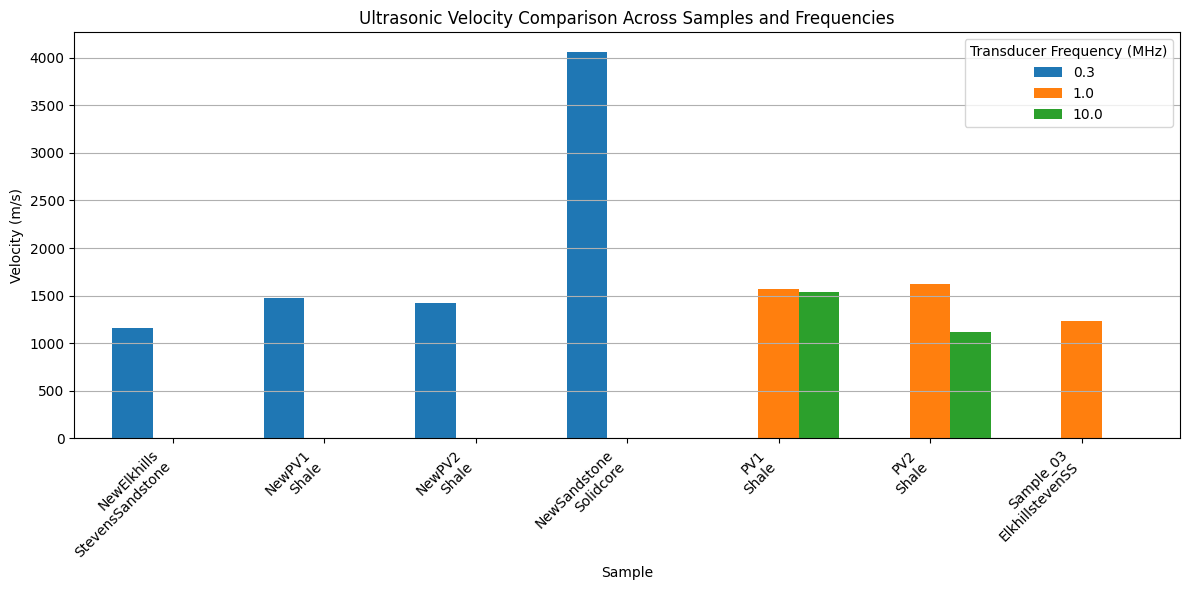

In [ ]:
# ============================================================
# Grouped bar chart: velocity by sample and frequency
# ============================================================

# Create a label combining sample and rock type
df["Sample_Label"] = df["Sample_ID"].astype(str) + "\n" + df["Core_Type"].astype(str)

# Pivot table: rows = samples, columns = frequencies
velocity_table = df.pivot_table(
    index="Sample_Label",
    columns="Frequency_MHz",
    values="Velocity_m_per_s",
    aggfunc="mean"
)

# Plot grouped bar chart
ax = velocity_table.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.ylabel("Velocity (m/s)")
plt.xlabel("Sample")
plt.title("Ultrasonic Velocity Comparison Across Samples and Frequencies")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.legend(title="Transducer Frequency (MHz)")
plt.tight_layout()

plt.savefig("velocity_grouped_bar_chart.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load first arrival summary
df = pd.read_csv("first_arrival_summary.csv")

# ============================================================
# Map different file/sample names to the 4 real physical samples
# ============================================================

sample_info = {
    "NewElkhills": {"Physical_Sample": "Stevens Sandstone", "Core_Length_cm": 3.50},
    "Sample_03": {"Physical_Sample": "Stevens Sandstone", "Core_Length_cm": 3.50},
    "Elkhills": {"Physical_Sample": "Stevens Sandstone", "Core_Length_cm": 3.50},

    "NewPV1": {"Physical_Sample": "PV1 Shale", "Core_Length_cm": 3.05},
    "PV1": {"Physical_Sample": "PV1 Shale", "Core_Length_cm": 3.05},

    "NewPV2": {"Physical_Sample": "PV2 Shale", "Core_Length_cm": 2.30},
    "PV2": {"Physical_Sample": "PV2 Shale", "Core_Length_cm": 2.30},

    "NewSandstone": {"Physical_Sample": "Sandstone Solidcore", "Core_Length_cm": 5.08},
    "Sandstone": {"Physical_Sample": "Sandstone Solidcore", "Core_Length_cm": 5.08}
}

# Add physical sample name and core length
df["Physical_Sample"] = df["Sample_ID"].map(lambda x: sample_info[x]["Physical_Sample"])
df["Core_Length_cm"] = df["Sample_ID"].map(lambda x: sample_info[x]["Core_Length_cm"])

# ============================================================
# Calculate velocity
# Velocity = length / time
# ============================================================

df["Core_Length_m"] = df["Core_Length_cm"] / 100
df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["Velocity_m_per_s"] = df["Core_Length_m"] / df["First_Arrival_Time_s"]
df["Velocity_km_per_s"] = df["Velocity_m_per_s"] / 1000

print(df[[
    "Sample_ID",
    "Physical_Sample",
    "Core_Type",
    "Frequency_MHz",
    "Core_Length_cm",
    "First_Arrival_Time_us",
    "Velocity_m_per_s",
    "Velocity_km_per_s"
]])

# Save velocity summary
df.to_csv("velocity_summary.csv", index=False)

       Sample_ID      Physical_Sample         Core_Type  Frequency_MHz  \
0    NewElkhills    Stevens Sandstone  StevensSandstone            0.3   
1         NewPV1            PV1 Shale             Shale            0.3   
2         NewPV2            PV2 Shale             Shale            0.3   
3   NewSandstone  Sandstone Solidcore         Solidcore            0.3   
4            PV1            PV1 Shale             Shale            1.0   
5            PV2            PV2 Shale             Shale            1.0   
6      Sample_03    Stevens Sandstone   ElkhillstevenSS            1.0   
7      Sandstone  Sandstone Solidcore         Solidcore            1.0   
8       Elkhills    Stevens Sandstone  StevensSandstone           10.0   
9            PV1            PV1 Shale             Shale           10.0   
10           PV2            PV2 Shale             Shale           10.0   
11     Sandstone  Sandstone Solidcore         Solidcore           10.0   

    Core_Length_cm  First_Arrival_Tim

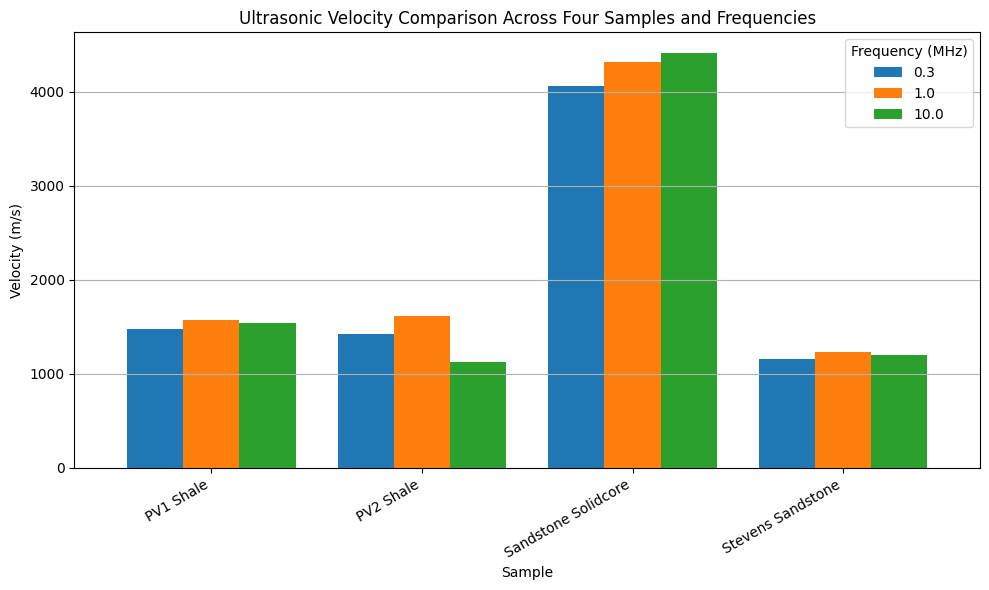

In [ ]:
# ============================================================
# Grouped bar chart: velocity by physical sample and frequency
# ============================================================

velocity_table = df.pivot_table(
    index="Physical_Sample",
    columns="Frequency_MHz",
    values="Velocity_m_per_s",
    aggfunc="mean"
)

ax = velocity_table.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

plt.ylabel("Velocity (m/s)")
plt.xlabel("Sample")
plt.title("Ultrasonic Velocity Comparison Across Four Samples and Frequencies")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.legend(title="Frequency (MHz)")
plt.tight_layout()

plt.savefig("velocity_grouped_bar_chart.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Load first arrival summary
# ============================================================

df = pd.read_csv("first_arrival_summary.csv")

# Clean sample names
df["Sample_ID"] = df["Sample_ID"].astype(str).str.strip()

# ============================================================
# 2. Map CSV sample names to the 4 real physical samples
# ============================================================

sample_name_map = {
    "NewElkhills": "Stevens Sandstone",
    "Sample_03": "Stevens Sandstone",
    "Elkhills": "Stevens Sandstone",

    "NewPV1": "PV1 Shale",
    "PV1": "PV1 Shale",

    "NewPV2": "PV2 Shale",
    "PV2": "PV2 Shale",

    "NewSandstone": "Sandstone Solidcore",
    "Sandstone": "Sandstone Solidcore"
}

core_length_map_cm = {
    "Stevens Sandstone": 3.5,
    "PV1 Shale": 5.0,
    "PV2 Shale": 5.0,
    "Sandstone Solidcore": 5.0
}

df["Physical_Sample"] = df["Sample_ID"].map(sample_name_map)
df["Core_Length_cm"] = df["Physical_Sample"].map(core_length_map_cm)

# Check for unmapped samples
unmapped = df[df["Physical_Sample"].isna()]
if len(unmapped) > 0:
    print("These sample names were not mapped:")
    print(unmapped["Sample_ID"].unique())

# ============================================================
# 3. Calculate velocity
# ============================================================

df["Core_Length_m"] = df["Core_Length_cm"] / 100
df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["Velocity_m_per_s"] = df["Core_Length_m"] / df["First_Arrival_Time_s"]
df["Velocity_km_per_s"] = df["Velocity_m_per_s"] / 1000

# Show calculated velocity table
print(df[[
    "Sample_ID",
    "Physical_Sample",
    "Frequency_MHz",
    "Core_Length_cm",
    "First_Arrival_Time_us",
    "Velocity_m_per_s",
    "Velocity_km_per_s"
]])

# Save velocity summary
df.to_csv("velocity_summary.csv", index=False)

print("Velocity summary saved as velocity_summary.csv")

       Sample_ID      Physical_Sample  Frequency_MHz  Core_Length_cm  \
0    NewElkhills    Stevens Sandstone            0.3             3.5   
1         NewPV1            PV1 Shale            0.3             5.0   
2         NewPV2            PV2 Shale            0.3             5.0   
3   NewSandstone  Sandstone Solidcore            0.3             5.0   
4            PV1            PV1 Shale            1.0             5.0   
5            PV2            PV2 Shale            1.0             5.0   
6      Sample_03    Stevens Sandstone            1.0             3.5   
7      Sandstone  Sandstone Solidcore            1.0             5.0   
8       Elkhills    Stevens Sandstone           10.0             3.5   
9            PV1            PV1 Shale           10.0             5.0   
10           PV2            PV2 Shale           10.0             5.0   
11     Sandstone  Sandstone Solidcore           10.0             5.0   

    First_Arrival_Time_us  Velocity_m_per_s  Velocity_km_per_s 

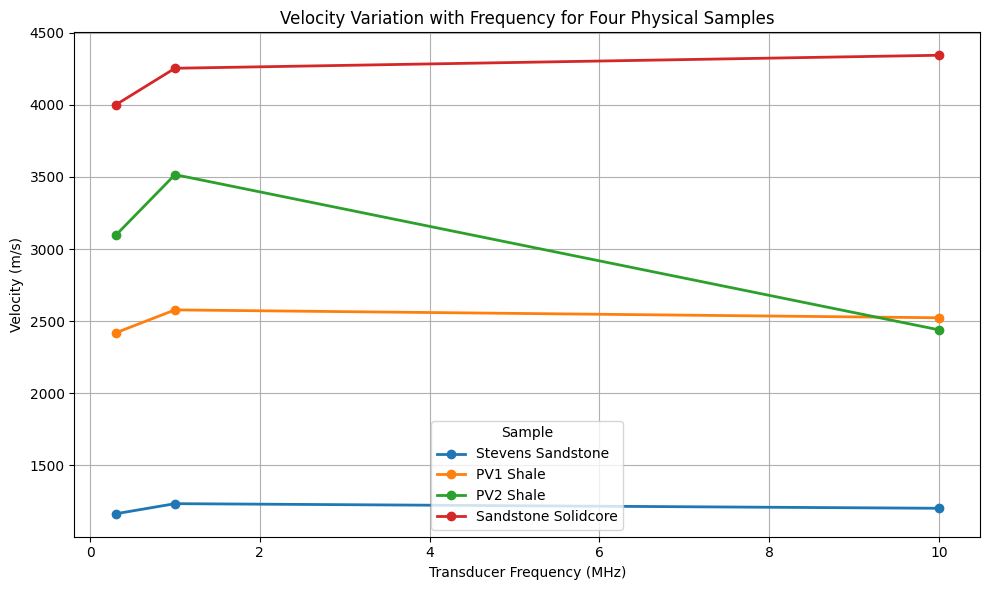

In [ ]:
# ============================================================
# 4. Line plot: velocity versus frequency for each physical sample
# ============================================================

plt.figure(figsize=(10, 6))

sample_order = [
    "Stevens Sandstone",
    "PV1 Shale",
    "PV2 Shale",
    "Sandstone Solidcore"
]

for sample in sample_order:
    subset = df[df["Physical_Sample"] == sample].sort_values("Frequency_MHz")

    plt.plot(
        subset["Frequency_MHz"],
        subset["Velocity_m_per_s"],
        marker="o",
        linewidth=2,
        label=sample
    )

plt.xlabel("Transducer Frequency (MHz)")
plt.ylabel("Velocity (m/s)")
plt.title("Velocity Variation with Frequency for Four Physical Samples")
plt.grid(True)
plt.legend(title="Sample")
plt.tight_layout()

plt.savefig("velocity_vs_frequency_4_samples.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Dry3_SSSample_Synthetic_PowderCore_0.1MHz_CH1_20260729_125153.csv to Dry3_SSSample_Synthetic_PowderCore_0.1MHz_CH1_20260729_125153.csv
Saving Sat_SSSamplePwave_Synthetic_PowderCore_0.1MHz_CH1_20260729_145908.csv to Sat_SSSamplePwave_Synthetic_PowderCore_0.1MHz_CH1_20260729_145908.csv


First arrival index: 744
First arrival time (seconds): 5.04e-06
First arrival time (microseconds): 5.04
Voltage at first arrival: 0.02953125


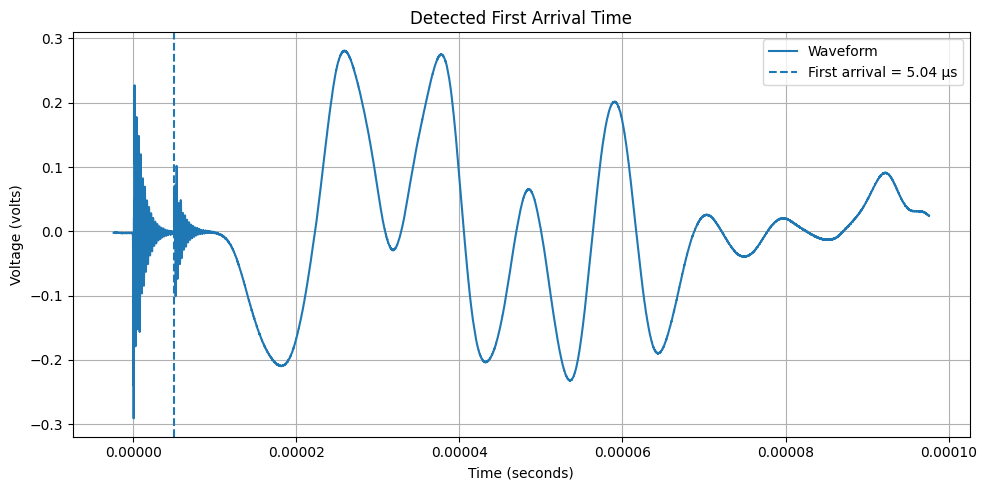

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Load CSV file
# ============================================================

csv_file = "Dry3_SSSample_Synthetic_PowderCore_0.1MHz_CH1_20260729_125153.csv"  # Change to your actual CSV file name
df = pd.read_csv(csv_file)

time = df["Time_seconds"].values
voltage = df["Voltage_volts"].values

# ============================================================
# Define noise window
# Use only the pre-trigger region, where time < 0
# ============================================================

noise_region = voltage[time < 0]

noise_mean = np.mean(noise_region)
noise_std = np.std(noise_region)

# ============================================================
# Set threshold
# Increase this if it picks noise too early
# Decrease this if it misses the arrival
# ============================================================

threshold_multiplier = 5
threshold = threshold_multiplier * noise_std

signal_strength = np.abs(voltage - noise_mean)

# ============================================================
# Search only after time zero
# ============================================================

search_start_time_us = 5
search_start_time_s = search_start_time_us * 1e-6

search_indices = np.where(time >= search_start_time_s)[0]

arrival_index = None

for i in search_indices:
    if signal_strength[i] > threshold:
        arrival_index = i
        break

# ============================================================
# Print and plot result
# ============================================================

if arrival_index is None:
    print("No first arrival detected. Try lowering the threshold multiplier.")
else:
    first_arrival_time = time[arrival_index]
    first_arrival_voltage = voltage[arrival_index]

    print("First arrival index:", arrival_index)
    print("First arrival time (seconds):", first_arrival_time)
    print("First arrival time (microseconds):", first_arrival_time * 1e6)
    print("Voltage at first arrival:", first_arrival_voltage)

    plt.figure(figsize=(10, 5))
    plt.plot(time, voltage, label="Waveform")

    plt.axvline(
        first_arrival_time,
        linestyle="--",
        label=f"First arrival = {first_arrival_time * 1e6:.2f} µs"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Voltage (volts)")
    plt.title("Detected First Arrival Time")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Waveform files found:
Dry3_SSSample_Synthetic_PowderCore_0.1MHz_CH1_20260729_125153.csv
Sat_SSSamplePwave_Synthetic_PowderCore_0.1MHz_CH1_20260729_145908.csv

First arrival summary:
                                                File  Condition  \
0  Dry3_SSSample_Synthetic_PowderCore_0.1MHz_CH1_...        Dry   
1  Sat_SSSamplePwave_Synthetic_PowderCore_0.1MHz_...  Saturated   

           Sample_ID             Core_Type  Frequency_MHz  \
0      Dry3_SSSample  Synthetic_PowderCore            0.1   
1  Sat_SSSamplePwave  Synthetic_PowderCore            0.1   

   First_Arrival_Time_us  First_Arrival_Index  Voltage_at_Arrival_V  
0                  12.25                 1465             -0.029203  
1                   9.39                 1179             -0.032063  

Saved: pwave_dry_saturated_first_arrival_summary.csv


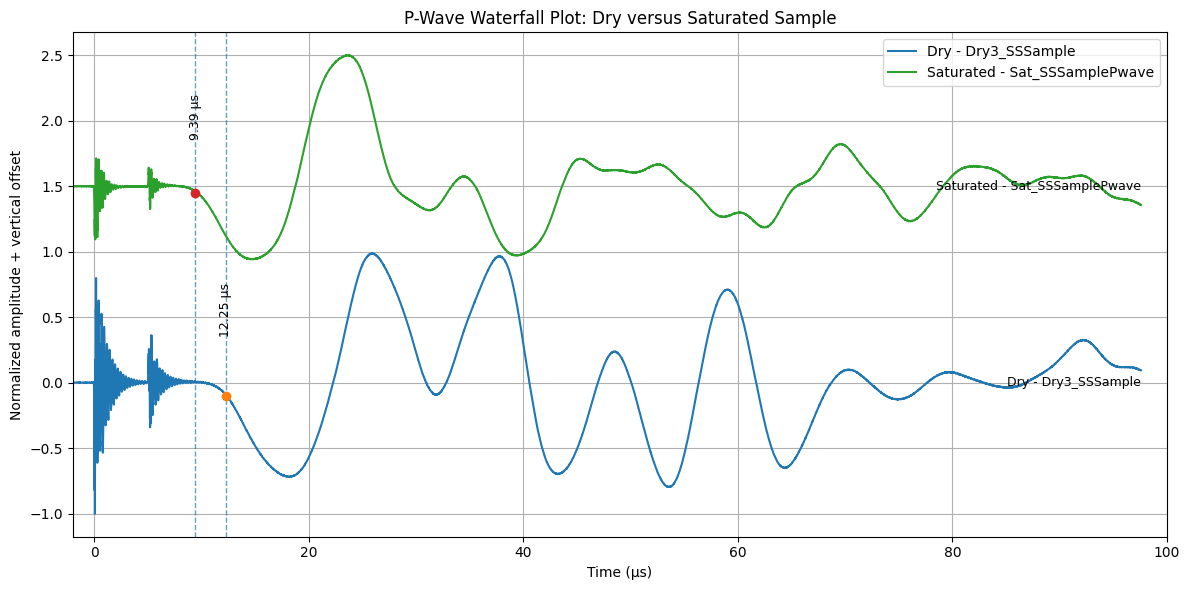


Saved: pwave_dry_saturated_waterfall_plot.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# 1. Folder containing your waveform CSV files
# ============================================================

# Use "." if the CSV files are in the same folder as this code
DATA_FOLDER = Path(".")

# This code will automatically find waveform CSV files
all_csv_files = sorted(DATA_FOLDER.glob("*.csv"))

waveform_files = []

for file in all_csv_files:
    test_df = pd.read_csv(file, nrows=1)
    test_df.columns = test_df.columns.str.strip()

    if "Time_seconds" in test_df.columns and "Voltage_volts" in test_df.columns:
        waveform_files.append(file)
    else:
        print("Skipping non-waveform file:", file.name)

print("Waveform files found:")
for file in waveform_files:
    print(file.name)

# ============================================================
# 2. First-arrival detection settings
# ============================================================

# Start searching after the early electrical spike/crosstalk
# For your dry and saturated P-wave data, 8 microseconds is a good starting point
SEARCH_START_US = 8
SEARCH_END_US = 80

# Increase this if the code picks noise too early
# Decrease this if the code misses the first arrival
THRESHOLD_MULTIPLIER = 5

# ============================================================
# 3. Function to detect first arrival
# ============================================================

def detect_first_arrival(time_us, voltage):
    """
    Detects the first arrival using a noise-based threshold.
    """

    # Use pre-trigger region as noise
    noise_mask = time_us < 0

    if np.sum(noise_mask) > 10:
        noise = voltage[noise_mask]
    else:
        noise = voltage[:int(0.1 * len(voltage))]

    noise_mean = np.mean(noise)
    noise_std = np.std(noise)

    threshold = THRESHOLD_MULTIPLIER * noise_std

    signal_strength = np.abs(voltage - noise_mean)

    search_indices = np.where(
        (time_us >= SEARCH_START_US) &
        (time_us <= SEARCH_END_US)
    )[0]

    arrival_index = None

    for i in search_indices:
        if signal_strength[i] > threshold:
            arrival_index = i
            break

    if arrival_index is None:
        return None, None, None, noise_mean, threshold

    arrival_time_us = time_us[arrival_index]
    arrival_voltage = voltage[arrival_index]

    return arrival_index, arrival_time_us, arrival_voltage, noise_mean, threshold

# ============================================================
# 4. Read files, detect first arrivals, and store results
# ============================================================

waveform_data = []
arrival_results = []

for file in waveform_files:
    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    sample_id = str(df["Sample_ID"].iloc[0])
    core_type = str(df["Core_Type"].iloc[0])
    frequency = float(df["Transducer_Frequency_MHz"].iloc[0])

    # Label dry and saturated samples clearly
    if "dry" in sample_id.lower():
        condition = "Dry"
    elif "sat" in sample_id.lower():
        condition = "Saturated"
    else:
        condition = sample_id

    arrival_index, arrival_time_us, arrival_voltage, noise_mean, threshold = detect_first_arrival(
        time_us,
        voltage
    )

    waveform_data.append({
        "file": file.name,
        "condition": condition,
        "sample_id": sample_id,
        "core_type": core_type,
        "frequency": frequency,
        "time_us": time_us,
        "voltage": voltage,
        "arrival_index": arrival_index,
        "arrival_time_us": arrival_time_us,
        "arrival_voltage": arrival_voltage
    })

    arrival_results.append({
        "File": file.name,
        "Condition": condition,
        "Sample_ID": sample_id,
        "Core_Type": core_type,
        "Frequency_MHz": frequency,
        "First_Arrival_Time_us": arrival_time_us,
        "First_Arrival_Index": arrival_index,
        "Voltage_at_Arrival_V": arrival_voltage
    })

arrival_df = pd.DataFrame(arrival_results)

print("\nFirst arrival summary:")
print(arrival_df)

arrival_df.to_csv("pwave_dry_saturated_first_arrival_summary.csv", index=False)

print("\nSaved: pwave_dry_saturated_first_arrival_summary.csv")

# ============================================================
# 5. Create waterfall plot
# ============================================================

plt.figure(figsize=(12, 6))

vertical_spacing = 1.5

for i, data in enumerate(waveform_data):

    time_us = data["time_us"]
    voltage = data["voltage"]

    # Baseline correction
    noise_mask = time_us < 0

    if np.sum(noise_mask) > 10:
        baseline = np.mean(voltage[noise_mask])
    else:
        baseline = np.mean(voltage[:int(0.1 * len(voltage))])

    voltage_corrected = voltage - baseline

    # Normalize each waveform so both dry and saturated traces are easy to see
    max_amp = np.max(np.abs(voltage_corrected))

    if max_amp == 0:
        voltage_normalized = voltage_corrected
    else:
        voltage_normalized = voltage_corrected / max_amp

    offset = i * vertical_spacing

    label = f"{data['condition']} - {data['sample_id']}"

    plt.plot(
        time_us,
        voltage_normalized + offset,
        linewidth=1.5,
        label=label
    )

    # Plot first arrival marker
    if data["arrival_time_us"] is not None:
        plt.axvline(
            data["arrival_time_us"],
            linestyle="--",
            linewidth=1,
            alpha=0.7
        )

        plt.plot(
            data["arrival_time_us"],
            data["arrival_voltage"] / max_amp + offset,
            marker="o",
            markersize=6
        )

        plt.text(
            data["arrival_time_us"],
            offset + 0.35,
            f"{data['arrival_time_us']:.2f} µs",
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=9
        )

    # Add trace label on the right side
    plt.text(
        time_us.max(),
        offset,
        label,
        va="center",
        ha="right",
        fontsize=9
    )

# ============================================================
# 6. Plot formatting
# ============================================================

plt.xlabel("Time (µs)")
plt.ylabel("Normalized amplitude + vertical offset")
plt.title("P-Wave Waterfall Plot: Dry versus Saturated Sample")

plt.xlim(-2, 100)
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig("pwave_dry_saturated_waterfall_plot.png", dpi=300)
plt.show()

print("\nSaved: pwave_dry_saturated_waterfall_plot.png")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Sat3_SSSampleSwave_Synthetic_Powdercore_0.1MHz_CH1_20260729_154053.csv to Sat3_SSSampleSwave_Synthetic_Powdercore_0.1MHz_CH1_20260729_154053.csv
Saving Sat4_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260730_133613.csv to Sat4_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260730_133613.csv
Saving Sat5_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_111751.csv to Sat5_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_111751.csv



S-wave arrival summary:
  Replicate           Sample_ID Wave_Type  First_Arrival_Time_us  \
0      Sat3  Sat3_SSSampleSwave    S-wave                  27.24   
1      Sat4       Sat4_SSSample    S-wave                  25.98   
2      Sat5  Sat5_SSSampleSwave    S-wave                  47.32   

   First_Arrival_Index              Pick_Type  
0                 3054  Automatic window pick  
1                 4028  Automatic window pick  
2                 5592  Automatic window pick  


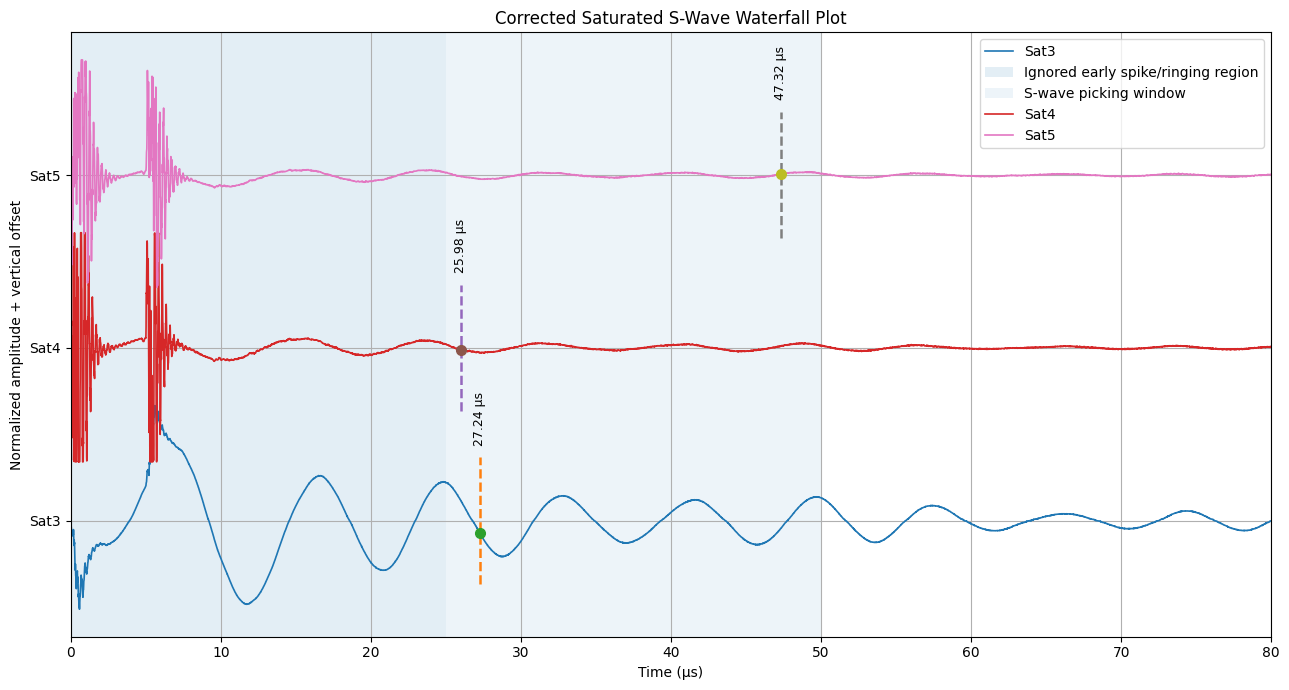


Saved files:
corrected_swave_waterfall_plot.png
corrected_swave_arrival_summary.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Your three saturated S-wave files
# ============================================================

csv_files = [
    "Sat3_SSSampleSwave_Synthetic_Powdercore_0.1MHz_CH1_20260729_154053.csv",
    "Sat4_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260730_133613.csv",
    "Sat5_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_111751.csv"
]

# ============================================================
# 2. IMPORTANT: set the S-wave arrival search window
# ============================================================

# Do not search near 0 us because that region contains electrical spike/crosstalk.
# Your P-wave was around 9.39 us, so S-wave must be later.
# If your expected S-wave is around 35.7 us, this window is safer.
S_SEARCH_START_US = 25.0
S_SEARCH_END_US = 50.0

# Plot range
PLOT_START_US = 0
PLOT_END_US = 80

# ============================================================
# 3. Manual picks option
# ============================================================

# After looking at the plot, enter your visually confirmed S-wave picks here.
# Leave as None if you want the code to estimate within the search window.
#
# Example:
# MANUAL_PICKS_US = {
#     "Sat3": 35.7,
#     "Sat4": 36.2,
#     "Sat5": 35.9
# }

MANUAL_PICKS_US = {
    "Sat3": None,
    "Sat4": None,
    "Sat5": None
}

# ============================================================
# 4. Function to calculate smoothed envelope
# ============================================================

def moving_average(x, window_points):
    window_points = int(window_points)

    if window_points < 3:
        window_points = 3

    if window_points % 2 == 0:
        window_points += 1

    kernel = np.ones(window_points) / window_points
    return np.convolve(x, kernel, mode="same")


# ============================================================
# 5. Careful arrival picker inside ONLY the S-wave window
# ============================================================

def pick_swave_arrival(time_us, voltage_corrected):
    """
    This only searches inside the S-wave window.
    It will not pick the early electrical spike near 0 us.
    """

    dt_us = np.median(np.diff(time_us))

    # Build envelope
    smoothing_window_us = 0.50
    smoothing_points = int(smoothing_window_us / dt_us)
    envelope = moving_average(np.abs(voltage_corrected), smoothing_points)

    # Search only inside the S-wave window
    search_mask = (
        (time_us >= S_SEARCH_START_US) &
        (time_us <= S_SEARCH_END_US)
    )

    search_indices = np.where(search_mask)[0]

    if len(search_indices) == 0:
        return None, None, envelope

    # Use the quiet part before the S-wave window as reference
    reference_mask = (
        (time_us >= 15.0) &
        (time_us < S_SEARCH_START_US)
    )

    if np.sum(reference_mask) > 20:
        reference_level = np.median(envelope[reference_mask])
        reference_noise = np.std(envelope[reference_mask])
    else:
        reference_level = np.median(envelope)
        reference_noise = np.std(envelope)

    threshold = reference_level + 3.0 * reference_noise

    # Find first point inside the S-wave window above threshold
    arrival_index = None

    for i in search_indices:
        if envelope[i] > threshold:
            arrival_index = i
            break

    # If threshold method fails, use strongest envelope increase inside window
    if arrival_index is None:
        window_envelope = envelope[search_indices]
        gradient = np.gradient(window_envelope)
        arrival_index = search_indices[np.argmax(gradient)]

    arrival_time_us = time_us[arrival_index]

    return arrival_index, arrival_time_us, envelope


# ============================================================
# 6. Read files and process waveforms
# ============================================================

records = []
summary = []

for file in csv_files:

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    sample_id = str(df["Sample_ID"].iloc[0])

    # Identify replicate name
    if "Sat3" in file:
        rep = "Sat3"
    elif "Sat4" in file:
        rep = "Sat4"
    elif "Sat5" in file:
        rep = "Sat5"
    else:
        rep = sample_id

    # Baseline correction using pre-trigger region
    pretrigger_mask = time_us < 0

    if np.sum(pretrigger_mask) > 20:
        baseline = np.median(voltage[pretrigger_mask])
    else:
        baseline = np.median(voltage[:500])

    voltage_corrected = voltage - baseline

    # Automatic pick inside the S-wave window
    arrival_index, arrival_time_us, envelope = pick_swave_arrival(
        time_us,
        voltage_corrected
    )

    pick_type = "Automatic window pick"

    # Manual pick overrides automatic pick
    if MANUAL_PICKS_US[rep] is not None:
        arrival_time_us = MANUAL_PICKS_US[rep]
        arrival_index = np.argmin(np.abs(time_us - arrival_time_us))
        pick_type = "Manual pick"

    records.append({
        "file": file,
        "rep": rep,
        "sample_id": sample_id,
        "time_us": time_us,
        "voltage_corrected": voltage_corrected,
        "envelope": envelope,
        "arrival_index": arrival_index,
        "arrival_time_us": arrival_time_us,
        "pick_type": pick_type
    })

    summary.append({
        "Replicate": rep,
        "Sample_ID": sample_id,
        "Wave_Type": "S-wave",
        "First_Arrival_Time_us": arrival_time_us,
        "First_Arrival_Index": arrival_index,
        "Pick_Type": pick_type
    })

summary_df = pd.DataFrame(summary)

print("\nS-wave arrival summary:")
print(summary_df)

summary_df.to_csv("corrected_swave_arrival_summary.csv", index=False)

# ============================================================
# 7. Waterfall plot
# ============================================================

plt.figure(figsize=(13, 7))

vertical_spacing = 1.5
yticks = []
yticklabels = []

for i, rec in enumerate(records):

    time_us = rec["time_us"]
    voltage_corrected = rec["voltage_corrected"]

    plot_mask = (
        (time_us >= PLOT_START_US) &
        (time_us <= PLOT_END_US)
    )

    max_amp = np.max(np.abs(voltage_corrected[plot_mask]))

    if max_amp == 0:
        voltage_norm = voltage_corrected
    else:
        voltage_norm = voltage_corrected / max_amp

    offset = i * vertical_spacing

    plt.plot(
        time_us[plot_mask],
        voltage_norm[plot_mask] + offset,
        linewidth=1.2,
        label=rec["rep"]
    )

    yticks.append(offset)
    yticklabels.append(rec["rep"])

    # Shade ignored early region
    if i == 0:
        plt.axvspan(
            PLOT_START_US,
            S_SEARCH_START_US,
            alpha=0.12,
            label="Ignored early spike/ringing region"
        )

        plt.axvspan(
            S_SEARCH_START_US,
            S_SEARCH_END_US,
            alpha=0.08,
            label="S-wave picking window"
        )

    # Plot arrival marker
    if rec["arrival_time_us"] is not None:

        arrival_time = rec["arrival_time_us"]
        arrival_index = rec["arrival_index"]

        plt.plot(
            [arrival_time, arrival_time],
            [offset - 0.55, offset + 0.55],
            linestyle="--",
            linewidth=1.8
        )

        plt.plot(
            arrival_time,
            voltage_norm[arrival_index] + offset,
            marker="o",
            markersize=7
        )

        plt.text(
            arrival_time,
            offset + 0.65,
            f"{arrival_time:.2f} µs",
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Time (µs)")
plt.ylabel("Normalized amplitude + vertical offset")
plt.title("Corrected Saturated S-Wave Waterfall Plot")
plt.xlim(PLOT_START_US, PLOT_END_US)
plt.yticks(yticks, yticklabels)
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig("corrected_swave_waterfall_plot.png", dpi=300)
plt.show()

print("\nSaved files:")
print("corrected_swave_waterfall_plot.png")
print("corrected_swave_arrival_summary.csv")


S-wave arrival summary:
  Replicate           Sample_ID Wave_Type  First_Arrival_Time_us  \
0      Sat3  Sat3_SSSampleSwave    S-wave                  27.24   
1      Sat4       Sat4_SSSample    S-wave                  25.98   
2      Sat5  Sat5_SSSampleSwave    S-wave                  26.54   

   First_Arrival_Index              Pick_Type  
0                 3054  Automatic window pick  
1                 4028  Automatic window pick  
2                 3514            Manual pick  


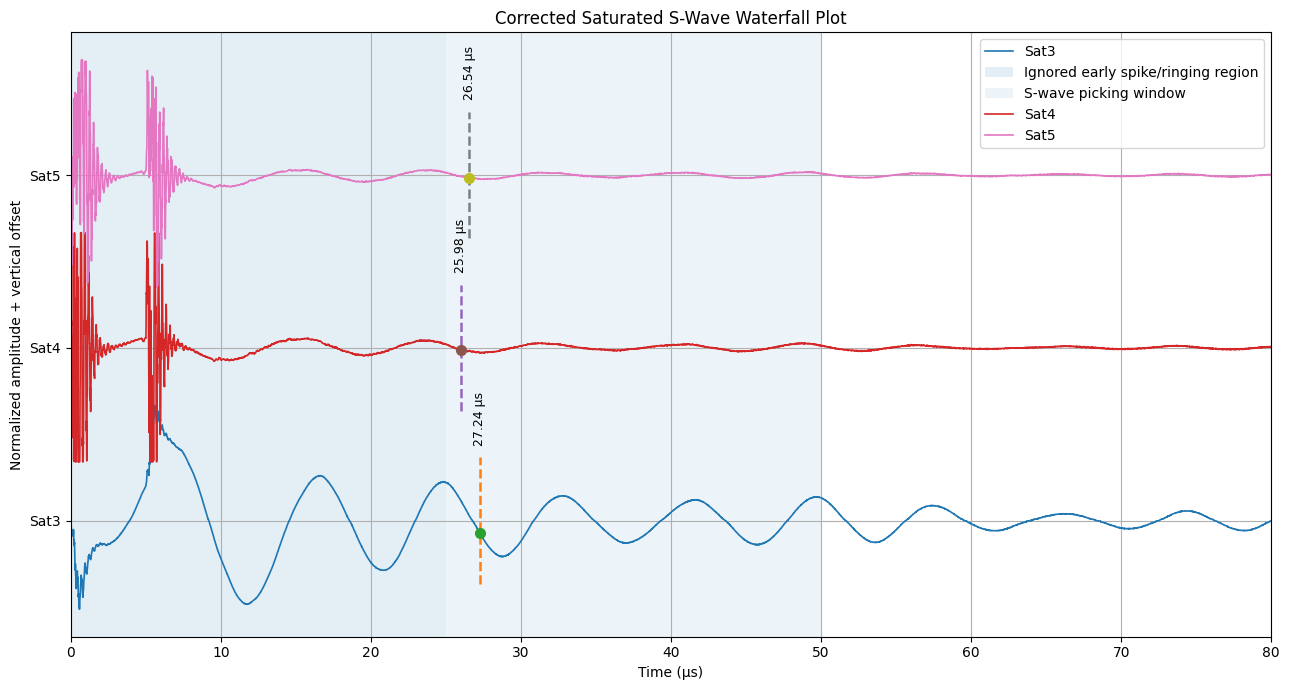


Saved files:
corrected_swave_waterfall_plot.png
corrected_swave_arrival_summary.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Your three saturated S-wave files
# ============================================================

csv_files = [
    "Sat3_SSSampleSwave_Synthetic_Powdercore_0.1MHz_CH1_20260729_154053.csv",
    "Sat4_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260730_133613.csv",
    "Sat5_SSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_111751.csv"
]

# ============================================================
# 2. IMPORTANT: set the S-wave arrival search window
# ============================================================

# Do not search near 0 us because that region contains electrical spike/crosstalk.
# Your P-wave was around 9.39 us, so S-wave must be later.
# If your expected S-wave is around 35.7 us, this window is safer.
S_SEARCH_START_US = 25.0
S_SEARCH_END_US = 50.0

# Plot range
PLOT_START_US = 0
PLOT_END_US = 80

# ============================================================
# 3. Manual picks option
# ============================================================

# After looking at the plot, enter your visually confirmed S-wave picks here.
# Leave as None if you want the code to estimate within the search window.
#
# Example:
# MANUAL_PICKS_US = {
#     "Sat3": 35.7,
#     "Sat4": 36.2,
#     "Sat5": 35.9
# }

MANUAL_PICKS_US = {
    "Sat3": None,
    "Sat4": None,
    "Sat5": 26.54
}

# ============================================================
# 4. Function to calculate smoothed envelope
# ============================================================

def moving_average(x, window_points):
    window_points = int(window_points)

    if window_points < 3:
        window_points = 3

    if window_points % 2 == 0:
        window_points += 1

    kernel = np.ones(window_points) / window_points
    return np.convolve(x, kernel, mode="same")


# ============================================================
# 5. Careful arrival picker inside ONLY the S-wave window
# ============================================================

def pick_swave_arrival(time_us, voltage_corrected):
    """
    This only searches inside the S-wave window.
    It will not pick the early electrical spike near 0 us.
    """

    dt_us = np.median(np.diff(time_us))

    # Build envelope
    smoothing_window_us = 0.50
    smoothing_points = int(smoothing_window_us / dt_us)
    envelope = moving_average(np.abs(voltage_corrected), smoothing_points)

    # Search only inside the S-wave window
    search_mask = (
        (time_us >= S_SEARCH_START_US) &
        (time_us <= S_SEARCH_END_US)
    )

    search_indices = np.where(search_mask)[0]

    if len(search_indices) == 0:
        return None, None, envelope

    # Use the quiet part before the S-wave window as reference
    reference_mask = (
        (time_us >= 15.0) &
        (time_us < S_SEARCH_START_US)
    )

    if np.sum(reference_mask) > 20:
        reference_level = np.median(envelope[reference_mask])
        reference_noise = np.std(envelope[reference_mask])
    else:
        reference_level = np.median(envelope)
        reference_noise = np.std(envelope)

    threshold = reference_level + 3.0 * reference_noise

    # Find first point inside the S-wave window above threshold
    arrival_index = None

    for i in search_indices:
        if envelope[i] > threshold:
            arrival_index = i
            break

    # If threshold method fails, use strongest envelope increase inside window
    if arrival_index is None:
        window_envelope = envelope[search_indices]
        gradient = np.gradient(window_envelope)
        arrival_index = search_indices[np.argmax(gradient)]

    arrival_time_us = time_us[arrival_index]

    return arrival_index, arrival_time_us, envelope


# ============================================================
# 6. Read files and process waveforms
# ============================================================

records = []
summary = []

for file in csv_files:

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    sample_id = str(df["Sample_ID"].iloc[0])

    # Identify replicate name
    if "Sat3" in file:
        rep = "Sat3"
    elif "Sat4" in file:
        rep = "Sat4"
    elif "Sat5" in file:
        rep = "Sat5"
    else:
        rep = sample_id

    # Baseline correction using pre-trigger region
    pretrigger_mask = time_us < 0

    if np.sum(pretrigger_mask) > 20:
        baseline = np.median(voltage[pretrigger_mask])
    else:
        baseline = np.median(voltage[:500])

    voltage_corrected = voltage - baseline

    # Automatic pick inside the S-wave window
    arrival_index, arrival_time_us, envelope = pick_swave_arrival(
        time_us,
        voltage_corrected
    )

    pick_type = "Automatic window pick"

    # Manual pick overrides automatic pick
    if MANUAL_PICKS_US[rep] is not None:
        arrival_time_us = MANUAL_PICKS_US[rep]
        arrival_index = np.argmin(np.abs(time_us - arrival_time_us))
        pick_type = "Manual pick"

    records.append({
        "file": file,
        "rep": rep,
        "sample_id": sample_id,
        "time_us": time_us,
        "voltage_corrected": voltage_corrected,
        "envelope": envelope,
        "arrival_index": arrival_index,
        "arrival_time_us": arrival_time_us,
        "pick_type": pick_type
    })

    summary.append({
        "Replicate": rep,
        "Sample_ID": sample_id,
        "Wave_Type": "S-wave",
        "First_Arrival_Time_us": arrival_time_us,
        "First_Arrival_Index": arrival_index,
        "Pick_Type": pick_type
    })

summary_df = pd.DataFrame(summary)

print("\nS-wave arrival summary:")
print(summary_df)

summary_df.to_csv("corrected_swave_arrival_summary.csv", index=False)

# ============================================================
# 7. Waterfall plot
# ============================================================

plt.figure(figsize=(13, 7))

vertical_spacing = 1.5
yticks = []
yticklabels = []

for i, rec in enumerate(records):

    time_us = rec["time_us"]
    voltage_corrected = rec["voltage_corrected"]

    plot_mask = (
        (time_us >= PLOT_START_US) &
        (time_us <= PLOT_END_US)
    )

    max_amp = np.max(np.abs(voltage_corrected[plot_mask]))

    if max_amp == 0:
        voltage_norm = voltage_corrected
    else:
        voltage_norm = voltage_corrected / max_amp

    offset = i * vertical_spacing

    plt.plot(
        time_us[plot_mask],
        voltage_norm[plot_mask] + offset,
        linewidth=1.2,
        label=rec["rep"]
    )

    yticks.append(offset)
    yticklabels.append(rec["rep"])

    # Shade ignored early region
    if i == 0:
        plt.axvspan(
            PLOT_START_US,
            S_SEARCH_START_US,
            alpha=0.12,
            label="Ignored early spike/ringing region"
        )

        plt.axvspan(
            S_SEARCH_START_US,
            S_SEARCH_END_US,
            alpha=0.08,
            label="S-wave picking window"
        )

    # Plot arrival marker
    if rec["arrival_time_us"] is not None:

        arrival_time = rec["arrival_time_us"]
        arrival_index = rec["arrival_index"]

        plt.plot(
            [arrival_time, arrival_time],
            [offset - 0.55, offset + 0.55],
            linestyle="--",
            linewidth=1.8
        )

        plt.plot(
            arrival_time,
            voltage_norm[arrival_index] + offset,
            marker="o",
            markersize=7
        )

        plt.text(
            arrival_time,
            offset + 0.65,
            f"{arrival_time:.2f} µs",
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xlabel("Time (µs)")
plt.ylabel("Normalized amplitude + vertical offset")
plt.title("Corrected Saturated S-Wave Waterfall Plot")
plt.xlim(PLOT_START_US, PLOT_END_US)
plt.yticks(yticks, yticklabels)
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig("corrected_swave_waterfall_plot.png", dpi=300)
plt.show()

print("\nSaved files:")
print("corrected_swave_waterfall_plot.png")
print("corrected_swave_arrival_summary.csv")

In [ ]:
# THE ACTUAL EXPERIMENT #

In [1]:
from google.colab import files

uploaded = files.upload()

Saving DryMixedSSSamplePwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_135904.csv to DryMixedSSSamplePwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_135904.csv
Saving DryMixedSSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_140237.csv to DryMixedSSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_140237.csv



Dry mixed sample first-arrival summary:
              Label Wave_Type  First_Arrival_Time_us  First_Arrival_Index  \
0  Dry Mixed P-wave    P-wave                  11.97                 1607   
1  Dry Mixed S-wave    S-wave                  25.16                 2926   

               Pick_Type  Search_Start_us  Search_End_us  
0  Automatic window pick              8.0           30.0  
1  Automatic window pick             20.0           60.0  


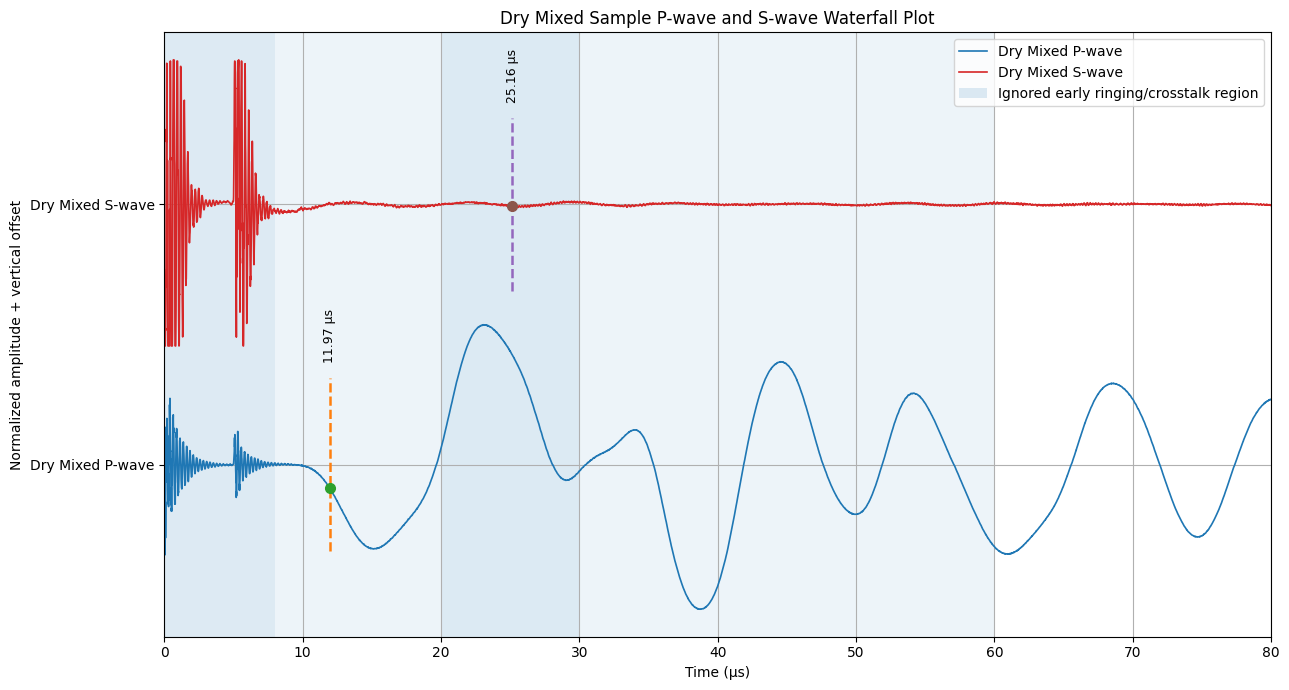


Saved files:
dry_mixed_p_s_waterfall_arrivals.png
dry_mixed_p_s_arrival_summary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. FILES FOR DRY MIXED SAMPLE
# ============================================================

DATA_FILES = [
    {
        "file": "DryMixedSSSamplePwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_135904.csv",
        "label": "Dry Mixed P-wave",
        "wave_type": "P-wave",
        "search_start_us": 8.0,
        "search_end_us": 30.0,
        "manual_pick_us": None
    },
    {
        "file": "DryMixedSSSampleSwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_140237.csv",
        "label": "Dry Mixed S-wave",
        "wave_type": "S-wave",
        "search_start_us": 20.0,
        "search_end_us": 60.0,
        "manual_pick_us": None
    }
]

# ============================================================
# 2. PLOT SETTINGS
# ============================================================

PLOT_START_US = 0.0
PLOT_END_US = 80.0
EARLY_RINGING_END_US = 8.0

VERTICAL_SPACING = 1.8

# ============================================================
# 3. OPTIONAL MANUAL PICKS
# ============================================================

# After you plot once, if the automatic pick is too early or too late,
# replace None with your visually confirmed time.
#
# Example:
# DATA_FILES[0]["manual_pick_us"] = 12.5   # P-wave
# DATA_FILES[1]["manual_pick_us"] = 35.7   # S-wave

# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def moving_average(x, window_points):
    window_points = int(window_points)

    if window_points < 3:
        window_points = 3

    if window_points % 2 == 0:
        window_points += 1

    kernel = np.ones(window_points) / window_points
    return np.convolve(x, kernel, mode="same")


def robust_noise_level(x):
    """
    Uses median absolute deviation.
    More stable than ordinary standard deviation when spikes are present.
    """

    median = np.median(x)
    mad = np.median(np.abs(x - median))

    # Convert MAD to equivalent standard deviation
    robust_std = 1.4826 * mad

    return median, robust_std


def pick_arrival(time_us, voltage_corrected, search_start_us, search_end_us):
    """
    Careful first-arrival picker:
    - only searches inside the selected window
    - avoids the early ringing/crosstalk region
    - looks for a sustained rise above background
    """

    dt_us = np.median(np.diff(time_us))

    # Smooth absolute amplitude to create an envelope
    smoothing_window_us = 0.40
    smoothing_points = smoothing_window_us / dt_us
    envelope = moving_average(np.abs(voltage_corrected), smoothing_points)

    # Search window
    search_mask = (
        (time_us >= search_start_us) &
        (time_us <= search_end_us)
    )

    search_indices = np.where(search_mask)[0]

    if len(search_indices) == 0:
        return None, None, envelope, None

    # Background/noise window immediately before the search window
    reference_mask = (
        (time_us >= max(0, search_start_us - 8.0)) &
        (time_us < search_start_us)
    )

    if np.sum(reference_mask) < 20:
        reference_mask = time_us < 0

    if np.sum(reference_mask) < 20:
        reference_mask = np.arange(0, min(500, len(time_us)))

    reference_envelope = envelope[reference_mask]

    noise_median, noise_std = robust_noise_level(reference_envelope)

    # Threshold for arrival detection
    threshold = noise_median + 4.0 * noise_std

    # Require signal to stay above threshold briefly
    min_duration_us = 0.50
    min_points = int(min_duration_us / dt_us)

    if min_points < 3:
        min_points = 3

    arrival_index = None

    for i in search_indices:

        # Make sure enough points remain
        if i + min_points >= len(envelope):
            continue

        # Crossing from below to above threshold
        crossed_threshold = envelope[i] > threshold

        if not crossed_threshold:
            continue

        # Sustained signal condition
        sustained = np.mean(envelope[i:i + min_points] > threshold) >= 0.70

        if sustained:
            arrival_index = i
            break

    # Fallback: choose strongest positive envelope rise inside search window
    if arrival_index is None:
        window_envelope = envelope[search_indices]
        gradient = np.gradient(window_envelope)
        arrival_index = search_indices[np.argmax(gradient)]

    arrival_time_us = time_us[arrival_index]

    return arrival_index, arrival_time_us, envelope, threshold


# ============================================================
# 5. READ DATA AND PICK ARRIVALS
# ============================================================

records = []
summary = []

for item in DATA_FILES:

    df = pd.read_csv(item["file"])
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    # Baseline correction using pre-trigger region
    pretrigger_mask = time_us < 0

    if np.sum(pretrigger_mask) > 20:
        baseline = np.median(voltage[pretrigger_mask])
    else:
        baseline = np.median(voltage[:500])

    voltage_corrected = voltage - baseline

    arrival_index, arrival_time_us, envelope, threshold = pick_arrival(
        time_us=time_us,
        voltage_corrected=voltage_corrected,
        search_start_us=item["search_start_us"],
        search_end_us=item["search_end_us"]
    )

    pick_type = "Automatic window pick"

    # Manual pick override
    if item["manual_pick_us"] is not None:
        arrival_time_us = item["manual_pick_us"]
        arrival_index = np.argmin(np.abs(time_us - arrival_time_us))
        pick_type = "Manual pick"

    records.append({
        "label": item["label"],
        "wave_type": item["wave_type"],
        "file": item["file"],
        "time_us": time_us,
        "voltage_corrected": voltage_corrected,
        "envelope": envelope,
        "arrival_index": arrival_index,
        "arrival_time_us": arrival_time_us,
        "search_start_us": item["search_start_us"],
        "search_end_us": item["search_end_us"],
        "pick_type": pick_type
    })

    summary.append({
        "Label": item["label"],
        "Wave_Type": item["wave_type"],
        "First_Arrival_Time_us": arrival_time_us,
        "First_Arrival_Index": arrival_index,
        "Pick_Type": pick_type,
        "Search_Start_us": item["search_start_us"],
        "Search_End_us": item["search_end_us"]
    })

summary_df = pd.DataFrame(summary)

print("\nDry mixed sample first-arrival summary:")
print(summary_df)

summary_df.to_csv("dry_mixed_p_s_arrival_summary.csv", index=False)

# ============================================================
# 6. WATERFALL PLOT
# ============================================================

plt.figure(figsize=(13, 7))

yticks = []
yticklabels = []

for i, rec in enumerate(records):

    time_us = rec["time_us"]
    voltage_corrected = rec["voltage_corrected"]

    plot_mask = (
        (time_us >= PLOT_START_US) &
        (time_us <= PLOT_END_US)
    )

    max_amp = np.max(np.abs(voltage_corrected[plot_mask]))

    if max_amp == 0:
        voltage_norm = voltage_corrected
    else:
        voltage_norm = voltage_corrected / max_amp

    offset = i * VERTICAL_SPACING

    plt.plot(
        time_us[plot_mask],
        voltage_norm[plot_mask] + offset,
        linewidth=1.2,
        label=rec["label"]
    )

    yticks.append(offset)
    yticklabels.append(rec["label"])

    # Mark search window for each trace
    plt.axvspan(
        rec["search_start_us"],
        rec["search_end_us"],
        alpha=0.08
    )

    # Mark arrival
    if rec["arrival_time_us"] is not None:

        arrival_time = rec["arrival_time_us"]
        arrival_index = rec["arrival_index"]

        plt.plot(
            [arrival_time, arrival_time],
            [offset - 0.60, offset + 0.60],
            linestyle="--",
            linewidth=1.8
        )

        plt.plot(
            arrival_time,
            voltage_norm[arrival_index] + offset,
            marker="o",
            markersize=7
        )

        plt.text(
            arrival_time,
            offset + 0.70,
            f"{arrival_time:.2f} µs",
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=9
        )

# Shade early ringing/crosstalk area
plt.axvspan(
    PLOT_START_US,
    EARLY_RINGING_END_US,
    alpha=0.15,
    label="Ignored early ringing/crosstalk region"
)

plt.xlabel("Time (µs)")
plt.ylabel("Normalized amplitude + vertical offset")
plt.title("Dry Mixed Sample P-wave and S-wave Waterfall Plot")
plt.xlim(PLOT_START_US, PLOT_END_US)
plt.yticks(yticks, yticklabels)
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig("dry_mixed_p_s_waterfall_arrivals.png", dpi=300)
plt.show()

print("\nSaved files:")
print("dry_mixed_p_s_waterfall_arrivals.png")
print("dry_mixed_p_s_arrival_summary.csv")

Columns in file:
Index(['Label', 'Wave_Type', 'First_Arrival_Time_us', 'First_Arrival_Index',
       'Pick_Type', 'Search_Start_us', 'Search_End_us'],
      dtype='object')

Arrival-time table:
              Label Wave_Type  First_Arrival_Time_us  First_Arrival_Index  \
0  Dry Mixed P-wave    P-wave                  11.97                 1607   
1  Dry Mixed S-wave    S-wave                  25.16                 2926   

               Pick_Type  Search_Start_us  Search_End_us  
0  Automatic window pick              8.0           30.0  
1  Automatic window pick             20.0           60.0  

Ultrasonic velocity results:
              Label Wave_Type  First_Arrival_Time_us  \
0  Dry Mixed P-wave    P-wave                  11.97   
1  Dry Mixed S-wave    S-wave                  25.16   

   Velocity_m_per_s_rounded  Velocity_km_per_s_rounded              Pick_Type  
0                    1545.5                      1.546  Automatic window pick  
1                     735.3           

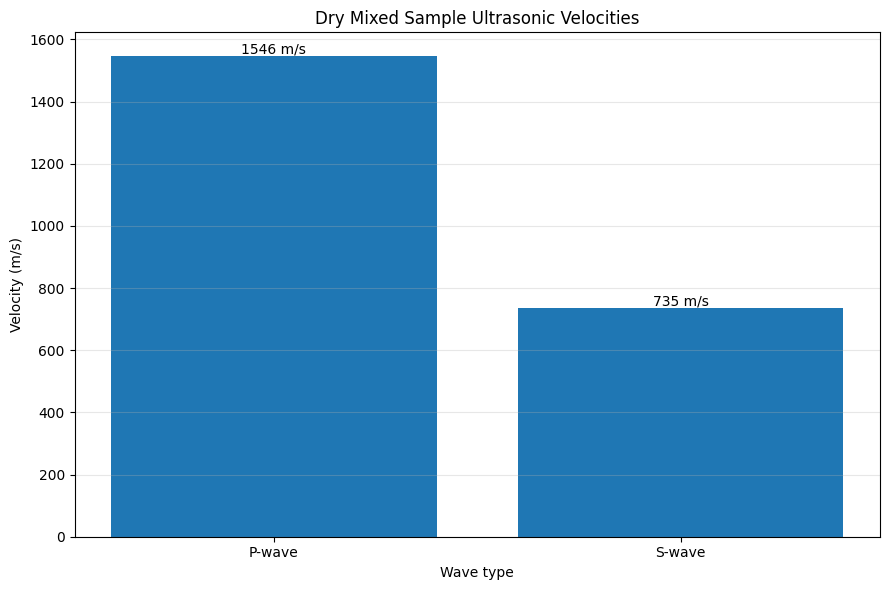


Saved:
dry_mixed_p_s_velocity_bar_plot.png


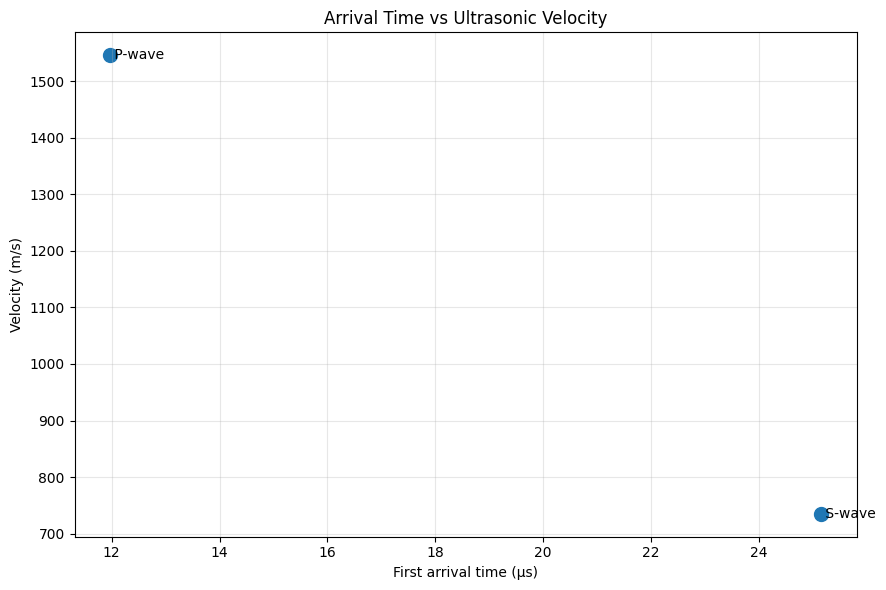


Saved:
dry_mixed_arrival_time_vs_velocity.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. INPUT FILE FROM YOUR ARRIVAL-PICKING CODE
# ============================================================

arrival_file = "dry_mixed_p_s_arrival_summary.csv"

df = pd.read_csv(arrival_file)
df.columns = df.columns.str.strip()

print("Columns in file:")
print(df.columns)

print("\nArrival-time table:")
print(df)

# ============================================================
# 2. SAMPLE LENGTH
# ============================================================

sample_length_mm = 18.5
sample_length_m = sample_length_mm / 1000

# ============================================================
# 3. OPTIONAL: MANUAL ARRIVAL-TIME CORRECTIONS
# ============================================================

# Use this only if you visually corrected the arrival times.
# Leave values as None if you want to use the arrival times already in the CSV.
#
# Example:
# MANUAL_ARRIVAL_TIMES_US = {
#     "P-wave": 12.50,
#     "S-wave": 35.70
# }

MANUAL_ARRIVAL_TIMES_US = {
    "P-wave": None,
    "S-wave": None
}

# Apply manual corrections if provided
for wave_type, manual_time in MANUAL_ARRIVAL_TIMES_US.items():
    if manual_time is not None:
        df.loc[df["Wave_Type"] == wave_type, "First_Arrival_Time_us"] = manual_time
        df.loc[df["Wave_Type"] == wave_type, "Pick_Type"] = "Manual velocity calculation pick"

# ============================================================
# 4. CALCULATE VELOCITY
# ============================================================

df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["Velocity_m_per_s"] = sample_length_m / df["First_Arrival_Time_s"]

df["Velocity_km_per_s"] = df["Velocity_m_per_s"] / 1000

# Round for cleaner display
df["Velocity_m_per_s_rounded"] = df["Velocity_m_per_s"].round(1)
df["Velocity_km_per_s_rounded"] = df["Velocity_km_per_s"].round(3)

print("\nUltrasonic velocity results:")
print(df[[
    "Label",
    "Wave_Type",
    "First_Arrival_Time_us",
    "Velocity_m_per_s_rounded",
    "Velocity_km_per_s_rounded",
    "Pick_Type"
]])

# Save velocity summary
df.to_csv("dry_mixed_p_s_velocity_summary.csv", index=False)

print("\nSaved:")
print("dry_mixed_p_s_velocity_summary.csv")

# ============================================================
# 5. BAR PLOT OF P-WAVE AND S-WAVE VELOCITIES
# ============================================================

plt.figure(figsize=(9, 6))

x_labels = df["Wave_Type"].astype(str)
velocities = df["Velocity_m_per_s"]

bars = plt.bar(x_labels, velocities)

# Add value labels on top of bars
for bar, velocity in zip(bars, velocities):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{velocity:.0f} m/s",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.xlabel("Wave type")
plt.ylabel("Velocity (m/s)")
plt.title("Dry Mixed Sample Ultrasonic Velocities")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("dry_mixed_p_s_velocity_bar_plot.png", dpi=300)
plt.show()

print("\nSaved:")
print("dry_mixed_p_s_velocity_bar_plot.png")

# ============================================================
# 6. OPTIONAL: PLOT ARRIVAL TIME VS VELOCITY
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    df["First_Arrival_Time_us"],
    df["Velocity_m_per_s"],
    s=100
)

for i, row in df.iterrows():
    plt.text(
        row["First_Arrival_Time_us"],
        row["Velocity_m_per_s"],
        f" {row['Wave_Type']}",
        fontsize=10,
        va="center"
    )

plt.xlabel("First arrival time (µs)")
plt.ylabel("Velocity (m/s)")
plt.title("Arrival Time vs Ultrasonic Velocity")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("dry_mixed_arrival_time_vs_velocity.png", dpi=300)
plt.show()

print("\nSaved:")
print("dry_mixed_arrival_time_vs_velocity.png")

In [ ]:
# P-WAVES OF THE SATURATED MIXED SAMPLE ACROSS 13 DAYS #

In [4]:
from google.colab import files

uploaded = files.upload()

Saving SatMixedSSSampleDay1Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_145936.csv to SatMixedSSSampleDay1Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_145936.csv
Saving SatMixedSSSampleDay4Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260803_123358.csv to SatMixedSSSampleDay4Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260803_123358.csv
Saving SatMixedSSSampleDay5Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260804_134719.csv to SatMixedSSSampleDay5Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260804_134719.csv
Saving SatMixedSSSampleDay6Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260805_132757.csv to SatMixedSSSampleDay6Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260805_132757.csv
Saving SatMixedSSSampleDay7Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260806_164317.csv to SatMixedSSSampleDay7Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260806_164317.csv
Saving SatMixedSSSampleDay8Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260807_154937.csv to SatMixedSSSampleDay8Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260807_154937.csv
Savi


Saturated mixed sample P-wave arrival summary:
   Day               Sample_ID Wave_Type  Frequency_MHz  \
0    1   SatMixedSSSamplePwave    P-wave            0.1   
1    4  Sat2MixedSSSamplePwave    P-wave            0.1   
2    5  SatMixedSSSample3Pwave    P-wave            0.1   
3    6  SatMixedSSSample4Pwave    P-wave            0.1   
4    7  SatMixedSSSample5Pwave    P-wave            0.1   
5    8  SatMixedSSSample6Pwave    P-wave            0.1   
6   11  SatMixedSSSample7Pwave    P-wave            0.1   
7   12  SatMixedSSSample8Pwave    P-wave            0.1   
8   13  SatMixedSSSample9Pwave    P-wave            0.1   

   First_Arrival_Time_us  First_Arrival_Index              Pick_Type  \
0                  12.20                 1630            Manual pick   
1                  12.42                 1652            Manual pick   
2                  12.63                 1673  Automatic window pick   
3                  12.66                 1676            Manual pick   
4

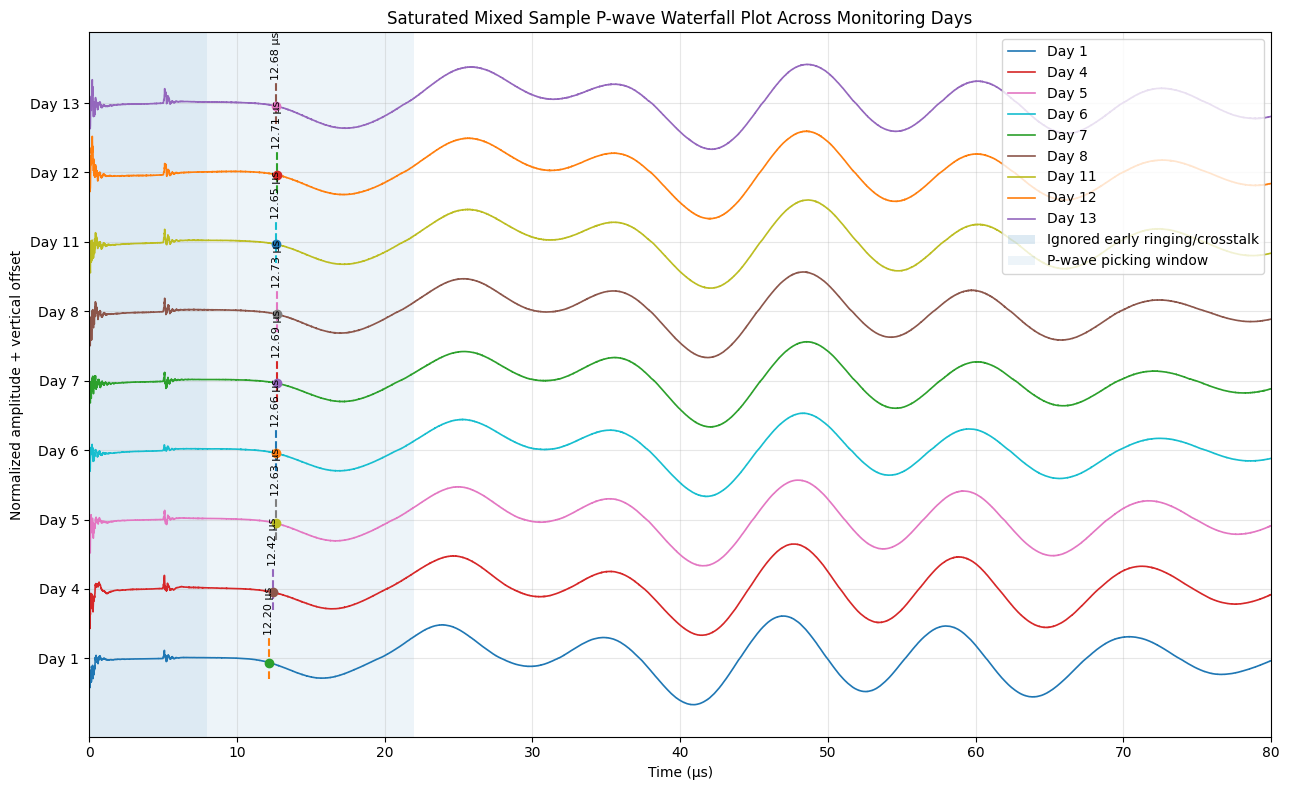


Saved:
sat_mixed_pwave_waterfall_previous_style.png


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. SATURATED MIXED SAMPLE P-WAVE FILES
# ============================================================

DATA_FILES = [
    {"day": 1,  "file": "SatMixedSSSampleDay1Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260731_145936.csv"},
    {"day": 4,  "file": "SatMixedSSSampleDay4Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260803_123358.csv"},
    {"day": 5,  "file": "SatMixedSSSampleDay5Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260804_134719.csv"},
    {"day": 6,  "file": "SatMixedSSSampleDay6Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260805_132757.csv"},
    {"day": 7,  "file": "SatMixedSSSampleDay7Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260806_164317.csv"},
    {"day": 8,  "file": "SatMixedSSSampleDay8Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260807_154937.csv"},
    {"day": 11, "file": "SatMixedSSSampleDay11Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260810_170552.csv"},
    {"day": 12, "file": "SatMixedSSSampleDay12Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260811_154139.csv"},
    {"day": 13, "file": "SatMixedSSSampleDay13Pwave_Synthetic_PowderCore_0.1MHz_CH1_20260812_160617.csv"}
]

# ============================================================
# 2. SETTINGS
# ============================================================

PLOT_START_US = 0.0
PLOT_END_US = 80.0

P_SEARCH_START_US = 8.0
P_SEARCH_END_US = 22.0

EARLY_RINGING_END_US = 8.0

VERTICAL_SPACING = 1.5

# Optional manual corrections
MANUAL_PICKS_US = {
    1: 12.20,
    4: 12.42,
    5: None,
    6: 12.66,
    7: 12.69,
    8: 12.73,
    11: None,
    12: 12.71,
    13: 12.68
}

# ============================================================
# 3. FUNCTIONS
# ============================================================

def moving_average(x, window_points):
    window_points = int(window_points)

    if window_points < 3:
        window_points = 3

    if window_points % 2 == 0:
        window_points += 1

    kernel = np.ones(window_points) / window_points
    return np.convolve(x, kernel, mode="same")


def robust_noise_level(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    robust_std = 1.4826 * mad
    return median, robust_std


def pick_pwave_arrival(time_us, voltage_corrected):
    dt_us = np.median(np.diff(time_us))

    envelope = moving_average(
        np.abs(voltage_corrected),
        0.25 / dt_us
    )

    search_mask = (
        (time_us >= P_SEARCH_START_US) &
        (time_us <= P_SEARCH_END_US)
    )

    search_indices = np.where(search_mask)[0]

    if len(search_indices) == 0:
        return None, None

    reference_mask = (
        (time_us >= max(0.0, P_SEARCH_START_US - 5.0)) &
        (time_us < P_SEARCH_START_US)
    )

    if np.sum(reference_mask) < 20:
        reference_mask = time_us < 0

    if np.sum(reference_mask) < 20:
        reference_mask = np.arange(0, min(500, len(time_us)))

    reference_envelope = envelope[reference_mask]

    noise_median, noise_std = robust_noise_level(reference_envelope)

    threshold = noise_median + 4.0 * noise_std

    min_duration_us = 0.25
    min_points = int(min_duration_us / dt_us)

    if min_points < 3:
        min_points = 3

    arrival_index = None

    for i in search_indices:

        if i + min_points >= len(envelope):
            continue

        if envelope[i] <= threshold:
            continue

        sustained = np.mean(envelope[i:i + min_points] > threshold) >= 0.70

        if sustained:
            arrival_index = i
            break

    if arrival_index is None:
        window_envelope = envelope[search_indices]
        gradient = np.gradient(window_envelope)
        arrival_index = search_indices[np.argmax(gradient)]

    arrival_time_us = time_us[arrival_index]

    return arrival_index, arrival_time_us


# ============================================================
# 4. READ DATA AND PICK ARRIVALS
# ============================================================

records = []
summary = []

for item in DATA_FILES:

    day = item["day"]
    file = item["file"]

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    sample_id = str(df["Sample_ID"].iloc[0])
    frequency_mhz = df["Transducer_Frequency_MHz"].iloc[0]

    # Baseline correction
    pretrigger_mask = time_us < 0

    if np.sum(pretrigger_mask) > 20:
        baseline = np.median(voltage[pretrigger_mask])
    else:
        baseline = np.median(voltage[:500])

    voltage_corrected = voltage - baseline

    arrival_index, arrival_time_us = pick_pwave_arrival(
        time_us,
        voltage_corrected
    )

    pick_type = "Automatic window pick"

    if MANUAL_PICKS_US[day] is not None:
        arrival_time_us = MANUAL_PICKS_US[day]
        arrival_index = np.argmin(np.abs(time_us - arrival_time_us))
        pick_type = "Manual pick"

    records.append({
        "day": day,
        "label": f"Day {day}",
        "file": file,
        "sample_id": sample_id,
        "frequency_mhz": frequency_mhz,
        "time_us": time_us,
        "voltage_corrected": voltage_corrected,
        "arrival_index": arrival_index,
        "arrival_time_us": arrival_time_us,
        "pick_type": pick_type
    })

    summary.append({
        "Day": day,
        "Sample_ID": sample_id,
        "Wave_Type": "P-wave",
        "Frequency_MHz": frequency_mhz,
        "First_Arrival_Time_us": arrival_time_us,
        "First_Arrival_Index": arrival_index,
        "Pick_Type": pick_type,
        "Search_Start_us": P_SEARCH_START_US,
        "Search_End_us": P_SEARCH_END_US
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("Day").reset_index(drop=True)

print("\nSaturated mixed sample P-wave arrival summary:")
print(summary_df)

summary_df.to_csv("sat_mixed_pwave_arrival_summary.csv", index=False)

print("\nSaved:")
print("sat_mixed_pwave_arrival_summary.csv")

# ============================================================
# 5. PREVIOUS-STYLE WATERFALL PLOT
# ============================================================

plt.figure(figsize=(13, 8))

yticks = []
yticklabels = []

for i, rec in enumerate(records):

    time_us = rec["time_us"]
    voltage_corrected = rec["voltage_corrected"]

    plot_mask = (
        (time_us >= PLOT_START_US) &
        (time_us <= PLOT_END_US)
    )

    # Previous-style normalization:
    # Normalize each trace using its own full plotted waveform range.
    max_amp = np.max(np.abs(voltage_corrected[plot_mask]))

    if max_amp == 0:
        voltage_norm = voltage_corrected
    else:
        voltage_norm = voltage_corrected / max_amp

    offset = i * VERTICAL_SPACING

    plt.plot(
        time_us[plot_mask],
        voltage_norm[plot_mask] + offset,
        linewidth=1.2,
        label=rec["label"]
    )

    yticks.append(offset)
    yticklabels.append(rec["label"])

    arrival_time = rec["arrival_time_us"]
    arrival_index = rec["arrival_index"]

    if arrival_time is not None:

        plt.plot(
            [arrival_time, arrival_time],
            [offset - 0.45, offset + 0.45],
            linestyle="--",
            linewidth=1.5
        )

        plt.plot(
            arrival_time,
            voltage_norm[arrival_index] + offset,
            marker="o",
            markersize=6
        )

        plt.text(
            arrival_time,
            offset + 0.50,
            f"{arrival_time:.2f} µs",
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=8
        )

# Shade early region
plt.axvspan(
    PLOT_START_US,
    EARLY_RINGING_END_US,
    alpha=0.15,
    label="Ignored early ringing/crosstalk"
)

# Shade picking window
plt.axvspan(
    P_SEARCH_START_US,
    P_SEARCH_END_US,
    alpha=0.08,
    label="P-wave picking window"
)

plt.xlabel("Time (µs)")
plt.ylabel("Normalized amplitude + vertical offset")
plt.title("Saturated Mixed Sample P-wave Waterfall Plot Across Monitoring Days")
plt.xlim(PLOT_START_US, PLOT_END_US)
plt.yticks(yticks, yticklabels)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()

plt.savefig("sat_mixed_pwave_waterfall_previous_style.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_pwave_waterfall_previous_style.png")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving sat_mixed_pwave_arrival_summary.csv to sat_mixed_pwave_arrival_summary.csv



P-wave velocity summary:
   Day  First_Arrival_Time_us  P_wave_velocity_m_per_s  \
0    1                  12.20              1516.393443   
1    4                  12.42              1489.533011   
2    5                  12.63              1464.766429   
3    6                  12.66              1461.295419   
4    7                  12.69              1457.840820   
5    8                  12.73              1453.260016   
6   11                  12.65              1462.450593   
7   12                  12.71              1455.546814   
8   13                  12.68              1458.990536   

   P_wave_velocity_km_per_s    Pick_Type  
0                  1.516393  Manual pick  
1                  1.489533  Manual pick  
2                  1.464766  Manual pick  
3                  1.461295  Manual pick  
4                  1.457841  Manual pick  
5                  1.453260  Manual pick  
6                  1.462451  Manual pick  
7                  1.455547  Manual pick  
8     

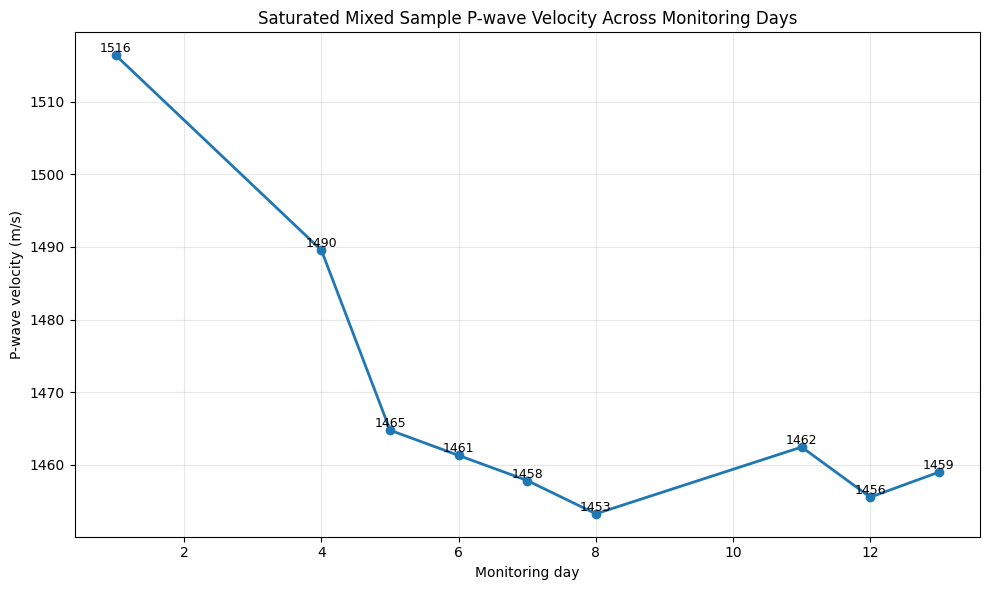


Saved:
sat_mixed_pwave_velocity_line_plot.png


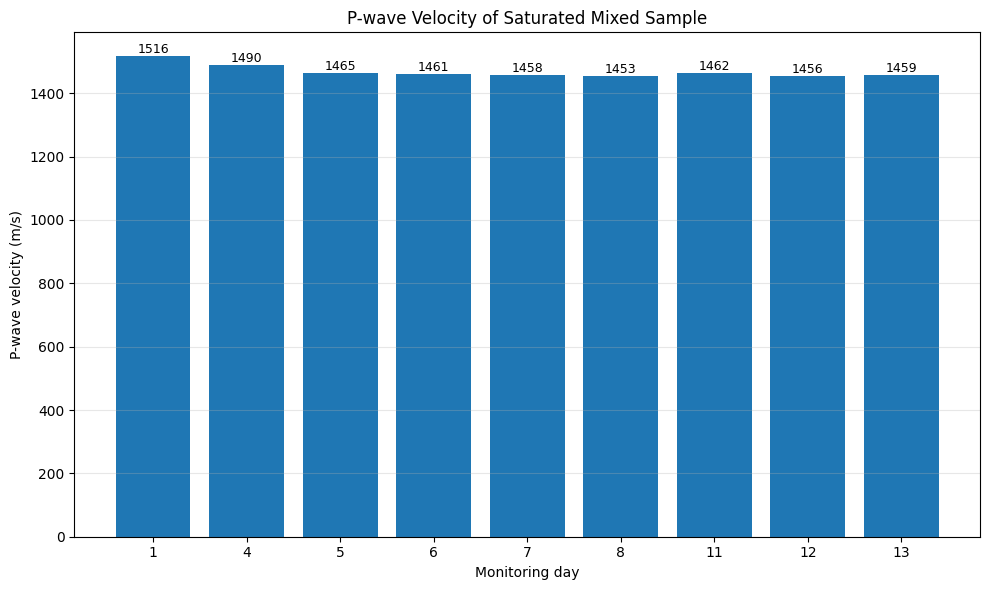


Saved:
sat_mixed_pwave_velocity_bar_chart.png


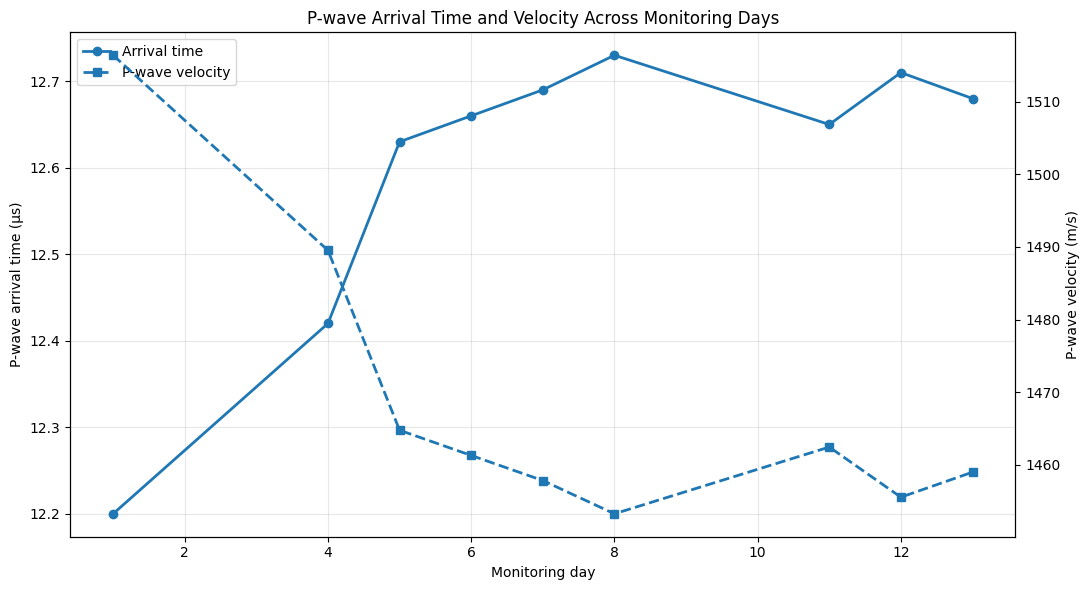


Saved:
sat_mixed_pwave_arrival_time_velocity_combined.png

Day 1 vs Day 13 P-wave velocity comparison:
Day 1 velocity:  1516 m/s
Day 13 velocity: 1459 m/s
Velocity change: -57 m/s
Percent change:  -3.79%


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD SATURATED MIXED SAMPLE P-WAVE ARRIVAL SUMMARY
# ============================================================

df = pd.read_csv("sat_mixed_pwave_arrival_summary.csv")
df.columns = df.columns.str.strip()

# ============================================================
# 2. OPTIONAL MANUAL CORRECTIONS
# ============================================================

# If you manually corrected any arrival time, put it here.
# Example:
# 12: 12.65

MANUAL_PICKS_US = {
    1: 12.20,
    4: 12.42,
    5: 12.63,
    6: 12.66,
    7: 12.69,
    8: 12.73,
    11: 12.65,
    12: 12.71,
    13: 12.68
}

for day, manual_time in MANUAL_PICKS_US.items():
    if manual_time is not None:
        df.loc[df["Day"] == day, "First_Arrival_Time_us"] = manual_time
        df.loc[df["Day"] == day, "Pick_Type"] = "Manual pick"

# ============================================================
# 3. CALCULATE P-WAVE VELOCITY
# ============================================================

# Sample length = 18.5 mm
sample_length_mm = 18.5
sample_length_m = sample_length_mm / 1000

df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["P_wave_velocity_m_per_s"] = (
    sample_length_m / df["First_Arrival_Time_s"]
)

df["P_wave_velocity_km_per_s"] = (
    df["P_wave_velocity_m_per_s"] / 1000
)

df = df.sort_values("Day").reset_index(drop=True)

print("\nP-wave velocity summary:")
print(df[[
    "Day",
    "First_Arrival_Time_us",
    "P_wave_velocity_m_per_s",
    "P_wave_velocity_km_per_s",
    "Pick_Type"
]])

df.to_csv("sat_mixed_pwave_velocity_summary.csv", index=False)

print("\nSaved:")
print("sat_mixed_pwave_velocity_summary.csv")

# ============================================================
# 4. LINE PLOT: P-WAVE VELOCITY OVER 13 DAYS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Day"],
    df["P_wave_velocity_m_per_s"],
    marker="o",
    linewidth=2
)

for _, row in df.iterrows():
    plt.text(
        row["Day"],
        row["P_wave_velocity_m_per_s"],
        f"{row['P_wave_velocity_m_per_s']:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("P-wave velocity (m/s)")
plt.title("Saturated Mixed Sample P-wave Velocity Across Monitoring Days")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_pwave_velocity_line_plot.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_pwave_velocity_line_plot.png")

# ============================================================
# 5. BAR CHART: P-WAVE VELOCITY BY DAY
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    df["Day"].astype(str),
    df["P_wave_velocity_m_per_s"]
)

for _, row in df.iterrows():
    plt.text(
        str(int(row["Day"])),
        row["P_wave_velocity_m_per_s"],
        f"{row['P_wave_velocity_m_per_s']:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("P-wave velocity (m/s)")
plt.title("P-wave Velocity of Saturated Mixed Sample")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_pwave_velocity_bar_chart.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_pwave_velocity_bar_chart.png")

# ============================================================
# 6. COMBINED ARRIVAL TIME AND VELOCITY PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(
    df["Day"],
    df["First_Arrival_Time_us"],
    marker="o",
    linewidth=2,
    label="Arrival time"
)

ax1.set_xlabel("Monitoring day")
ax1.set_ylabel("P-wave arrival time (µs)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    df["Day"],
    df["P_wave_velocity_m_per_s"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="P-wave velocity"
)

ax2.set_ylabel("P-wave velocity (m/s)")

plt.title("P-wave Arrival Time and Velocity Across Monitoring Days")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.tight_layout()

plt.savefig("sat_mixed_pwave_arrival_time_velocity_combined.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_pwave_arrival_time_velocity_combined.png")

# ============================================================
# 7. DAY 1 VS DAY 13 COMPARISON
# ============================================================

day1 = df[df["Day"] == 1].iloc[0]
day13 = df[df["Day"] == 13].iloc[0]

velocity_change = (
    day13["P_wave_velocity_m_per_s"]
    - day1["P_wave_velocity_m_per_s"]
)

velocity_percent_change = (
    velocity_change / day1["P_wave_velocity_m_per_s"]
) * 100

print("\nDay 1 vs Day 13 P-wave velocity comparison:")
print(f"Day 1 velocity:  {day1['P_wave_velocity_m_per_s']:.0f} m/s")
print(f"Day 13 velocity: {day13['P_wave_velocity_m_per_s']:.0f} m/s")
print(f"Velocity change: {velocity_change:.0f} m/s")
print(f"Percent change:  {velocity_percent_change:.2f}%")

Original arrival-time table:
   Day               Sample_ID Wave_Type  Frequency_MHz  \
0    1   SatMixedSSSamplePwave    P-wave            0.1   
1    4  Sat2MixedSSSamplePwave    P-wave            0.1   
2    5  SatMixedSSSample3Pwave    P-wave            0.1   
3    6  SatMixedSSSample4Pwave    P-wave            0.1   
4    7  SatMixedSSSample5Pwave    P-wave            0.1   
5    8  SatMixedSSSample6Pwave    P-wave            0.1   
6   11  SatMixedSSSample7Pwave    P-wave            0.1   
7   12  SatMixedSSSample8Pwave    P-wave            0.1   
8   13  SatMixedSSSample9Pwave    P-wave            0.1   

   First_Arrival_Time_us  First_Arrival_Index              Pick_Type  \
0                  12.20                 1630            Manual pick   
1                  12.42                 1652            Manual pick   
2                  12.63                 1673  Automatic window pick   
3                  12.66                 1676            Manual pick   
4                  1

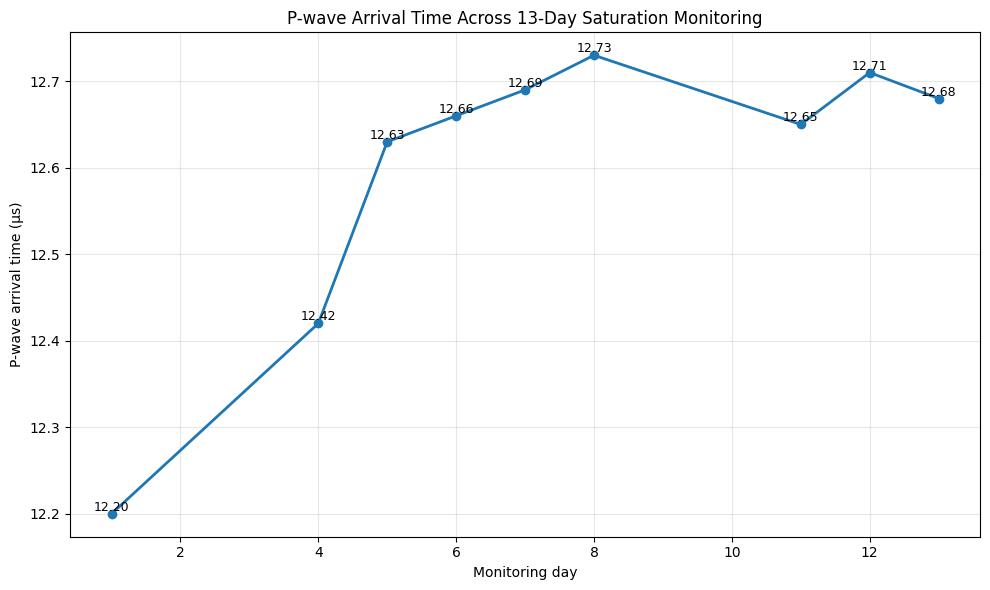

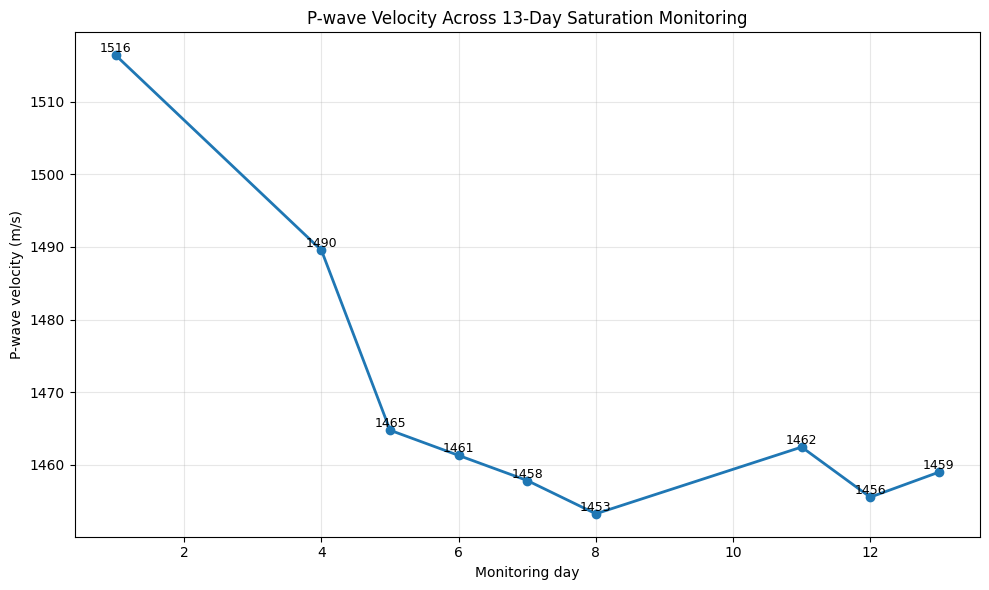

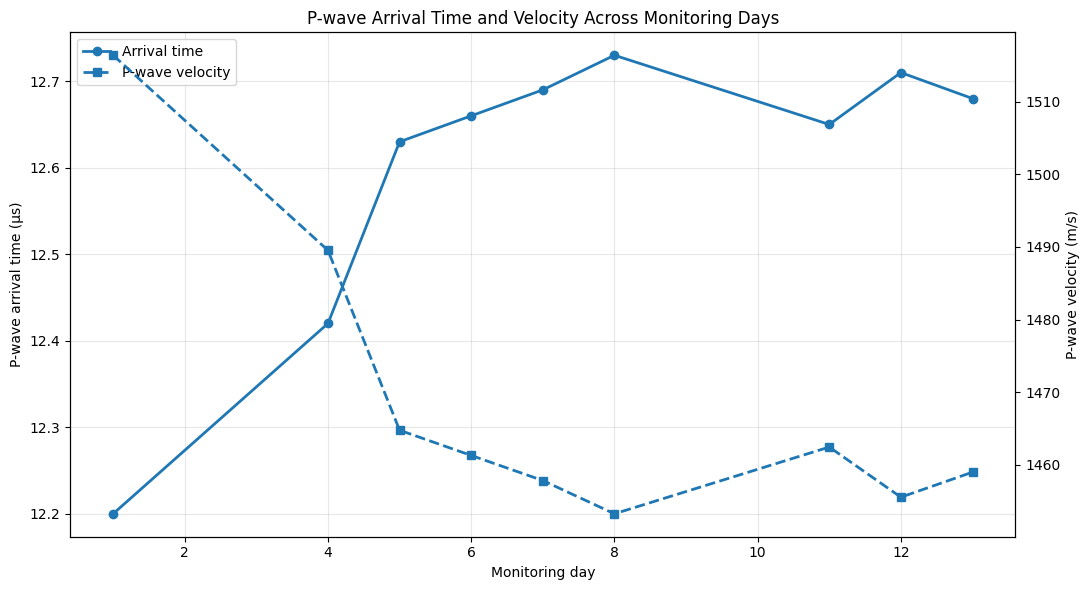


Day 1 vs Day 13 comparison:
Day 1 arrival time:  12.20 µs
Day 13 arrival time: 12.68 µs
Arrival-time change: 0.48 µs
Arrival-time percent change: 3.93%

Day 1 velocity:  1516 m/s
Day 13 velocity: 1459 m/s
Velocity change: -57 m/s
Velocity percent change: -3.79%


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD ARRIVAL SUMMARY CSV
# ============================================================

df = pd.read_csv("sat_mixed_pwave_arrival_summary.csv")
df.columns = df.columns.str.strip()

print("Original arrival-time table:")
print(df)

# ============================================================
# 2. OPTIONAL MANUAL ARRIVAL-TIME CORRECTIONS
# ============================================================

# If you want to manually correct any day, enter the value here.
# Example: if Day 12 should be 12.65 us instead of 14.13 us, write:
# 12: 12.65

MANUAL_PICKS_US = {
    1: 12.20,
    4: 12.42,
    5: 12.63,
    6: 12.66,
    7: 12.69,
    8: 12.73,
    11: 12.65,
    12: 12.71,   # Change this if you want to correct Day 12
    13: 12.68
}

# Apply manual corrections
for day, manual_time in MANUAL_PICKS_US.items():
    if manual_time is not None:
        df.loc[df["Day"] == day, "First_Arrival_Time_us"] = manual_time
        df.loc[df["Day"] == day, "Pick_Type"] = "Manual pick"

# ============================================================
# 3. CALCULATE ULTRASONIC VELOCITY
# ============================================================

sample_length_mm = 18.5
sample_length_m = sample_length_mm / 1000

df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6
df["P_wave_velocity_m_per_s"] = sample_length_m / df["First_Arrival_Time_s"]
df["P_wave_velocity_km_per_s"] = df["P_wave_velocity_m_per_s"] / 1000

# Sort by monitoring day
df = df.sort_values("Day").reset_index(drop=True)

print("\nArrival time and velocity summary:")
print(df[[
    "Day",
    "First_Arrival_Time_us",
    "P_wave_velocity_m_per_s",
    "P_wave_velocity_km_per_s",
    "Pick_Type"
]])

# Save updated results
df.to_csv("sat_mixed_pwave_velocity_summary.csv", index=False)

print("\nSaved:")
print("sat_mixed_pwave_velocity_summary.csv")

# ============================================================
# 4. LINE PLOT: ARRIVAL TIME ACROSS DAYS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Day"],
    df["First_Arrival_Time_us"],
    marker="o",
    linewidth=2
)

for _, row in df.iterrows():
    plt.text(
        row["Day"],
        row["First_Arrival_Time_us"],
        f"{row['First_Arrival_Time_us']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("P-wave arrival time (µs)")
plt.title("P-wave Arrival Time Across 13-Day Saturation Monitoring")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_pwave_arrival_time_line_plot.png", dpi=300)
plt.show()

# ============================================================
# 5. LINE PLOT: P-WAVE VELOCITY ACROSS DAYS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Day"],
    df["P_wave_velocity_m_per_s"],
    marker="o",
    linewidth=2
)

for _, row in df.iterrows():
    plt.text(
        row["Day"],
        row["P_wave_velocity_m_per_s"],
        f"{row['P_wave_velocity_m_per_s']:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("P-wave velocity (m/s)")
plt.title("P-wave Velocity Across 13-Day Saturation Monitoring")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_pwave_velocity_line_plot.png", dpi=300)
plt.show()

# ============================================================
# 6. COMBINED PLOT: ARRIVAL TIME AND VELOCITY
# ============================================================

fig, ax1 = plt.subplots(figsize=(11, 6))

# Arrival time on left y-axis
ax1.plot(
    df["Day"],
    df["First_Arrival_Time_us"],
    marker="o",
    linewidth=2,
    label="Arrival time"
)

ax1.set_xlabel("Monitoring day")
ax1.set_ylabel("P-wave arrival time (µs)")
ax1.grid(True, alpha=0.3)

# Velocity on right y-axis
ax2 = ax1.twinx()

ax2.plot(
    df["Day"],
    df["P_wave_velocity_m_per_s"],
    marker="s",
    linewidth=2,
    linestyle="--",
    label="P-wave velocity"
)

ax2.set_ylabel("P-wave velocity (m/s)")

plt.title("P-wave Arrival Time and Velocity Across Monitoring Days")

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.tight_layout()

plt.savefig("sat_mixed_pwave_arrival_time_and_velocity_combined.png", dpi=300)
plt.show()

# ============================================================
# 7. DAY 1 VS DAY 13 SUMMARY
# ============================================================

day1 = df[df["Day"] == 1].iloc[0]
day13 = df[df["Day"] == 13].iloc[0]

arrival_change = day13["First_Arrival_Time_us"] - day1["First_Arrival_Time_us"]
velocity_change = day13["P_wave_velocity_m_per_s"] - day1["P_wave_velocity_m_per_s"]

arrival_percent_change = (arrival_change / day1["First_Arrival_Time_us"]) * 100
velocity_percent_change = (velocity_change / day1["P_wave_velocity_m_per_s"]) * 100

print("\nDay 1 vs Day 13 comparison:")
print(f"Day 1 arrival time:  {day1['First_Arrival_Time_us']:.2f} µs")
print(f"Day 13 arrival time: {day13['First_Arrival_Time_us']:.2f} µs")
print(f"Arrival-time change: {arrival_change:.2f} µs")
print(f"Arrival-time percent change: {arrival_percent_change:.2f}%")

print(f"\nDay 1 velocity:  {day1['P_wave_velocity_m_per_s']:.0f} m/s")
print(f"Day 13 velocity: {day13['P_wave_velocity_m_per_s']:.0f} m/s")
print(f"Velocity change: {velocity_change:.0f} m/s")
print(f"Velocity percent change: {velocity_percent_change:.2f}%")

In [22]:
from google.colab import files

uploaded = files.upload()

Saving SatMixedSSSample1Swave_Synthetic_PowderCore_0.1MHz_CH1_20260731_150301.csv to SatMixedSSSample1Swave_Synthetic_PowderCore_0.1MHz_CH1_20260731_150301.csv
Saving SatMixedSSSample4Swave_Synthetic_PowderCore_0.1MHz_CH1_20260803_124014.csv to SatMixedSSSample4Swave_Synthetic_PowderCore_0.1MHz_CH1_20260803_124014.csv
Saving SatMixedSSSample5Swave_Synthetic_PowderCore_0.1MHz_CH1_20260804_135711.csv to SatMixedSSSample5Swave_Synthetic_PowderCore_0.1MHz_CH1_20260804_135711.csv
Saving SatMixedSSSample6Swave_Synthetic_PowderCore_0.1MHz_CH1_20260805_133058.csv to SatMixedSSSample6Swave_Synthetic_PowderCore_0.1MHz_CH1_20260805_133058.csv
Saving SatMixedSSSample7Swave_Synthetic_PowderCore_0.1MHz_CH1_20260806_165636.csv to SatMixedSSSample7Swave_Synthetic_PowderCore_0.1MHz_CH1_20260806_165636.csv
Saving SatMixedSSSample8Swave_Synthetic_PowderCore_0.1MHz_CH1_20260807_155119.csv to SatMixedSSSample8Swave_Synthetic_PowderCore_0.1MHz_CH1_20260807_155119.csv
Saving SatMixedSSSample11Swave_Synthetic


Saturated mixed sample S-wave arrival summary:
   Day               Sample_ID Wave_Type  Frequency_MHz  \
0    1   SatMixedSSSampleSwave    S-wave            0.1   
1    4  SatMixedSSSample2Swave    S-wave            0.1   
2    5  SatMixedSSSample3Swave    S-wave            0.1   
3    6  SatMixedSSSample4Swave    S-wave            0.1   
4    7  SatMixedSSSample5Swave    S-wave            0.1   
5    8  SatMixedSSSample6Swave    S-wave            0.1   
6   11  SatMixedSSSample7Swave    S-wave            0.1   
7   12  SatMixedSSSample8Swave    S-wave            0.1   
8   13  SatMixedSSSample9Swave    S-wave            0.1   

   First_Arrival_Time_us  First_Arrival_Index              Pick_Type  \
0                  33.50                 3760  Automatic window pick   
1                  33.42                 3752            Manual pick   
2                  34.70                 3880  Automatic window pick   
3                  34.61                 3871  Automatic window pick   
4

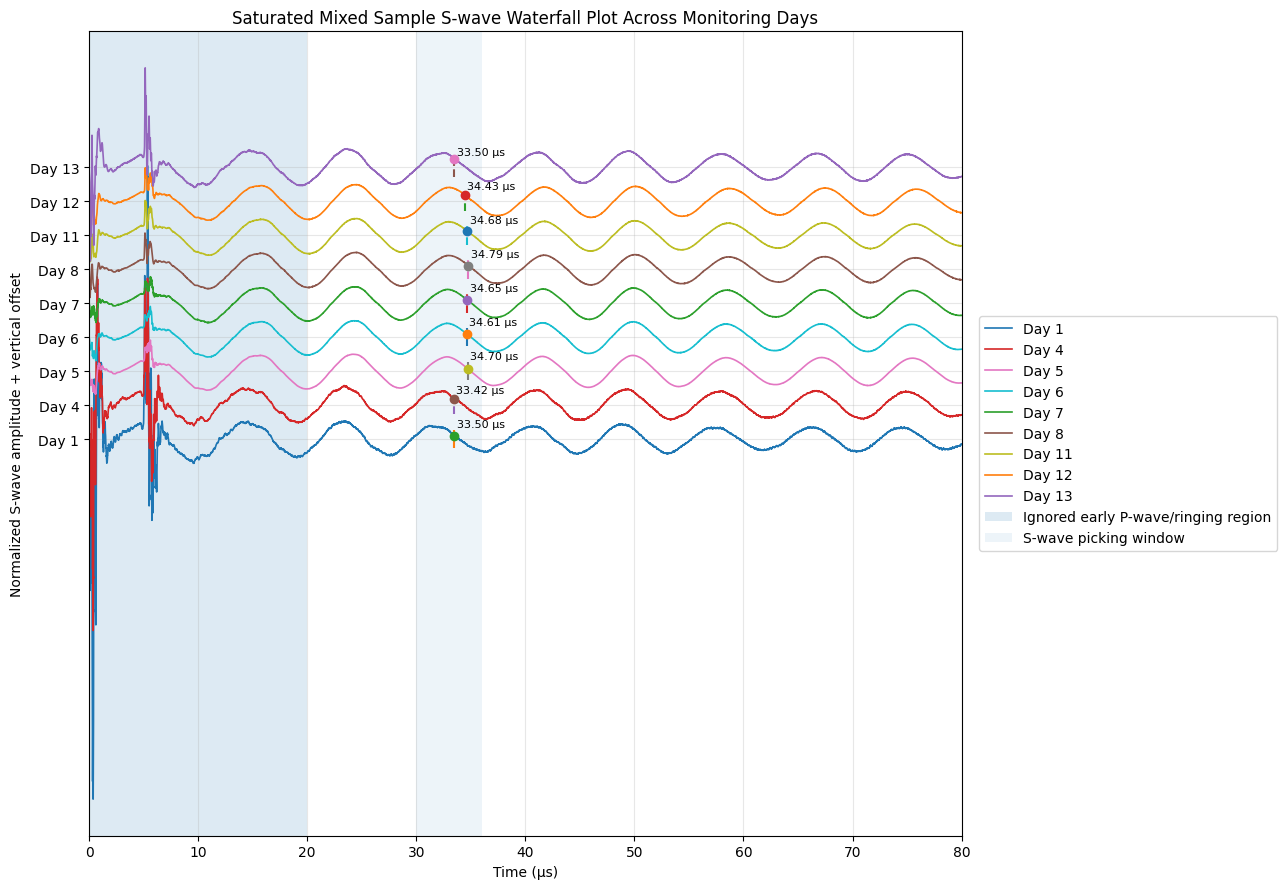


Saved:
sat_mixed_swave_waterfall_coda_normalized.png


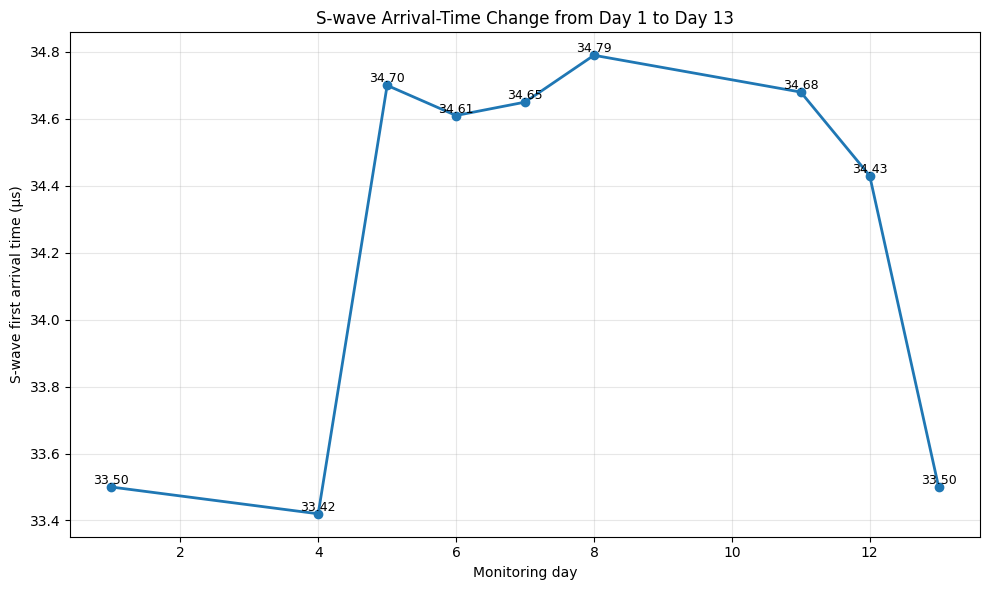


Saved:
sat_mixed_swave_arrival_time_trend.png

Day 1 vs Day 13 S-wave comparison:
Day 1 S-wave arrival time:  33.50 µs
Day 13 S-wave arrival time: 33.50 µs
Change:                     0.00 µs
Percent change:             0.00%
Interpretation: No S-wave arrival-time change detected.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. SATURATED MIXED SAMPLE S-WAVE FILES
# ============================================================

DATA_FILES = [
    {"day": 1,  "file": "SatMixedSSSample1Swave_Synthetic_PowderCore_0.1MHz_CH1_20260731_150301.csv"},
    {"day": 4,  "file": "SatMixedSSSample4Swave_Synthetic_PowderCore_0.1MHz_CH1_20260803_124014.csv"},
    {"day": 5,  "file": "SatMixedSSSample5Swave_Synthetic_PowderCore_0.1MHz_CH1_20260804_135711.csv"},
    {"day": 6,  "file": "SatMixedSSSample6Swave_Synthetic_PowderCore_0.1MHz_CH1_20260805_133058.csv"},
    {"day": 7,  "file": "SatMixedSSSample7Swave_Synthetic_PowderCore_0.1MHz_CH1_20260806_165636.csv"},
    {"day": 8,  "file": "SatMixedSSSample8Swave_Synthetic_PowderCore_0.1MHz_CH1_20260807_155119.csv"},
    {"day": 11, "file": "SatMixedSSSample11Swave_Synthetic_PowderCore_0.1MHz_CH1_20260810_170805.csv"},
    {"day": 12, "file": "SatMixedSSSample12Swave_Synthetic_PowderCore_0.1MHz_CH1_20260811_153943.csv"},
    {"day": 13, "file": "SatMixedSSSample13Swave_Synthetic_PowderCore_0.1MHz_CH1_20260812_160100.csv"}
]

# ============================================================
# 2. SETTINGS
# ============================================================

PLOT_START_US = 0.0
PLOT_END_US = 80.0

# S-wave should arrive after the P-wave.
# This avoids early electrical spike, P-wave leakage, and ringing.
S_SEARCH_START_US = 30.0
S_SEARCH_END_US = 36.0

EARLY_RINGING_END_US = 20.0

VERTICAL_SPACING = 1.5

# ============================================================
# 3. OPTIONAL MANUAL PICKS
# ============================================================

# Run once with None.
# If any automatic marker is wrong, manually enter the corrected value.
# Example: 12: 26.50

MANUAL_PICKS_US = {
    1: None,
    4: 33.42,
    5: None,
    6: None,
    7: None,
    8: None,
    11: 34.68,
    12: 34.43,
    13: 33.50
}

# ============================================================
# 4. FUNCTIONS
# ============================================================

def moving_average(x, window_points):
    window_points = int(window_points)

    if window_points < 3:
        window_points = 3

    if window_points % 2 == 0:
        window_points += 1

    kernel = np.ones(window_points) / window_points
    return np.convolve(x, kernel, mode="same")


def robust_noise_level(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    robust_std = 1.4826 * mad
    return median, robust_std


def pick_swave_arrival(time_us, voltage_corrected):
    """
    Stable S-wave picker.

    It picks the beginning of the first clear downward fall
    inside the expected S-wave window.

    This avoids jumping between different wave cycles.
    """

    dt_us = np.median(np.diff(time_us))

    # Smooth waveform slightly to reduce noise
    smooth_voltage = moving_average(
        voltage_corrected,
        0.35 / dt_us
    )

    # Search only within expected S-wave window
    search_mask = (
        (time_us >= S_SEARCH_START_US) &
        (time_us <= S_SEARCH_END_US)
    )

    search_indices = np.where(search_mask)[0]

    if len(search_indices) == 0:
        return None, None

    # Calculate waveform slope
    slope = np.gradient(smooth_voltage, dt_us)

    # Estimate background noise before the S-wave window
    reference_mask = (
        (time_us >= max(0.0, S_SEARCH_START_US - 8.0)) &
        (time_us < S_SEARCH_START_US)
    )

    if np.sum(reference_mask) < 20:
        reference_mask = time_us < 0

    if np.sum(reference_mask) < 20:
        reference_mask = np.arange(0, min(500, len(time_us)))

    reference_signal = smooth_voltage[reference_mask]

    baseline = np.median(reference_signal)
    noise_std = 1.4826 * np.median(np.abs(reference_signal - baseline))

    # Minimum amplitude needed to accept the start of a fall
    amplitude_threshold = baseline + 1.5 * noise_std

    arrival_index = None

    # Find first local high point where waveform begins to fall
    for i in search_indices[1:-1]:

        # Local peak/start of downward fall:
        # slope changes from positive to negative
        slope_changes_downward = slope[i - 1] > 0 and slope[i] <= 0

        # Make sure it is not just tiny noise
        strong_enough = smooth_voltage[i] > amplitude_threshold

        if slope_changes_downward and strong_enough:
            arrival_index = i
            break

    # Fallback: choose the first steep downward slope in the window
    if arrival_index is None:
        search_slope = slope[search_indices]
        arrival_index = search_indices[np.argmin(search_slope)]

    arrival_time_us = time_us[arrival_index]

    return arrival_index, arrival_time_us


# ============================================================
# 5. READ DATA AND PICK S-WAVE ARRIVALS
# ============================================================

records = []
summary = []

for item in DATA_FILES:

    day = item["day"]
    file = item["file"]

    df = pd.read_csv(file)
    df.columns = df.columns.str.strip()

    time_us = df["Time_seconds"].values * 1e6
    voltage = df["Voltage_volts"].values

    sample_id = str(df["Sample_ID"].iloc[0])
    frequency_mhz = df["Transducer_Frequency_MHz"].iloc[0]

    # Baseline correction
    pretrigger_mask = time_us < 0

    if np.sum(pretrigger_mask) > 20:
        baseline = np.median(voltage[pretrigger_mask])
    else:
        baseline = np.median(voltage[:500])

    voltage_corrected = voltage - baseline

    arrival_index, arrival_time_us = pick_swave_arrival(
        time_us,
        voltage_corrected
    )

    pick_type = "Automatic window pick"

    if MANUAL_PICKS_US[day] is not None:
        arrival_time_us = MANUAL_PICKS_US[day]
        arrival_index = np.argmin(np.abs(time_us - arrival_time_us))
        pick_type = "Manual pick"

    records.append({
        "day": day,
        "label": f"Day {day}",
        "file": file,
        "sample_id": sample_id,
        "frequency_mhz": frequency_mhz,
        "time_us": time_us,
        "voltage_corrected": voltage_corrected,
        "arrival_index": arrival_index,
        "arrival_time_us": arrival_time_us,
        "pick_type": pick_type
    })

    summary.append({
        "Day": day,
        "Sample_ID": sample_id,
        "Wave_Type": "S-wave",
        "Frequency_MHz": frequency_mhz,
        "First_Arrival_Time_us": arrival_time_us,
        "First_Arrival_Index": arrival_index,
        "Pick_Type": pick_type,
        "Search_Start_us": S_SEARCH_START_US,
        "Search_End_us": S_SEARCH_END_US
    })

summary_df = pd.DataFrame(summary)
summary_df = summary_df.sort_values("Day").reset_index(drop=True)

print("\nSaturated mixed sample S-wave arrival summary:")
print(summary_df)

summary_df.to_csv("sat_mixed_swave_arrival_summary.csv", index=False)

print("\nSaved:")
print("sat_mixed_swave_arrival_summary.csv")

# ============================================================
# 6. WATERFALL PLOT
# ============================================================

# ============================================================
# 6. CLEAN WATERFALL PLOT
# Less clustered, better spacing, clipped display only
# ============================================================

# ============================================================
# 6. SIMPLE WATERFALL PLOT — NO STRETCHING, NO CLIPPING
# Uses one common amplitude scale for all days
# ============================================================

# ============================================================
# 6. WATERFALL PLOT
# Normalize using the main S-wave coda window
# This makes Day 1, Day 4, and Day 13 display more like the others
# ============================================================

plt.figure(figsize=(13, 9))

# Increase spacing between days
VERTICAL_SPACING = 2.0

yticks = []
yticklabels = []

for i, rec in enumerate(records):

    time_us = rec["time_us"]
    voltage_corrected = rec["voltage_corrected"]

    # Full plotting window
    plot_mask = (
        (time_us >= PLOT_START_US) &
        (time_us <= PLOT_END_US)
    )

    # IMPORTANT:
    # Normalize using the main S-wave coda region, not the early arrival region.
    # This helps Day 1, Day 4, and Day 13 look more comparable to the other days.
    normalize_mask = (
        (time_us >= 25.0) &
        (time_us <= 60.0)
    )

    max_amp = np.max(np.abs(voltage_corrected[normalize_mask]))

    if max_amp == 0:
        voltage_norm = voltage_corrected
    else:
        voltage_norm = voltage_corrected / max_amp

    offset = i * VERTICAL_SPACING

    plt.plot(
        time_us[plot_mask],
        voltage_norm[plot_mask] + offset,
        linewidth=1.2,
        label=rec["label"]
    )

    yticks.append(offset)
    yticklabels.append(rec["label"])

    # Arrival marker
    arrival_time = rec["arrival_time_us"]
    arrival_index = rec["arrival_index"]

    if arrival_time is not None:

        plt.plot(
            [arrival_time, arrival_time],
            [offset - 0.55, offset + 0.55],
            linestyle="--",
            linewidth=1.5
        )

        plt.plot(
            arrival_time,
            voltage_norm[arrival_index] + offset,
            marker="o",
            markersize=6
        )

        plt.text(
            arrival_time + 0.25,
            offset + 0.60,
            f"{arrival_time:.2f} µs",
            ha="left",
            va="bottom",
            fontsize=8
        )

# Shade ignored early region
plt.axvspan(
    PLOT_START_US,
    EARLY_RINGING_END_US,
    alpha=0.15,
    label="Ignored early P-wave/ringing region"
)

# Shade S-wave search window
plt.axvspan(
    S_SEARCH_START_US,
    S_SEARCH_END_US,
    alpha=0.08,
    label="S-wave picking window"
)

plt.xlabel("Time (µs)")
plt.ylabel("Normalized S-wave amplitude + vertical offset")
plt.title("Saturated Mixed Sample S-wave Waterfall Plot Across Monitoring Days")
plt.xlim(PLOT_START_US, PLOT_END_US)
plt.yticks(yticks, yticklabels)
plt.grid(True, alpha=0.3)

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0
)

plt.tight_layout()

plt.savefig(
    "sat_mixed_swave_waterfall_coda_normalized.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print("sat_mixed_swave_waterfall_coda_normalized.png")
# ============================================================
# 7. S-WAVE ARRIVAL-TIME TREND
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    summary_df["Day"],
    summary_df["First_Arrival_Time_us"],
    marker="o",
    linewidth=2
)

for _, row in summary_df.iterrows():
    plt.text(
        row["Day"],
        row["First_Arrival_Time_us"],
        f"{row['First_Arrival_Time_us']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("S-wave first arrival time (µs)")
plt.title("S-wave Arrival-Time Change from Day 1 to Day 13")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_swave_arrival_time_trend.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_swave_arrival_time_trend.png")

# ============================================================
# 8. DAY 1 VS DAY 13 COMPARISON
# ============================================================

day1_time = summary_df.loc[summary_df["Day"] == 1, "First_Arrival_Time_us"].values[0]
day13_time = summary_df.loc[summary_df["Day"] == 13, "First_Arrival_Time_us"].values[0]

arrival_change = day13_time - day1_time
percent_change = (arrival_change / day1_time) * 100

print("\nDay 1 vs Day 13 S-wave comparison:")
print(f"Day 1 S-wave arrival time:  {day1_time:.2f} µs")
print(f"Day 13 S-wave arrival time: {day13_time:.2f} µs")
print(f"Change:                     {arrival_change:.2f} µs")
print(f"Percent change:             {percent_change:.2f}%")

if arrival_change > 0:
    print("Interpretation: S-wave arrived later on Day 13, suggesting lower apparent S-wave velocity.")
elif arrival_change < 0:
    print("Interpretation: S-wave arrived earlier on Day 13, suggesting higher apparent S-wave velocity.")
else:
    print("Interpretation: No S-wave arrival-time change detected.")

In [5]:
from google.colab import files

uploaded = files.upload()

Saving sat_mixed_swave_arrival_summary.csv to sat_mixed_swave_arrival_summary.csv


Original S-wave arrival summary:
   Day               Sample_ID Wave_Type  Frequency_MHz  \
0    1   SatMixedSSSampleSwave    S-wave            0.1   
1    4  SatMixedSSSample2Swave    S-wave            0.1   
2    5  SatMixedSSSample3Swave    S-wave            0.1   
3    6  SatMixedSSSample4Swave    S-wave            0.1   
4    7  SatMixedSSSample5Swave    S-wave            0.1   
5    8  SatMixedSSSample6Swave    S-wave            0.1   
6   11  SatMixedSSSample7Swave    S-wave            0.1   
7   12  SatMixedSSSample8Swave    S-wave            0.1   
8   13  SatMixedSSSample9Swave    S-wave            0.1   

   First_Arrival_Time_us  First_Arrival_Index              Pick_Type  \
0                  33.50                 3760  Automatic window pick   
1                  33.42                 3752            Manual pick   
2                  34.70                 3880  Automatic window pick   
3                  34.61                 3871  Automatic window pick   
4               

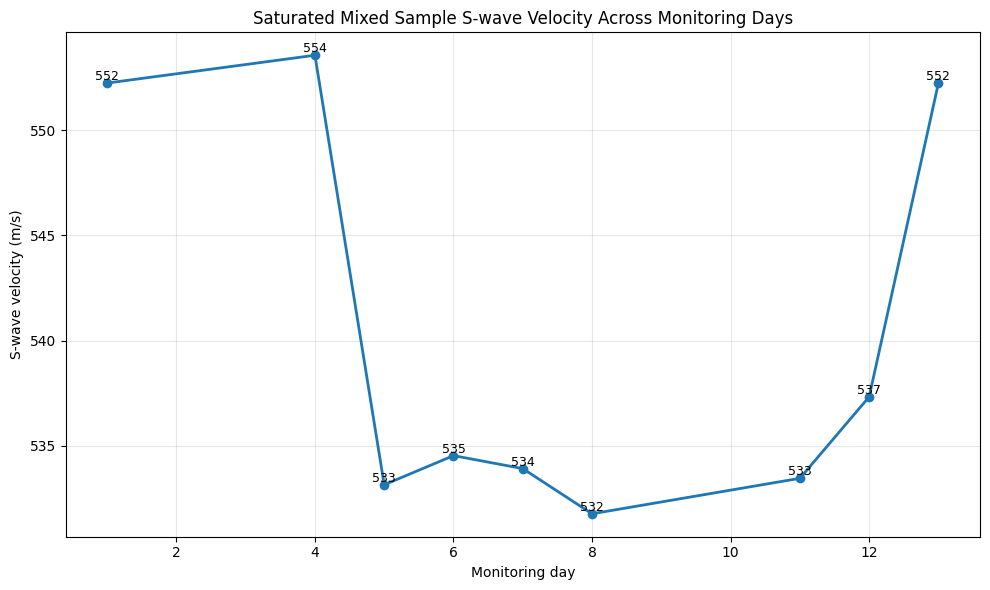


Saved:
sat_mixed_swave_velocity_line_plot.png


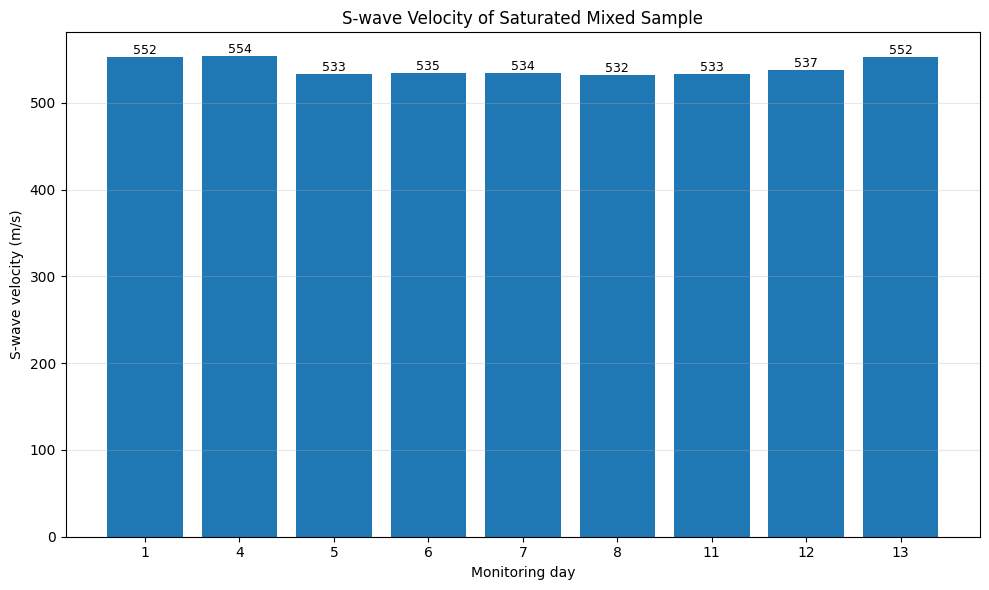


Saved:
sat_mixed_swave_velocity_bar_chart.png


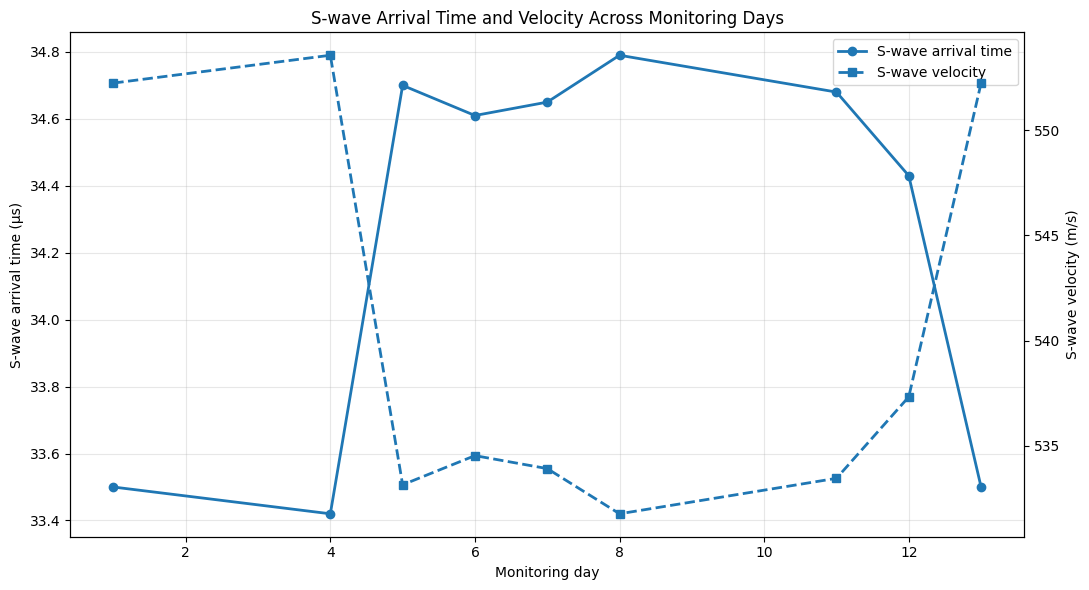


Saved:
sat_mixed_swave_arrival_time_velocity_combined.png

Day 1 vs Day 13 S-wave comparison:
Day 1 S-wave arrival time:  33.50 µs
Day 13 S-wave arrival time: 33.50 µs
Arrival-time change:        0.00 µs
Arrival-time percent change:0.00%

Day 1 S-wave velocity:      552 m/s
Day 13 S-wave velocity:     552 m/s
Velocity change:            0 m/s
Velocity percent change:    0.00%


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD SATURATED MIXED SAMPLE S-WAVE ARRIVAL SUMMARY
# ============================================================

df = pd.read_csv("sat_mixed_swave_arrival_summary.csv")
df.columns = df.columns.str.strip()

print("Original S-wave arrival summary:")
print(df)

# ============================================================
# 2. OPTIONAL MANUAL ARRIVAL-TIME CORRECTIONS
# ============================================================

# If you manually corrected any S-wave arrival time, enter it here.
# Leave as None if you want to use the value already in the CSV.
#
# Example:
# 1: 34.57
# 4: 32.46

MANUAL_PICKS_US = {
    1: None,
    4: None,
    5: None,
    6: None,
    7: None,
    8: None,
    11: None,
    12: None,
    13: None
}

# Apply manual corrections
for day, manual_time in MANUAL_PICKS_US.items():
    if manual_time is not None:
        df.loc[df["Day"] == day, "First_Arrival_Time_us"] = manual_time
        df.loc[df["Day"] == day, "Pick_Type"] = "Manual pick"

# ============================================================
# 3. CALCULATE S-WAVE VELOCITY
# ============================================================

# Sample length
sample_length_mm = 18.5
sample_length_m = sample_length_mm / 1000

df["First_Arrival_Time_s"] = df["First_Arrival_Time_us"] * 1e-6

df["S_wave_velocity_m_per_s"] = (
    sample_length_m / df["First_Arrival_Time_s"]
)

df["S_wave_velocity_km_per_s"] = (
    df["S_wave_velocity_m_per_s"] / 1000
)

df = df.sort_values("Day").reset_index(drop=True)

print("\nS-wave velocity summary:")
print(df[[
    "Day",
    "First_Arrival_Time_us",
    "S_wave_velocity_m_per_s",
    "S_wave_velocity_km_per_s",
    "Pick_Type"
]])

# Save result
df.to_csv("sat_mixed_swave_velocity_summary.csv", index=False)

print("\nSaved:")
print("sat_mixed_swave_velocity_summary.csv")

# ============================================================
# 4. LINE PLOT: S-WAVE VELOCITY ACROSS DAYS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Day"],
    df["S_wave_velocity_m_per_s"],
    marker="o",
    linewidth=2
)

for _, row in df.iterrows():
    plt.text(
        row["Day"],
        row["S_wave_velocity_m_per_s"],
        f"{row['S_wave_velocity_m_per_s']:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("S-wave velocity (m/s)")
plt.title("Saturated Mixed Sample S-wave Velocity Across Monitoring Days")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_swave_velocity_line_plot.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_swave_velocity_line_plot.png")

# ============================================================
# 5. BAR CHART: S-WAVE VELOCITY BY DAY
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    df["Day"].astype(str),
    df["S_wave_velocity_m_per_s"]
)

for _, row in df.iterrows():
    plt.text(
        str(int(row["Day"])),
        row["S_wave_velocity_m_per_s"],
        f"{row['S_wave_velocity_m_per_s']:.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xlabel("Monitoring day")
plt.ylabel("S-wave velocity (m/s)")
plt.title("S-wave Velocity of Saturated Mixed Sample")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("sat_mixed_swave_velocity_bar_chart.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_swave_velocity_bar_chart.png")

# ============================================================
# 6. COMBINED ARRIVAL TIME AND VELOCITY PLOT
# ============================================================

fig, ax1 = plt.subplots(figsize=(11, 6))

# Arrival time
ax1.plot(
    df["Day"],
    df["First_Arrival_Time_us"],
    marker="o",
    linewidth=2,
    label="S-wave arrival time"
)

ax1.set_xlabel("Monitoring day")
ax1.set_ylabel("S-wave arrival time (µs)")
ax1.grid(True, alpha=0.3)

# Velocity
ax2 = ax1.twinx()

ax2.plot(
    df["Day"],
    df["S_wave_velocity_m_per_s"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="S-wave velocity"
)

ax2.set_ylabel("S-wave velocity (m/s)")

plt.title("S-wave Arrival Time and Velocity Across Monitoring Days")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best"
)

plt.tight_layout()

plt.savefig("sat_mixed_swave_arrival_time_velocity_combined.png", dpi=300)
plt.show()

print("\nSaved:")
print("sat_mixed_swave_arrival_time_velocity_combined.png")

# ============================================================
# 7. DAY 1 VS DAY 13 COMPARISON
# ============================================================

day1 = df[df["Day"] == 1].iloc[0]
day13 = df[df["Day"] == 13].iloc[0]

arrival_change = (
    day13["First_Arrival_Time_us"]
    - day1["First_Arrival_Time_us"]
)

velocity_change = (
    day13["S_wave_velocity_m_per_s"]
    - day1["S_wave_velocity_m_per_s"]
)

arrival_percent_change = (
    arrival_change / day1["First_Arrival_Time_us"]
) * 100

velocity_percent_change = (
    velocity_change / day1["S_wave_velocity_m_per_s"]
) * 100

print("\nDay 1 vs Day 13 S-wave comparison:")
print(f"Day 1 S-wave arrival time:  {day1['First_Arrival_Time_us']:.2f} µs")
print(f"Day 13 S-wave arrival time: {day13['First_Arrival_Time_us']:.2f} µs")
print(f"Arrival-time change:        {arrival_change:.2f} µs")
print(f"Arrival-time percent change:{arrival_percent_change:.2f}%")

print(f"\nDay 1 S-wave velocity:      {day1['S_wave_velocity_m_per_s']:.0f} m/s")
print(f"Day 13 S-wave velocity:     {day13['S_wave_velocity_m_per_s']:.0f} m/s")
print(f"Velocity change:            {velocity_change:.0f} m/s")
print(f"Velocity percent change:    {velocity_percent_change:.2f}%")